In [ ]:
!pip install albumentations==1.4.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.4/150.4 kB 4.4 MB/s eta 0:00:00
  Attempting uninstall: albumentations
    Found existing installation: albumentations 2.0.8
    Uninstalling albumentations-2.0.8:
      Successfully uninstalled albumentations-2.0.8


In [ ]:
# PYTORCH LIBRARY IMPORTS

# Basic Data Handling and Visualization Libraries
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from tqdm import tqdm

# Filter warnings to keep the output clean
warnings.filterwarnings('ignore')

# PyTorch Core Libraries for Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

# Albumentations Library for Advanced Data Augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Sklearn Metrics and Model Selection Tools
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    cohen_kappa_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

# Set the Computation Device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device Used:", device)

# Global List to Store Metrics from All Models
all_model_metrics = []

# Matplotlib and Seaborn Graphics Configuration
sns.set_style('whitegrid')
sns.set_palette('dark')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully")

Device Used: cuda
All libraries imported successfully


In [ ]:
# Data upload and Google Drive connection
from google.colab import drive
drive.mount('/content/drive')

# Dataset directory paths
# Ensure these paths correctly point to your dataset location in Google Drive
train_dir = "/content/drive/MyDrive/mr_dataset_new/Training"
test_dir  = "/content/drive/MyDrive/mr_dataset_new/Testing"

print("Training Path:", train_dir)
print("Testing Path :", test_dir)

# Fixed hyperparameters and configuration settings

# Image dimensions
# Custom CNNs can work with smaller images for speed (160x160)
# Pretrained models usually expect standard ImageNet size (224x224)
IMG_SIZE_CUSTOM = (160, 160)
IMG_SIZE_PRETRAINED = (224, 224)

# Batch sizes
# Adjusted based on expected model memory usage
BATCH_SIZE_CUSTOM = 16
BATCH_SIZE_PRETRAINED = 32

# Training epochs
EPOCHS_CUSTOM = 45
EPOCHS_PRETRAINED = 30

# Random seed for reproducibility
# Crucial for obtaining consistent results across runs
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# CUDA performance settings
# deterministic=False and benchmark=True optimizes training speed
torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True

print("Fixed parameters set.")
print(f"Custom IMG Size       : {IMG_SIZE_CUSTOM}")
print(f"Pretrained IMG Size   : {IMG_SIZE_PRETRAINED}")
print(f"Custom Batch Size     :  {BATCH_SIZE_CUSTOM}")
print(f"Pretrained Batch Size :  {BATCH_SIZE_PRETRAINED}")
print(f"Custom Epochs         :  {EPOCHS_CUSTOM}")
print(f"Pretrained Epochs     :  {EPOCHS_PRETRAINED}")
print(f"Random Seed           :  {RANDOM_SEED}")

Mounted at /content/drive
Training Path: /content/drive/MyDrive/mr_dataset_new/Training
Testing Path : /content/drive/MyDrive/mr_dataset_new/Testing
Fixed parameters set.
Custom IMG Size       : (160, 160)
Pretrained IMG Size   : (224, 224)
Custom Batch Size     :  16
Pretrained Batch Size :  32
Custom Epochs         :  45
Pretrained Epochs     :  30
Random Seed           :  42


---
### **EXPLORATORY DATA ANALYSIS (EDA)**
---

EXPLORATORY DATA ANALYSIS
----------------------------------------

Sample Images


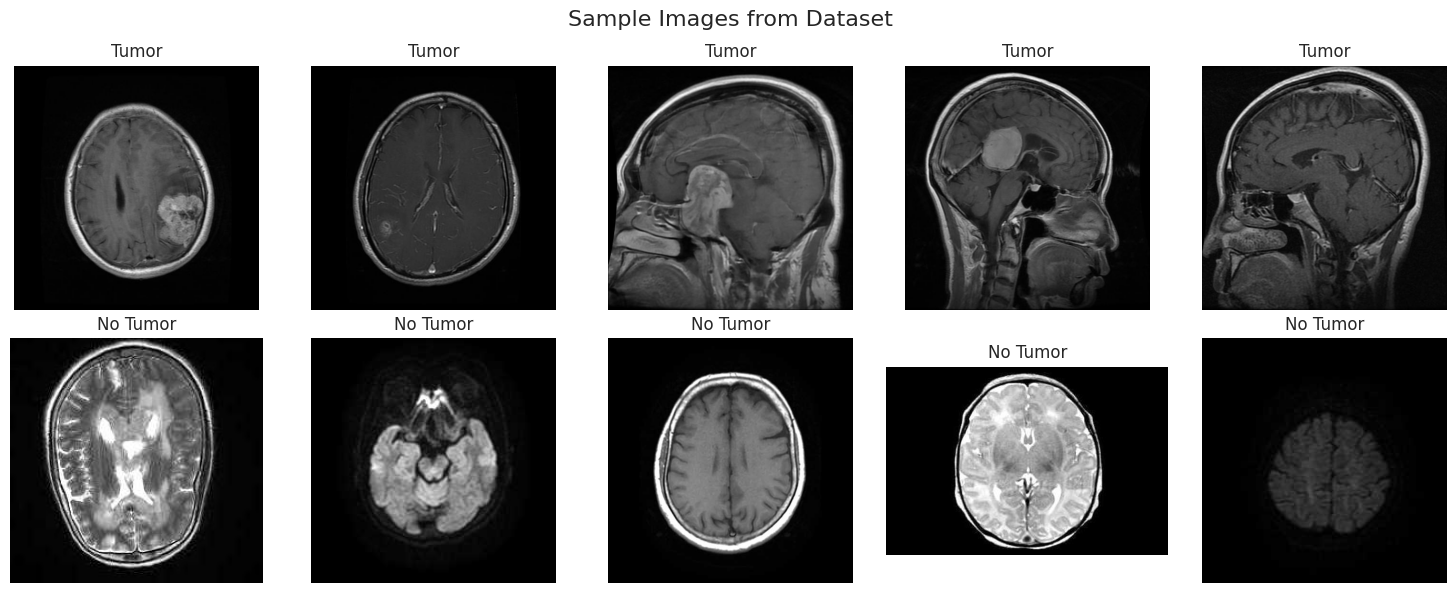


Train - Test Distribution


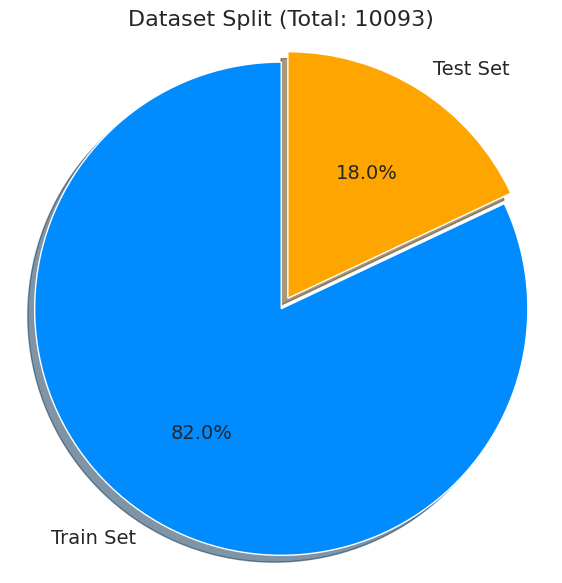

Train Images: 8277
Test Images : 1816

Class balance (Train Set)


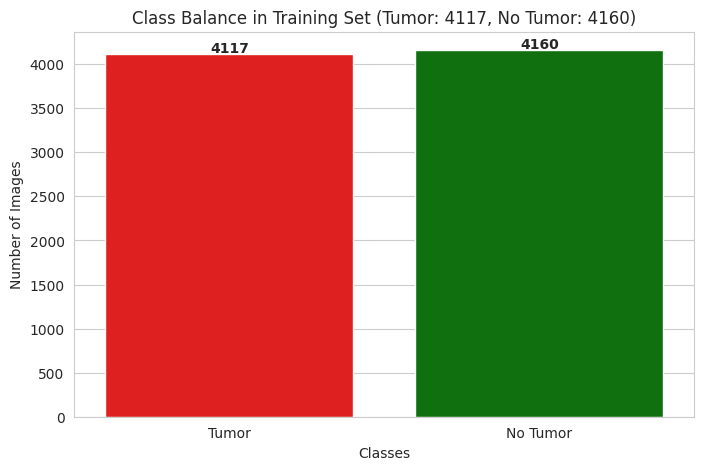


Pixel Intensities


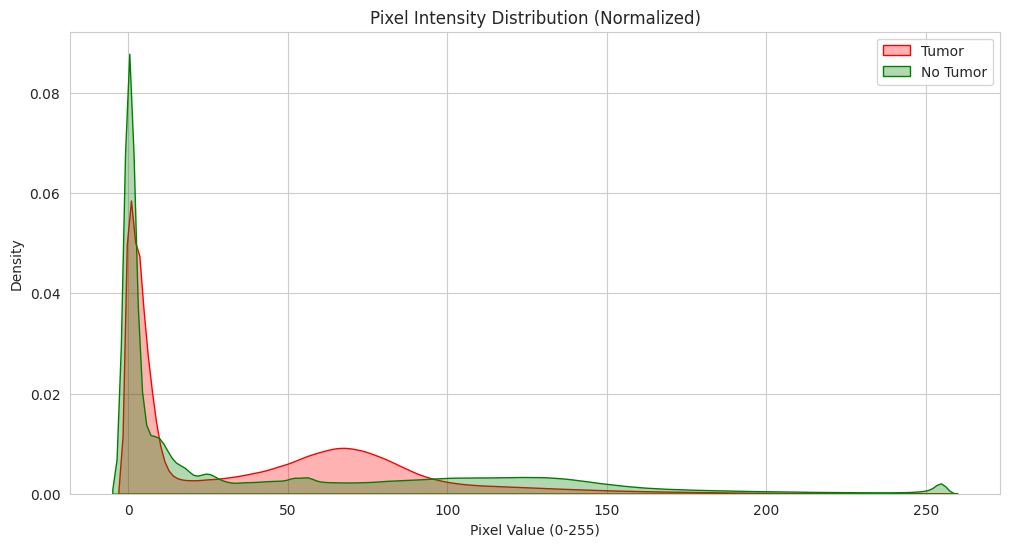


Mean Images and Difference


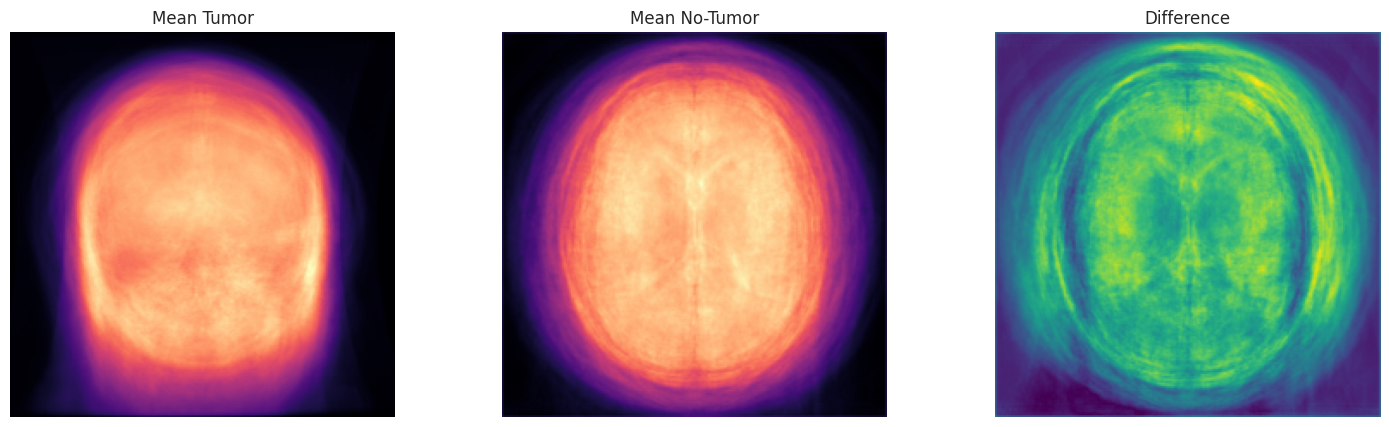


Brightness and Contrast


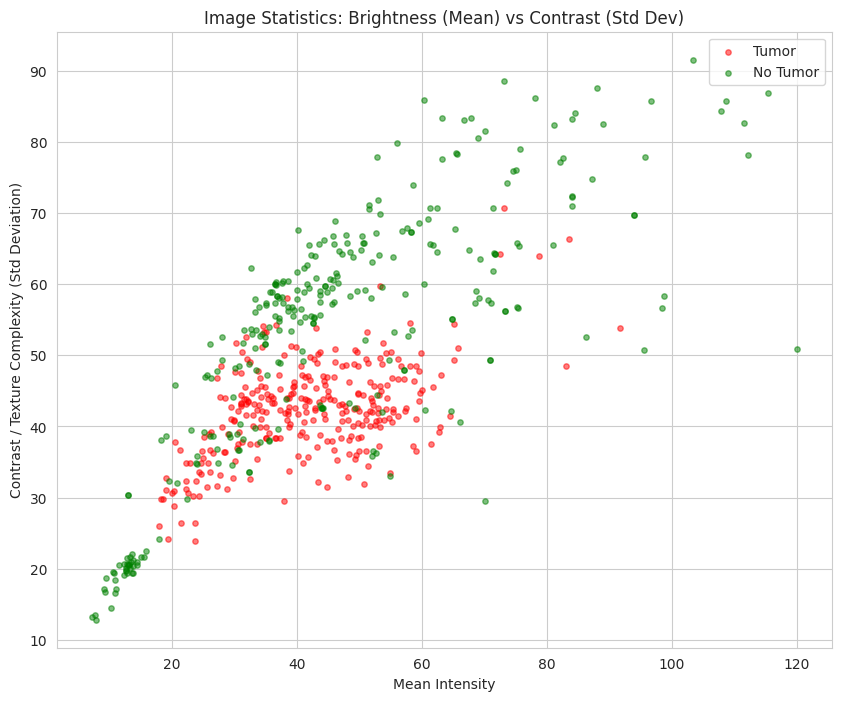


Fourier Transform Analysis (Frequency Domain)


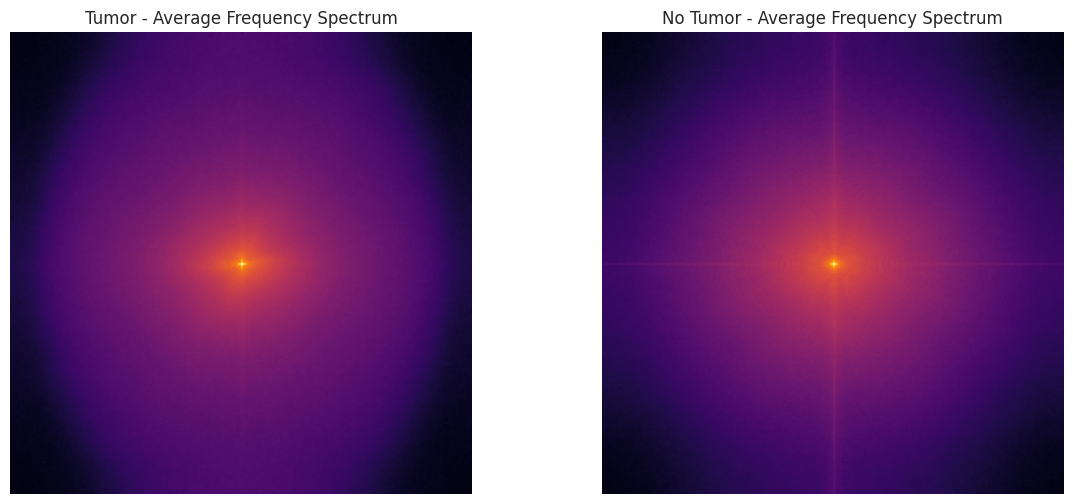


EXPLORATORY DATA ANALYSIS completed.


In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)
print("EXPLORATORY DATA ANALYSIS")
print("-" * 40)

import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from glob import glob
from scipy import fftpack

# Defining data paths
tumor_path = os.path.join(train_dir, "tumor")
notumor_path = os.path.join(train_dir, "no tumor")


# SAMPLE IMAGES
print("\nSample Images")

def show_samples(path_tumor, path_notumor, num_samples=5):
    tumor_files = glob(os.path.join(path_tumor, "*"))
    notumor_files = glob(os.path.join(path_notumor, "*"))

    # Random selection
    selected_tumor = np.random.choice(tumor_files, num_samples, replace=False)
    selected_notumor = np.random.choice(notumor_files, num_samples, replace=False)

    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))

    # Row 1: Tumor
    for i, img_path in enumerate(selected_tumor):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[0, i].imshow(img)
        axes[0, i].set_title("Tumor")
        axes[0, i].axis('off')

    # Row 2: No Tumor
    for i, img_path in enumerate(selected_notumor):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(img)
        axes[1, i].set_title("No Tumor")
        axes[1, i].axis('off')

    plt.suptitle("Sample Images from Dataset", fontsize=16)
    plt.tight_layout()
    plt.savefig("sample_images_grid.png", dpi=300)
    plt.show()

show_samples(tumor_path, notumor_path)


# TRAIN - TEST DISTRIBUTION
print("\nTrain - Test Distribution")

def count_files(directory):
    total = 0
    for root, dirs, files in os.walk(directory):
        total += len([f for f in files if f.endswith(('.jpg', '.jpeg', '.png'))])
    return total

train_total = count_files(train_dir)
test_total = count_files(test_dir)

labels = ['Train Set', 'Test Set']
sizes = [train_total, test_total]
colors = ['#008cff', '#ffA500']
explode = (0.05, 0)

plt.figure(figsize=(7, 7))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=90, textprops={'fontsize': 14})
plt.title(f"Dataset Split (Total: {train_total + test_total})", fontsize=16)
plt.axis('equal')
plt.savefig("train_test_split_pie.png", dpi=300)
plt.show()

print(f"Train Images: {train_total}")
print(f"Test Images : {test_total}")


# CLASS BALANCE
print("\nClass balance (Train Set)")
tumor_count = len(os.listdir(tumor_path))
notumor_count = len(os.listdir(notumor_path))

plt.figure(figsize=(8, 5))
sns.barplot(x=['Tumor', 'No Tumor'], y=[tumor_count, notumor_count], palette=['red', 'green'])
plt.title(f"Class Balance in Training Set (Tumor: {tumor_count}, No Tumor: {notumor_count})")
plt.ylabel("Number of Images")
plt.xlabel("Classes")
for i, v in enumerate([tumor_count, notumor_count]):
    plt.text(i, v + 20, str(v), ha='center', fontweight='bold')
plt.savefig("class_distribution.png", dpi=300)
plt.show()


# PIXEL INTENSITY
print("\nPixel Intensities")
def get_pixel_intensities(folder, limit=500):
    vals = []
    files = glob(os.path.join(folder, "*"))
    np.random.shuffle(files)

    for f in files[:limit]:
        img = cv2.imread(f, 0)
        if img is not None:
            vals.append(img.flatten())

    if vals:
        return np.concatenate(vals)
    return np.array([])

tumor_pixels = get_pixel_intensities(tumor_path)
notumor_pixels = get_pixel_intensities(notumor_path)

plt.figure(figsize=(12, 6))
sns.kdeplot(tumor_pixels, fill=True, color='red', label='Tumor', alpha=0.3)
sns.kdeplot(notumor_pixels, fill=True, color='green', label='No Tumor', alpha=0.3)
plt.title("Pixel Intensity Distribution (Normalized)")
plt.xlabel("Pixel Value (0-255)")
plt.legend()
plt.savefig("pixel_intensity_dist.png", dpi=300)
plt.show()


# MEAN IMAGE AND DIFFERENCE
print("\nMean Images and Difference")
def compute_mean_img(folder, size=(224, 224), limit=500):
    files = glob(os.path.join(folder, "*"))
    imgs = []
    for f in files[:limit]:
        img = cv2.imread(f, 0)
        if img is not None:
            img = cv2.resize(img, size)
            imgs.append(img)
    return np.mean(np.array(imgs), axis=0)

mean_tumor = compute_mean_img(tumor_path)
mean_notumor = compute_mean_img(notumor_path)
diff_img = np.abs(mean_tumor - mean_notumor)

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
ax[0].imshow(mean_tumor, cmap='magma')
ax[0].set_title("Mean Tumor")
ax[0].axis('off')

ax[1].imshow(mean_notumor, cmap='magma')
ax[1].set_title("Mean No-Tumor")
ax[1].axis('off')

ax[2].imshow(diff_img, cmap='viridis')
ax[2].set_title("Difference")
ax[2].axis('off')

plt.savefig("mean_diff_analysis.png", dpi=300)
plt.show()


# BRIGHTNESS AND CONTRAST
print("\nBrightness and Contrast")

def get_stats(folder, label, color, limit=300):
    means = []
    stds = []
    files = glob(os.path.join(folder, "*"))
    np.random.shuffle(files)

    for f in files[:limit]:
        img = cv2.imread(f, 0)
        if img is not None:
            means.append(np.mean(img))
            stds.append(np.std(img))
    return means, stds

t_mean, t_std = get_stats(tumor_path, "Tumor", "red")
n_mean, n_std = get_stats(notumor_path, "No Tumor", "green")

plt.figure(figsize=(10, 8))
plt.scatter(t_mean, t_std, c='red', alpha=0.5, label='Tumor', s=15)
plt.scatter(n_mean, n_std, c='green', alpha=0.5, label='No Tumor', s=15)
plt.title("Image Statistics: Brightness (Mean) vs Contrast (Std Dev)")
plt.xlabel("Mean Intensity")
plt.ylabel("Contrast / Texture Complexity (Std Deviation)")
plt.legend()
plt.savefig("brightness_contrast_scatter.png", dpi=300)
plt.show()


# FREQUENCY DOMAIN ANALYSIS (FOURIER TRANSFORM)
print("\nFourier Transform Analysis (Frequency Domain)")

def get_average_fft(folder, size=(224, 224), limit=200):
    files = glob(os.path.join(folder, "*"))
    fft_accum = np.zeros(size)
    count = 0

    for f in files[:limit]:
        img = cv2.imread(f, 0)
        if img is not None:
            img = cv2.resize(img, size)
            f_transform = np.fft.fft2(img)
            f_shift = np.fft.fftshift(f_transform)
            magnitude_spectrum = 20 * np.log(np.abs(f_shift) + 1)
            fft_accum += magnitude_spectrum
            count += 1

    return fft_accum / count

fft_tumor = get_average_fft(tumor_path)
fft_notumor = get_average_fft(notumor_path)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
ax[0].imshow(fft_tumor, cmap='inferno')
ax[0].set_title("Tumor - Average Frequency Spectrum")
ax[0].axis('off')

ax[1].imshow(fft_notumor, cmap='inferno')
ax[1].set_title("No Tumor - Average Frequency Spectrum")
ax[1].axis('off')

#plt.suptitle("The brighter the center, the lower frequency (Blur/Flat) the image.\nThe more spread there is to the edges, the more high frequency (Texture/Edge).", y=0.95)
plt.savefig("fft_analysis.png", dpi=300)
plt.show()

print("\nEXPLORATORY DATA ANALYSIS completed.")



---


### **DATASET CREATION AND AUGMENTATION**


---



In [ ]:
# PYTORCH DATASET & AUGMENTATION

import os
import cv2
import torch
import random
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from albumentations import (Compose, Rotate, HorizontalFlip, ShiftScaleRotate,
                            RandomGamma, GridDistortion, CoarseDropout, Normalize)
from albumentations.pytorch import ToTensorV2

print("Preparing the PyTorch dataset and augmentation structure")


# AUGMENTATION DEFINITIONS

# HEAVY AUGMENTATION FOR CUSTOM MODELS (Training Set)
# Purpose: To prevent memorization by forcing the model.
train_transform_custom = Compose([
    Rotate(limit=10, p=0.3),
    HorizontalFlip(p=0.3),
    ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
    RandomGamma(gamma_limit=(80,120), p=0.3),
    GridDistortion(num_steps=50, distort_limit=0.04, p=0.1),
    CoarseDropout(max_holes=8, max_height=16, max_width=16,
                  min_holes=1, min_height=8, min_width=8, p=0.3),
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# LIGHT AUGMENTATION FOR PRETRAINED MODELS (Training Set)
# Purpose: To add slight variety without disrupting the precise weights of pretrained models.
train_transform_pretrained = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    RandomGamma(gamma_limit=(80,120), p=0.3),
    ToTensorV2()
])

# CLEAN TRANSFORM FOR VALIDATION AND TESTING
# Purpose: To ensure that the results do not change randomly during validation (normalized only).
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])


# DATASET CLASS

class MRIDataset(Dataset):
    def __init__(self, root_dir=None, file_paths=None, labels=None, transform=None, preprocess_size=(224,224)):
        self.transform = transform
        self.preprocess_size = preprocess_size

        # If a split data list is received (Typical for Training/Validation Split)
        if file_paths is not None and labels is not None:
            self.image_paths = file_paths
            self.labels = labels

        # If the folder path is entered (Typical for Test Set or General Scanning)
        elif root_dir is not None:
            self.image_paths = []
            self.labels = []
            # Labels: 'no tumor' - 0, 'tumor' - 1
            for class_name, label in [('no tumor', 0), ('tumor', 1)]:
                folder = os.path.join(root_dir, class_name)
                if os.path.exists(folder):
                    files = [os.path.join(folder, f) for f in os.listdir(folder)
                             if f.endswith(('.jpg','.jpeg','.png'))]
                    self.image_paths.extend(files)
                    self.labels.extend([label] * len(files))
        else:
            # Safety fallback
            print("Neither file_paths nor root_dir was provided")
            self.image_paths = []
            self.labels = []

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        label = self.labels[idx]

        # IMAGE READING (CRITICAL FIX: RGB MODE)
        # We read as standard BGR then convert to RGB.
        # NOT Grayscale, because Pretrained models require 3 channels.
        img = cv2.imread(path)

        # ERROR MANAGEMENT
        # If a corrupted file arrives, a black screen (zeros) will be returned.
        if img is None:
            img = np.zeros((self.preprocess_size[0], self.preprocess_size[1], 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # SIZING
        if self.preprocess_size:
            img = cv2.resize(img, self.preprocess_size)

        # AUGMENTATION
        if self.transform:
            augmented = self.transform(image=img)
            img = augmented["image"]

        # RETURN (Image and Float Label for Loss Function)
        return img, torch.tensor(label, dtype=torch.float32)


# DATA PREPARATION AND SPLIT (TRAIN / VALIDATION SPLIT)
print("The training data is scanned and split (Train/Val Split)")

all_train_paths = []
all_train_labels = []

# Collect all files in the Training folder
for class_name, label in [('no tumor', 0), ('tumor', 1)]:
    folder = os.path.join(train_dir, class_name)
    if os.path.exists(folder):
        files = [os.path.join(folder, f) for f in os.listdir(folder)
                 if f.endswith(('.jpg','.jpeg','.png'))]
        all_train_paths.extend(files)
        all_train_labels.extend([label] * len(files))

# Split the data into 80% Train and 20% Validation
train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_train_paths, all_train_labels,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=all_train_labels
)

print(f"Total Education Visual: {len(all_train_paths)}")
print(f"Train Set: {len(train_paths)}")
print(f"Val Set  : {len(val_paths)}")


# CREATING A DATASET

# CUSTOM MODELS (160x160)
train_dataset_custom = MRIDataset(file_paths=train_paths, labels=train_labels,
                                  transform=train_transform_custom, # HEAVY Aug
                                  preprocess_size=IMG_SIZE_CUSTOM)

val_dataset_custom = MRIDataset(file_paths=val_paths, labels=val_labels,
                                transform=val_transform_clean,      # No Aug
                                preprocess_size=IMG_SIZE_CUSTOM)

test_dataset_custom = MRIDataset(root_dir=test_dir,
                                 transform=val_transform_clean,     # No Aug
                                 preprocess_size=IMG_SIZE_CUSTOM)

# PRETRAINED MODELS (224x224)
train_dataset_pretrained = MRIDataset(file_paths=train_paths, labels=train_labels,
                                      transform=train_transform_pretrained, # LIGHT Aug
                                      preprocess_size=IMG_SIZE_PRETRAINED)

val_dataset_pretrained = MRIDataset(file_paths=val_paths, labels=val_labels,
                                    transform=val_transform_clean,          # No Aug
                                    preprocess_size=IMG_SIZE_PRETRAINED)

test_dataset_pretrained = MRIDataset(root_dir=test_dir,
                                     transform=val_transform_clean,         # No Aug
                                     preprocess_size=IMG_SIZE_PRETRAINED)


# DATALOADER STRUCTURES
train_loader_custom = DataLoader(train_dataset_custom, batch_size=BATCH_SIZE_CUSTOM, shuffle=True, num_workers=2)
val_loader_custom   = DataLoader(val_dataset_custom,   batch_size=BATCH_SIZE_CUSTOM, shuffle=False, num_workers=2)
test_loader_custom  = DataLoader(test_dataset_custom,  batch_size=BATCH_SIZE_CUSTOM, shuffle=False, num_workers=2)

train_loader_pretrained = DataLoader(train_dataset_pretrained, batch_size=BATCH_SIZE_PRETRAINED, shuffle=True, num_workers=2)
val_loader_pretrained   = DataLoader(val_dataset_pretrained,   batch_size=BATCH_SIZE_PRETRAINED, shuffle=False, num_workers=2)
test_loader_pretrained  = DataLoader(test_dataset_pretrained,  batch_size=BATCH_SIZE_PRETRAINED, shuffle=False, num_workers=2)

print("\nPyTorch data pipeline created successfully.")
print(f"Custom Model (Train/Val/Test)     : {len(train_dataset_custom)} / {len(val_dataset_custom)} / {len(test_dataset_custom)}")
print(f"Pretrained Model (Train/Val/Test) : {len(train_dataset_pretrained)} / {len(val_dataset_pretrained)} / {len(test_dataset_pretrained)}")

Preparing the PyTorch dataset and augmentation structure
The training data is scanned and split (Train/Val Split)
Total Education Visual: 8277
Train Set: 6621
Val Set  : 1656

PyTorch data pipeline created successfully.
Custom Model (Train/Val/Test)     : 6621 / 1656 / 1816
Pretrained Model (Train/Val/Test) : 6621 / 1656 / 1816




---


### **CALLBACK DEFINITIONS**


---



In [ ]:
# CALLBACK DEFINITIONS

import torch
import os
import numpy as np
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Folder to save models
DRIVE_SAVE_PATH = "/content/drive/MyDrive/saved_models_new/"
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
print(f"Model registration path verified: {DRIVE_SAVE_PATH}")

# EARLY STOPPING
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def step(self, val_loss):
        if val_loss < (self.best_loss - self.min_delta):
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop


# MODEL CHECKPOINT
class ModelCheckpoint:
    def __init__(self, save_path, verbose=True):
        self.save_path = save_path
        self.verbose = verbose
        self.best_loss = np.inf

    def step(self, val_loss, model):
        if val_loss < self.best_loss:
            if self.verbose:
                print(f"Validation Loss improved ({self.best_loss:.4f} to {val_loss:.4f}). Saving Full Model")
            self.best_loss = val_loss


            try:
                # Convert model to TorchScript format. with JIT
                model_scripted = torch.jit.script(model)
                # Save
                model_scripted.save(self.save_path)
            except Exception as e:
                print(f"TorchScript registration failed: {e}")
                print("Saving standard state_dict as backup")
                torch.save(model.state_dict(), self.save_path.replace('.pt', '.pth'))


# CALLBACK PACKER
def get_callbacks(model_name, optimizer):
    # We make the extension .pt
    save_file = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )

    return {
        "early_stopping": EarlyStopping(patience=6, min_delta=0.0001),
        "scheduler": scheduler,
        "checkpoint": ModelCheckpoint(save_file)
    }

print("Callback structures have been updated.")

Model registration path verified: /content/drive/MyDrive/saved_models_new/
Callback structures have been updated.


### **METRIC CALCULATION**

In [ ]:
# PYTORCH METRIC CALCULATION AND DRAWING TABLES

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc, cohen_kappa_score,
    precision_score, recall_score, f1_score
)
import torch

sns.set_style("whitegrid")

# Tensor to Numpy Converter
def to_numpy(data):
    if isinstance(data, torch.Tensor):
        return data.detach().cpu().numpy()
    elif isinstance(data, list):
        return np.array(data)
    else:
        return np.array(data)

# METRIC CALCULATION FUNCTION
def calculate_metrics(y_true, y_pred_prob, model_name):
    # y_true: True labels (0 or 1)
    # y_pred_prob: Probability values predicted by the model (0.0 - 1.0)

    y_true = to_numpy(y_true).astype(int)
    y_pred_prob = to_numpy(y_pred_prob)

    # Threshold 0.5
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, 0, 0

    # Metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-7)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    kappa = cohen_kappa_score(y_true, y_pred)

    # ROC curve
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sensitivity)': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'Kappa': kappa,
        'AUC': roc_auc
    }

    return metrics, cm, (fpr, tpr, roc_auc)

# PANEL DETAILED GRAPHIC DRAWING
def plot_model_results(history, metrics, cm, roc_data, model_name, classes=["No Tumor", "Tumor"]):
    # history: dict -> {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    fig = plt.figure(figsize=(18, 10))

    # ACCURACY (Train: Blue, Val: Orange)
    ax1 = plt.subplot(2, 3, 1)
    ax1.plot(history["train_acc"], label="Train Acc", linewidth=2, color='#1f77b4') # Blue
    ax1.plot(history["val_acc"], label="Validation Acc", linewidth=2, color='#ff7f0e', linestyle='--') # Orange
    ax1.set_title(f"{model_name} - Accuracy", fontsize=12, weight='bold')
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend(loc='lower right')
    ax1.grid(True, alpha=0.3)

    # LOSS (Train: Blue, Val: Orange)
    ax2 = plt.subplot(2, 3, 2)
    ax2.plot(history["train_loss"], label="Train Loss", linewidth=2, color='#1f77b4') # Blue
    ax2.plot(history["val_loss"], label="Validation Loss", linewidth=2, color='#ff7f0e', linestyle='--') # Orange
    ax2.set_title(f"{model_name} - Loss", fontsize=12, weight='bold')
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)

    # CONFUSION MATRIX
    ax3 = plt.subplot(2, 3, 3)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes,
                yticklabels=classes,
                annot_kws={"size": 14, "weight": "bold"},
                cbar=False, ax=ax3)
    ax3.set_title(f"{model_name} - Confusion Matrix", fontsize=12, weight='bold')
    ax3.set_xlabel("Predicted Label")
    ax3.set_ylabel("True Label")

    # ROC CURVE (Purple)
    fpr, tpr, roc_auc = roc_data
    ax4 = plt.subplot(2, 3, 4)
    ax4.plot(fpr, tpr, linewidth=2, color='#9b59b6', label=f"AUC = {roc_auc:.3f}")
    ax4.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax4.set_title(f"{model_name} - ROC Curve", fontsize=12, weight='bold')
    ax4.set_xlabel("False Positive Rate")
    ax4.set_ylabel("True Positive Rate")
    ax4.legend(loc="lower right")
    ax4.grid(True, alpha=0.3)

    # BAR CHART (METRICS)
    ax5 = plt.subplot(2, 3, 5)
    keys = ["Accuracy", "Precision", "Recall (Sensitivity)", "F1-Score"]
    values = [metrics.get(k, 0) for k in keys]
    colors = ['#3498db', '#1abc9c', '#e67e22', '#f1c40f']

    bars = ax5.bar(keys, values, color=colors, alpha=0.8, edgecolor='black')
    ax5.set_ylim([0, 1.15])
    ax5.set_title(f"{model_name} - Key Metrics", fontsize=12, weight='bold')
    ax5.grid(axis='y', alpha=0.3)
    plt.xticks(rotation=15)

    for bar in bars:
        height = bar.get_height()
        ax5.text(bar.get_x() + bar.get_width() / 2, height + 0.02, f"{height:.3f}",
                 ha="center", va="bottom", fontsize=10, fontweight='bold')

    # NUMERICAL RESULTS TABLE
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis("off")
    table_data = [
        ["Accuracy", f"{metrics.get('Accuracy', 0):.4f}"],
        ["Precision", f"{metrics.get('Precision', 0):.4f}"],
        ["Recall (Sens.)", f"{metrics.get('Recall (Sensitivity)', 0):.4f}"],
        ["Specificity", f"{metrics.get('Specificity', 0):.4f}"],
        ["F1 Score", f"{metrics.get('F1-Score', 0):.4f}"],
        ["Kappa Score", f"{metrics.get('Kappa', 0):.4f}"],
        ["AUC Score", f"{metrics.get('AUC', 0):.4f}"],
    ]

    colors = [["#f2f2f2", "#ffffff"] for _ in range(len(table_data))]
    table = ax6.table(cellText=table_data, colLabels=["Metric", "Value"], cellColours=colors, loc="center", cellLoc='center')
    table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1, 2)
    ax6.set_title(f"{model_name} - Numerical Results", fontsize=12, weight='bold')

    plt.tight_layout()
    safe_name = model_name.replace(" ", "_").lower()
    plt.savefig(f"{safe_name}_results_dashboard.png", dpi=300, bbox_inches="tight")
    plt.show()

print("Metric calculation and visualization functions are ready.")

Metric calculation and visualization functions are ready.




---


### **VGG16 NO AUGMENTATION TEST**


---



In [ ]:
# VGG16 NO AUGMENTATION TEST - TRAIN
# !!! RUN CALLBACKS CELL FIRST !!!

import time
import os
import torch
import torch.nn as nn
from torchvision import models
from torch.optim import Adam
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
import numpy as np

model_name = "VGG16_NoAug"
save_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

print(f"TEST STARTED: {model_name} (Baseline - No Augmentation)")
print(f"Target Save Path: {save_path}")
print("-" * 40)

# PREPARE DATA (NO AUGMENTATION)
# Using 'val_transform_clean' for Training ensures NO Augmentation. Just normalized.
print("Preparing Non-Augmented Data Loaders")

full_dataset_clean = MRIDataset(
    root_dir=train_dir,
    transform=val_transform_clean, # CLEAN TRANSFORM (No Rotation/Shift)
    preprocess_size=(224, 224)
)

# Split Indices
train_idx, val_idx = train_test_split(
    np.arange(len(full_dataset_clean)),
    test_size=0.2,
    random_state=42,
    stratify=full_dataset_clean.labels
)

# Create Subsets & Loaders
ds_train_no_aug = Subset(full_dataset_clean, train_idx)
ds_val_clean    = Subset(full_dataset_clean, val_idx)

train_loader_no_aug = DataLoader(ds_train_no_aug, batch_size=32, shuffle=True, num_workers=2)
val_loader_clean    = DataLoader(ds_val_clean, batch_size=32, shuffle=False, num_workers=2)

print(f"Train Size: {len(ds_train_no_aug)} | Val Size: {len(ds_val_clean)}")

# INITIALIZE VGG16
model = models.vgg16(weights='DEFAULT')

# Freeze Features
for param in model.features.parameters():
    param.requires_grad = False

# Modify Classifier
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 1)

model = model.to(device)

# TRAINING SETUP (With Early Stopping)
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

# Config
num_epochs = 30
patience = 10        # How many epochs to wait before stopping if no improvement
counter = 0          # Counter for patience
best_val_loss = float('inf')

history_vgg_no_aug = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time = time.time()
print("\nTraining Loop Started with Early Stopping")

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    running_loss = 0; correct = 0; total = 0

    for images, labels in train_loader_no_aug:
        images, labels = images.to(device), labels.float().to(device)
        optimizer.zero_grad()

        logits = model(images).squeeze()
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0; val_correct = 0; val_total = 0
    with torch.no_grad():
        for images, labels in val_loader_clean:
            images, labels = images.to(device), labels.float().to(device)

            logits = model(images).squeeze()
            loss = criterion(logits, labels)

            val_loss += loss.item() * images.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Log History
    history_vgg_no_aug["train_loss"].append(train_loss)
    history_vgg_no_aug["val_loss"].append(val_loss)
    history_vgg_no_aug["train_acc"].append(train_acc)
    history_vgg_no_aug["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # EARLY STOPPING & SAVING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0  # Reset patience counter

        # SAVE IMMEDIATELY
        try:
            model_scripted = torch.jit.script(model)
            torch.jit.save(model_scripted, save_path)
            print(f"  Best Model Saved - Validation Loss: {val_loss:.4f}")
        except Exception as e:
            print(f"  Save Failed (JIT Error): {e}")
            # Fallback to state_dict if JIT fails
            torch.save(model.state_dict(), save_path.replace(".pt", ".pth"))
            print(" Saved as state_dict (.pth) instead.")

    else:
        counter += 1
        print(f"  No improvement, patience: {counter}/{patience}")
        if counter >= patience:
            print(f"\n  EARLY STOPPING at Epoch {epoch+1}")
            break

end_time = time.time()
print("-" * 40)
print(f"Experiment Completed. Total Time: {end_time - start_time:.2f}s")

# Check if file exists
if os.path.exists(save_path):
    print(f"Model file exists at {save_path}")
else:
    print(f"Model file MISSING, Check Drive permissions.")

TEST STARTED: VGG16_NoAug (Baseline - No Augmentation)
Target Save Path: /content/drive/MyDrive/saved_models_new/best_model_VGG16_NoAug.pt
----------------------------------------
Preparing Non-Augmented Data Loaders
Train Size: 6621 | Val Size: 1656
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 201MB/s]



Training Loop Started with Early Stopping
Epoch 1/30 | Train Acc: 0.9592 | Val Loss: 0.0520 | Val Acc: 0.9843
  Best Model Saved - Validation Loss: 0.0520
Epoch 2/30 | Train Acc: 0.9887 | Val Loss: 0.0470 | Val Acc: 0.9885
  Best Model Saved - Validation Loss: 0.0470
Epoch 3/30 | Train Acc: 0.9935 | Val Loss: 0.0334 | Val Acc: 0.9921
  Best Model Saved - Validation Loss: 0.0334
Epoch 4/30 | Train Acc: 0.9989 | Val Loss: 0.1009 | Val Acc: 0.9837
  No improvement, patience: 1/10
Epoch 5/30 | Train Acc: 0.9938 | Val Loss: 0.1947 | Val Acc: 0.9517
  No improvement, patience: 2/10
Epoch 6/30 | Train Acc: 0.9923 | Val Loss: 0.0702 | Val Acc: 0.9909
  No improvement, patience: 3/10
Epoch 7/30 | Train Acc: 0.9973 | Val Loss: 0.0689 | Val Acc: 0.9897
  No improvement, patience: 4/10
Epoch 8/30 | Train Acc: 0.9964 | Val Loss: 0.1006 | Val Acc: 0.9903
  No improvement, patience: 5/10
Epoch 9/30 | Train Acc: 0.9989 | Val Loss: 0.0792 | Val Acc: 0.9934
  No improvement, patience: 6/10
Epoch 10/30 

VGG16 NO AUGMENTATION TEST EVALUATION: VGG16_NoAug
----------------------------------------
JIT Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_VGG16_NoAug.pt
Scanning Test Folder: /content/drive/MyDrive/mr_dataset_new/Testing
Test Images Found: 1816
Running inference on test set

----------------------------------
BASELINE RESULTS (NO AUGMENTATION)
----------------------------------
Accuracy : 0.9912
F1 Score : 0.9912
AUC      : 0.9985
ROC data saved: VGG16_NoAug
Results saved to CSV: VGG16_NoAug


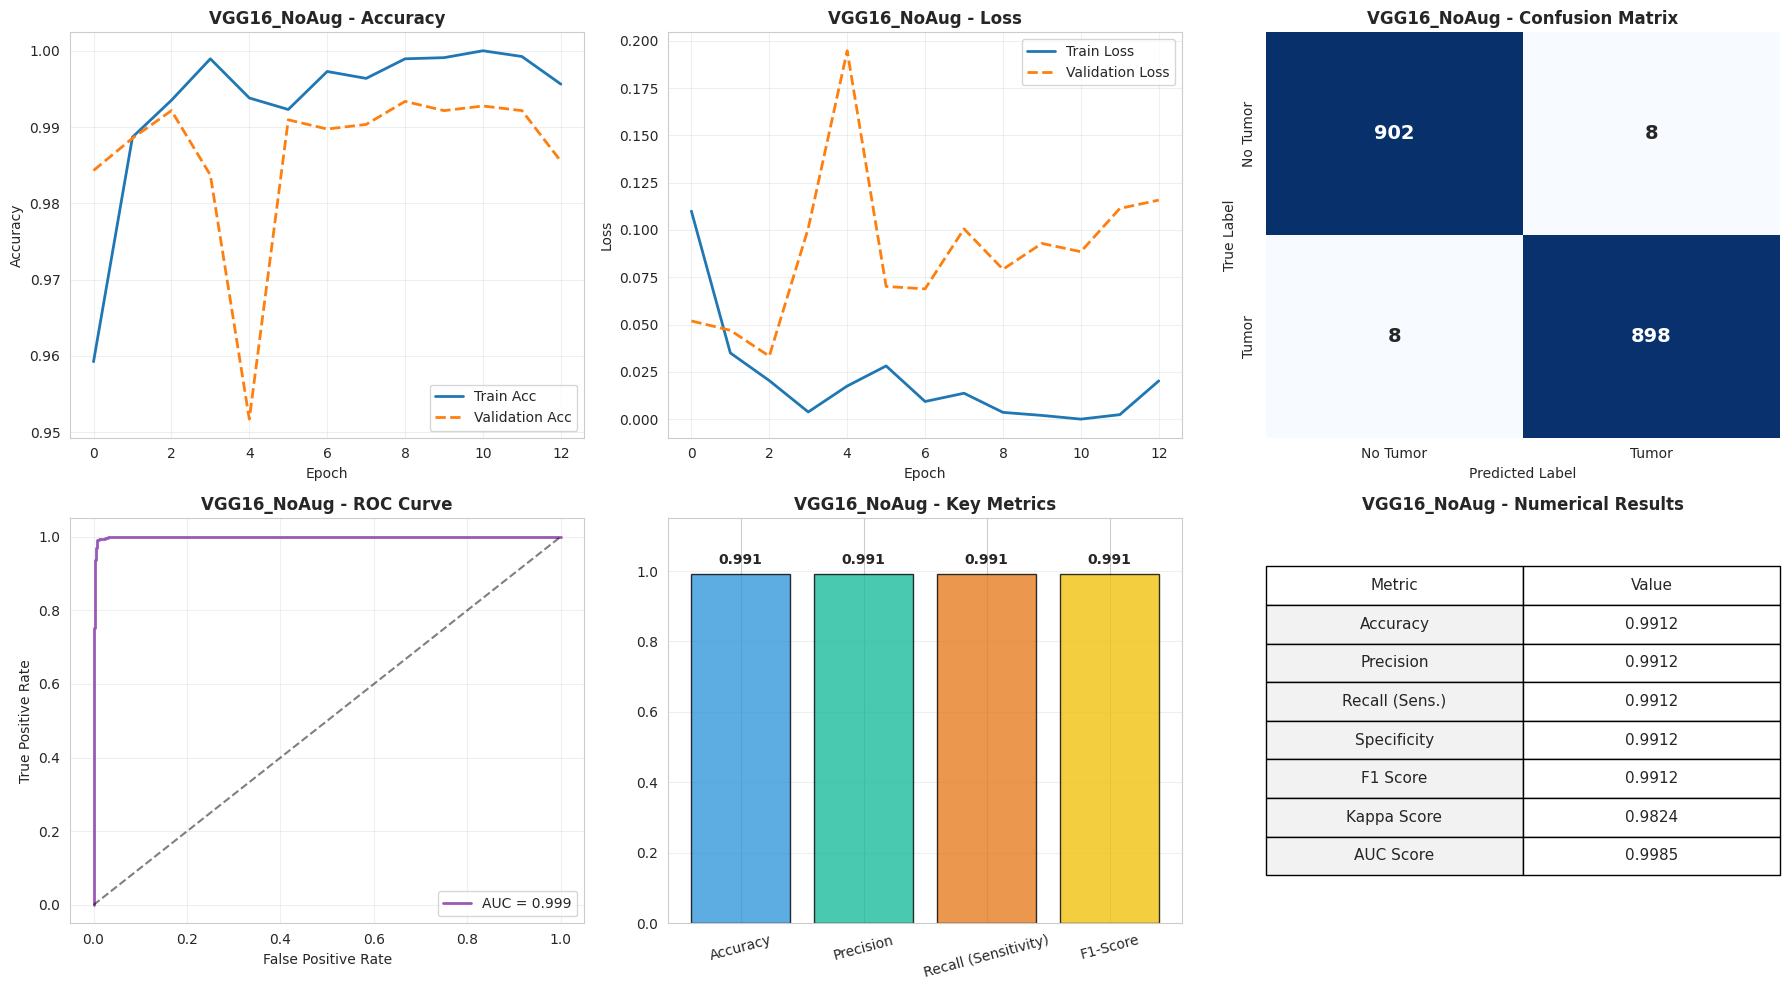

In [ ]:
# VGG16 NO AUGMENTATION TEST - EVALUATION

import pickle
import pandas as pd
import os
import torch
import numpy as np
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader
from torchvision import models
import torch.nn as nn

# Model Name
model_name = "VGG16_NoAug"
file_name = f"best_model_{model_name}.pt"

print(f"VGG16 NO AUGMENTATION TEST EVALUATION: {model_name}")
print("-" * 40)

# LOAD MODEL
model_path = os.path.join(DRIVE_SAVE_PATH, file_name)

if os.path.exists(model_path):
    try:
        # Try loading as JIT
        model = torch.jit.load(model_path, map_location=device)
        print(f"JIT Model loaded successfully: {model_path}")
    except:
        # Fallback to State Dict if JIT failed during training save
        print("Loading via state_dict (JIT load failed)")
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, 1)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)

    model.eval()
else:
    raise FileNotFoundError(f"Model file not found: {model_path}.")

# PREPARE TEST DATA
# Using Clean Transform (Normalize Only) - Standard for Testing
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

print(f"Scanning Test Folder: {test_dir}")
test_dataset_no_aug = MRIDataset(
    root_dir=test_dir,
    transform=val_transform_clean,
    preprocess_size=(224, 224)
)

if len(test_dataset_no_aug) == 0:
    raise ValueError(f"ERROR: No files found at '{test_dir}'!")

test_loader_no_aug = DataLoader(test_dataset_no_aug, batch_size=32, shuffle=False, num_workers=2)
print(f"Test Images Found: {len(test_dataset_no_aug)}")

# RUN INFERENCE
y_true_list = []
y_prob_list = []

print("Running inference on test set")
with torch.no_grad():
    for images, labels in test_loader_no_aug:
        images = images.to(device)

        # Forward pass
        logits = model(images).squeeze()

        # Sigmoid
        probs = torch.sigmoid(logits)

        y_prob_list.extend(probs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# CALCULATE METRICS
metrics_no_aug, cm_no_aug, roc_data_no_aug = calculate_metrics(y_true_list, y_prob_list, model_name)

# Print Summary
print("\n" + "-"*34)
print("BASELINE RESULTS (NO AUGMENTATION)")
print("-"*34)
print(f"Accuracy : {metrics_no_aug.get('Accuracy', 0):.4f}")
print(f"F1 Score : {metrics_no_aug.get('F1-Score', 0):.4f}")
print(f"AUC      : {metrics_no_aug.get('AUC', 0):.4f}")

# SAVE ROC DATA
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f: saved_roc_curves = pickle.load(f)
else: saved_roc_curves = {}

saved_roc_curves[model_name] = roc_data_no_aug
with open(roc_pkl_path, 'wb') as f: pickle.dump(saved_roc_curves, f)
print(f"ROC data saved: {model_name}")

# UPDATE COMPARISON CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_no_aug])

if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    # Remove duplicates if any
    existing_df = existing_df[existing_df['Model'] != model_name]
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
else:
    final_df = new_row_df

final_df.to_csv(csv_path, index=False)
print(f"Results saved to CSV: {model_name}")

# VISUALIZE RESULTS
if 'history_vgg_no_aug' in globals():
    plot_model_results(history_vgg_no_aug, metrics_no_aug, cm_no_aug, roc_data_no_aug, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history found for visualization (Variable 'history_vgg_no_aug' is missing).")



---


### **MODELS**


---




---


### **MODEL 1: VGG16**


---


In [ ]:
# VGG16 TRAINING WITH AUGMENTATION

import time
import os
import torch
import torch.nn as nn
from torchvision import models
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

model_name = "VGG16_WithAug"
save_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

print(f"TRAINING STARTED: {model_name}")
print(f"Target Device: {device}")
print("-" * 35)

# SETUP MODEL
model = models.vgg16(weights='DEFAULT')

for param in model.features.parameters():
    param.requires_grad = False

num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 1)

model = model.to(device)

# OPTIMIZER & SCHEDULER
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# TRAINING CONFIG
num_epochs = 30
patience = 8
counter = 0
best_val_loss = float('inf')

history_vgg_aug = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time = time.time()
total_epochs_run = 0

print("Training Loop Initiated")

for epoch in range(num_epochs):
    # TRAIN
    model.train()
    r_loss=0; correct=0; total=0
    for imgs, lbls in train_loader_pretrained:
        imgs, lbls = imgs.to(device), lbls.float().to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze()
        loss = criterion(logits, lbls)
        loss.backward()
        optimizer.step()
        r_loss += loss.item() * imgs.size(0)
        correct += ((torch.sigmoid(logits)>0.5) == lbls).sum().item()
        total += lbls.size(0)

    # VALIDATION
    model.eval()
    v_loss=0; v_correct=0; v_total=0
    with torch.no_grad():
        for imgs, lbls in val_loader_pretrained:
            imgs, lbls = imgs.to(device), lbls.float().to(device)
            logits = model(imgs).squeeze()
            v_loss += criterion(logits, lbls).item() * imgs.size(0)
            v_correct += ((torch.sigmoid(logits)>0.5) == lbls).sum().item()
            v_total += lbls.size(0)

    t_loss, t_acc = r_loss/total, correct/total
    val_loss, val_acc = v_loss/v_total, v_correct/v_total

    # Log
    history_vgg_aug["train_loss"].append(t_loss)
    history_vgg_aug["val_loss"].append(val_loss)
    history_vgg_aug["train_acc"].append(t_acc)
    history_vgg_aug["val_acc"].append(val_acc)

    # LR & Print
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.1e} | Train Acc: {t_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    scheduler.step(val_loss)
    total_epochs_run = epoch + 1

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), save_path.replace(".pt", ".pth"))
        try: torch.jit.save(torch.jit.script(model), save_path)
        except: pass
        print(f"Best Model Saved -  Validation Loss: {val_loss:.4f}")
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly Stopping at Epoch {epoch+1}")
            break

end_time = time.time()
total_duration = end_time - start_time
avg_epoch_time_vgg16 = total_duration / total_epochs_run

print("-" * 40)
print(f"Training Completed.")
print(f"Total Time: {total_duration:.2f}s")
print(f"Total Epochs: {total_epochs_run}")
print(f"Avg Time per Epoch: {avg_epoch_time_vgg16:.2f}sec")

TRAINING STARTED: VGG16_WithAug
Target Device: cuda
-----------------------------------
Training Loop Initiated
Epoch 1/30 | LR: 1.0e-04 | Train Acc: 0.9616 | Val Loss: 0.0463 | Val Acc: 0.9861
Best Model Saved -  Validation Loss: 0.0463
Epoch 2/30 | LR: 1.0e-04 | Train Acc: 0.9881 | Val Loss: 0.0864 | Val Acc: 0.9704
Epoch 3/30 | LR: 1.0e-04 | Train Acc: 0.9937 | Val Loss: 0.0437 | Val Acc: 0.9934
Best Model Saved -  Validation Loss: 0.0437
Epoch 4/30 | LR: 1.0e-04 | Train Acc: 0.9946 | Val Loss: 0.0469 | Val Acc: 0.9915
Epoch 5/30 | LR: 1.0e-04 | Train Acc: 0.9965 | Val Loss: 0.0569 | Val Acc: 0.9928
Epoch 6/30 | LR: 1.0e-04 | Train Acc: 0.9964 | Val Loss: 0.0686 | Val Acc: 0.9915
Epoch 7/30 | LR: 1.0e-05 | Train Acc: 0.9992 | Val Loss: 0.0627 | Val Acc: 0.9921
Epoch 8/30 | LR: 1.0e-05 | Train Acc: 1.0000 | Val Loss: 0.0627 | Val Acc: 0.9921
Epoch 9/30 | LR: 1.0e-05 | Train Acc: 0.9992 | Val Loss: 0.0654 | Val Acc: 0.9921
Epoch 10/30 | LR: 1.0e-06 | Train Acc: 1.0000 | Val Loss: 0.06

Avg Epoch Time found in memory: 72.74s
MODEL EVALUATION: VGG16_WithAug
----------------------------------------

RESULTS: VGG16_WithAug
Acc: 0.9906 | F1: 0.9906 | Time: 72.7s


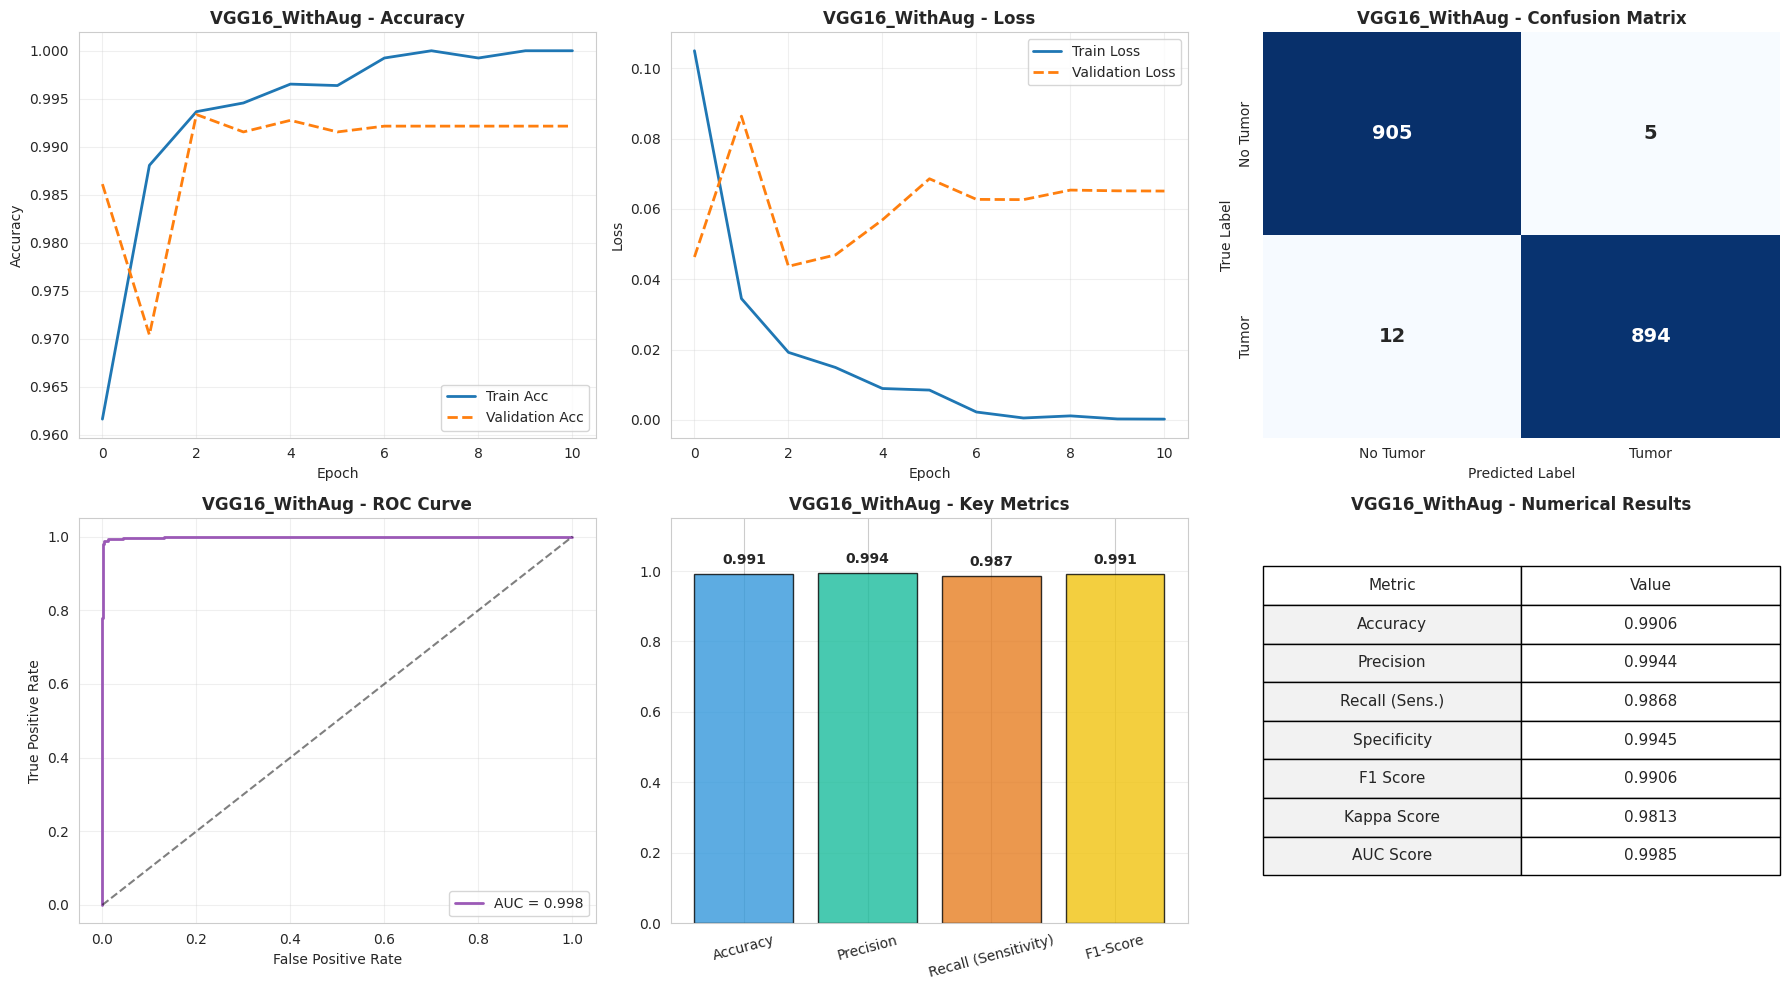

In [ ]:
# EVALUATION: VGG16 WITH AUGMENTATION

import pickle
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import models

model_name = "VGG16_WithAug"
file_name = f"best_model_{model_name}.pt"
load_path = os.path.join(DRIVE_SAVE_PATH, file_name)


if 'avg_epoch_time_vgg16' in globals():
    avg_time = avg_epoch_time_vgg16
    print(f"Avg Epoch Time found in memory: {avg_time:.2f}s")
else:
    avg_time = 0.0
    print("Avg Epoch Time not found in memory. Setting to 0.0")

print(f"MODEL EVALUATION: {model_name}")
print("-" * 40)

# LOAD MODEL
if os.path.exists(load_path):
    try:
        model = torch.jit.load(load_path, map_location=device)
    except:
        model = models.vgg16(weights=None)
        model.classifier[6] = nn.Linear(4096, 1)
        model.load_state_dict(torch.load(load_path.replace(".pt", ".pth"), map_location=device))
    model.to(device).eval()
else:
    raise FileNotFoundError(f"Model file not found: {load_path}")

# PREDICT
y_true, y_prob = [], []
with torch.no_grad():
    for imgs, lbls in test_loader_pretrained:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze()
        y_prob.extend(torch.sigmoid(logits).cpu().tolist())
        y_true.extend(lbls.tolist())

# METRICS
metrics_eval, cm_eval, roc_data_eval = calculate_metrics(y_true, y_prob, model_name)
metrics_eval["Avg. Epoch Time (s)"] = avg_time

# SAVE
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row = pd.DataFrame([metrics_eval])
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    df = df[df['Model'] != model_name]
    final_df = pd.concat([df, new_row], ignore_index=True)
else:
    final_df = new_row
final_df.to_csv(csv_path, index=False)

# VISUALIZE
print("\n" + "="*30)
print(f"RESULTS: {model_name}")
print(f"Acc: {metrics_eval['Accuracy']:.4f} | F1: {metrics_eval['F1-Score']:.4f} | Time: {avg_time:.1f}s")

if 'history_vgg_aug' in globals():
    plot_model_results(history_vgg_aug, metrics_eval, cm_eval, roc_data_eval, model_name, classes=["No Tumor", "Tumor"])
else:
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Confusion Matrix: {model_name}")
    plt.show()



---


### **MODEL 2: DenseNet121**


---


In [ ]:
# TRAINING: DENSENET121

import time
import os
import torch
import torch.nn as nn
from torchvision import models
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# CONFIGURATION
model_name = "DenseNet121"
save_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

print(f"TRAINING STARTED: {model_name}")
print(f"Target Device: {device}")
print("-" * 35)

# SETUP MODEL
# Load Pretrained DenseNet121
model = models.densenet121(weights='DEFAULT')

# Freeze Feature Layers (Standard Transfer Learning)
for param in model.features.parameters():
    param.requires_grad = False

# Modify Classifier Head
num_features = model.classifier.in_features
model.classifier = nn.Sequential(
    nn.Linear(num_features, 1)
)

model = model.to(device)

# OPTIMIZER, LOSS & SCHEDULER
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=1e-4)

# Scheduler: Reduce LR if validation loss stops improving
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# TRAINING LOOP CONFIG
num_epochs = 30
patience = 8        # Early Stopping patience
counter = 0         # Early Stopping counter
best_val_loss = float('inf')

history_densenet = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# TIME TRACKING START
start_time = time.time()
total_epochs_run = 0

print("Training Loop Initiated")

for epoch in range(num_epochs):
    # TRAIN PHASE
    model.train()
    r_loss=0; correct=0; total=0

    # Using 'train_loader_pretrained' which includes Augmentation
    for imgs, lbls in train_loader_pretrained:
        imgs, lbls = imgs.to(device), lbls.float().to(device)
        optimizer.zero_grad()

        logits = model(imgs).squeeze()
        loss = criterion(logits, lbls)
        loss.backward()
        optimizer.step()

        r_loss += loss.item() * imgs.size(0)
        # Calculate Acc
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    t_loss = r_loss / total
    t_acc = correct / total

    # VALIDATION PHASE
    model.eval()
    v_loss=0; v_correct=0; v_total=0
    with torch.no_grad():
        # Using 'val_loader_pretrained'
        for imgs, lbls in val_loader_pretrained:
            imgs, lbls = imgs.to(device), lbls.float().to(device)

            logits = model(imgs).squeeze()
            loss = criterion(logits, lbls)

            v_loss += loss.item() * imgs.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            v_correct += (preds == lbls).sum().item()
            v_total += lbls.size(0)

    val_loss = v_loss / v_total
    val_acc = v_correct / v_total

    # Log History
    history_densenet["train_loss"].append(t_loss)
    history_densenet["val_loss"].append(val_loss)
    history_densenet["train_acc"].append(t_acc)
    history_densenet["val_acc"].append(val_acc)

    # Get Current LR
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.1e} | Train Acc: {t_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Scheduler Step
    scheduler.step(val_loss)
    total_epochs_run = epoch + 1

    # EARLY STOPPING & SAVING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save State Dict (Safest)
        torch.save(model.state_dict(), save_path.replace(".pt", ".pth"))

        try:
            torch.jit.save(torch.jit.script(model), save_path)
            print("Best Model Saved With JIT ")
        except:
            pass

        print(f"Best Model Saved - Validation Loss: {val_loss:.4f}")
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly Stopping at Epoch {epoch+1}")
            break

# TIME CALCULATION
end_time = time.time()
total_duration = end_time - start_time
avg_epoch_time_densenet = total_duration / total_epochs_run

print("-" * 50)
print(f"Training Completed.")
print(f"Total Time: {total_duration:.2f}s")
print(f"Total Epochs: {total_epochs_run}")
print(f"Avg Time per Epoch: {avg_epoch_time_densenet:.2f}sec")

TRAINING STARTED: DenseNet121
Target Device: cuda
-----------------------------------
Training Loop Initiated
Epoch 1/30 | LR: 1.0e-04 | Train Acc: 0.7404 | Val Loss: 0.4499 | Val Acc: 0.8907
Best Model Saved With JIT 
Best Model Saved - Validation Loss: 0.4499
Epoch 2/30 | LR: 1.0e-04 | Train Acc: 0.9107 | Val Loss: 0.3244 | Val Acc: 0.9257
Best Model Saved With JIT 
Best Model Saved - Validation Loss: 0.3244
Epoch 3/30 | LR: 1.0e-04 | Train Acc: 0.9310 | Val Loss: 0.2578 | Val Acc: 0.9529
Best Model Saved With JIT 
Best Model Saved - Validation Loss: 0.2578
Epoch 4/30 | LR: 1.0e-04 | Train Acc: 0.9437 | Val Loss: 0.2180 | Val Acc: 0.9571
Best Model Saved With JIT 
Best Model Saved - Validation Loss: 0.2180
Epoch 5/30 | LR: 1.0e-04 | Train Acc: 0.9515 | Val Loss: 0.1905 | Val Acc: 0.9607
Best Model Saved With JIT 
Best Model Saved - Validation Loss: 0.1905
Epoch 6/30 | LR: 1.0e-04 | Train Acc: 0.9579 | Val Loss: 0.1704 | Val Acc: 0.9680
Best Model Saved With JIT 
Best Model Saved - Va

Avg Epoch Time found: 63.71s
MODEL EVALUATION: DenseNet121
------------------------------
JIT Model loaded.
Running Inference on Test Set

------------------------------
RESULTS: DenseNet121
------------------------------
Accuracy : 0.9510
F1 Score : 0.9497
AUC      : 0.9909
Results saved to CSV and Drive.

Generating Plots (Loss, Acc, CM, ROC)...


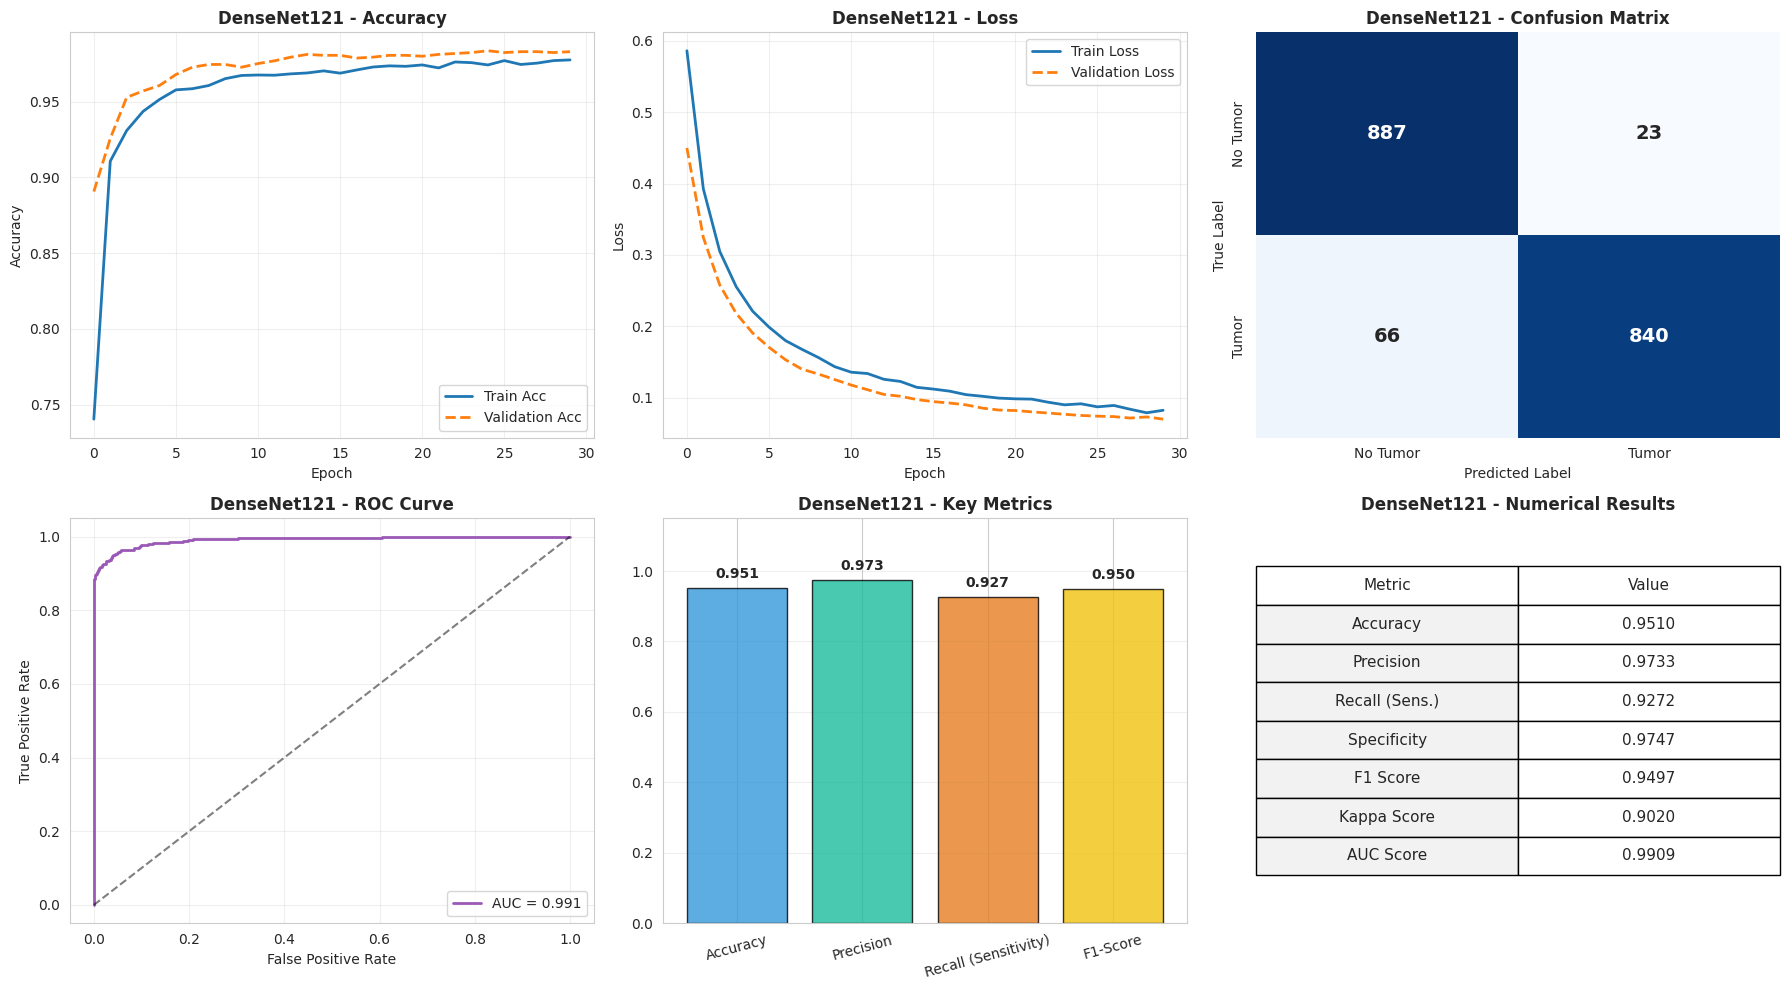

In [ ]:
# EVALUATION: DENSENET121

import pickle
import pandas as pd
import os
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import seaborn as sns

# SETTINGS
model_name = "DenseNet121"
file_name = f"best_model_{model_name}.pt"
load_path = os.path.join(DRIVE_SAVE_PATH, file_name)

# Auto-fetch Avg Time
if 'avg_epoch_time_densenet' in globals():
    avg_time = avg_epoch_time_densenet
    print(f"Avg Epoch Time found: {avg_time:.2f}s")
else:
    avg_time = 0.0
    print("Avg Epoch Time not found. Setting to 0.0")

print(f"MODEL EVALUATION: {model_name}")
print("-" * 30)

# LOAD MODEL
if os.path.exists(load_path):
    try:
        # Try JIT
        model = torch.jit.load(load_path, map_location=device)
        print(f"JIT Model loaded.")
    except:
        # Fallback to State Dict
        print(f"JIT failed, loading State Dict...")
        model = models.densenet121(weights=None)
        # Reconstruct Classifier
        num_features = model.classifier.in_features
        model.classifier = nn.Sequential(nn.Linear(num_features, 1))

        model.load_state_dict(torch.load(load_path.replace(".pt", ".pth"), map_location=device))
        print(f"State Dict loaded.")
    model.to(device)
    model.eval()
else:
    raise FileNotFoundError(f"Model file not found: {load_path}")

# TEST DATA LOADER
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# Re-create loader to ensure independence
test_dataset_eval = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_eval = DataLoader(test_dataset_eval, batch_size=32, shuffle=False, num_workers=2)

# RUN PREDICTIONS
y_true_list = []
y_prob_list = []

print("Running Inference on Test Set")
with torch.no_grad():
    for images, labels in test_loader_eval:
        images = images.to(device)

        logits = model(images).squeeze()
        probs = torch.sigmoid(logits)

        y_prob_list.extend(probs.cpu().tolist())
        y_true_list.extend(labels.tolist())

# CALCULATE METRICS
metrics_eval, cm_eval, roc_data_eval = calculate_metrics(y_true_list, y_prob_list, model_name)
metrics_eval["Avg. Epoch Time (s)"] = avg_time

print("\n" + "-"*30)
print(f"RESULTS: {model_name}")
print("-"*30)
print(f"Accuracy : {metrics_eval['Accuracy']:.4f}")
print(f"F1 Score : {metrics_eval['F1-Score']:.4f}")
print(f"AUC      : {metrics_eval['AUC']:.4f}")

# SAVE RESULTS (ROC & CSV)
# ROC
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f: saved_roc_curves = pickle.load(f)
else: saved_roc_curves = {}
saved_roc_curves[model_name] = roc_data_eval
with open(roc_pkl_path, 'wb') as f: pickle.dump(saved_roc_curves, f)

# CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_eval])
if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    existing_df = existing_df[existing_df['Model'] != model_name]
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
else:
    final_df = new_row_df
final_df.to_csv(csv_path, index=False)
print(f"Results saved to CSV and Drive.")

# VISUALIZE RESULTS
if 'history_densenet' in globals():
    print("\nGenerating Plots (Loss, Acc, CM, ROC)...")
    plot_model_results(history_densenet, metrics_eval, cm_eval, roc_data_eval, model_name, classes=["No Tumor", "Tumor"])
else:
    print("\nHistory not found. Plotting only CM and ROC.")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # CM
    sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f"Confusion Matrix: {model_name}")

    # ROC
    fpr, tpr, roc_auc = roc_data_eval
    ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].legend()
    plt.show()



---


### **MODEL 3: ResNet50**


---


In [ ]:
train_loader_pretrained = DataLoader(
    train_dataset_pretrained,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True,
    persistent_workers=False
)

val_loader_pretrained = DataLoader(
    val_dataset_pretrained,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [ ]:
# TRAINING: RESNET50

import time
import os
import torch
import torch.nn as nn
from torchvision import models
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# CONFIGURATION
model_name = "ResNet50"
save_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

print(f"TRAINING STARTED: {model_name}")
print(f"Target Device: {device}")
print("-" * 30)

# SETUP MODEL
model = models.resnet50(weights='DEFAULT')

# Freeze Feature Layers
for param in model.parameters():
    param.requires_grad = False

# Modify Classifier Head
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Linear(num_features, 1)
)

# Unfreeze the last FC layer
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

# OPTIMIZER, LOSS & SCHEDULER
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.fc.parameters(), lr=1e-4)

# Scheduler: Reduce LR if validation loss stops improving
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2)

# TRAINING LOOP CONFIG
num_epochs = 30
patience = 8        # Early Stopping patience
counter = 0         # Early Stopping counter
best_val_loss = float('inf')

history_resnet = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# TIME TRACKING START
start_time = time.time()
total_epochs_run = 0

print("Training Loop Initiated")

for epoch in range(num_epochs):
    # TRAIN PHASE
    model.train()
    r_loss=0; correct=0; total=0

    # Using 'train_loader_pretrained'
    for imgs, lbls in train_loader_pretrained:
        imgs, lbls = imgs.to(device), lbls.float().to(device)
        optimizer.zero_grad()

        logits = model(imgs).squeeze()
        loss = criterion(logits, lbls)
        loss.backward()
        optimizer.step()

        r_loss += loss.item() * imgs.size(0)
        # Calculate Acc
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == lbls).sum().item()
        total += lbls.size(0)

    t_loss = r_loss / total
    t_acc = correct / total

    # VALIDATION PHASE
    model.eval()
    v_loss=0; v_correct=0; v_total=0
    with torch.no_grad():
        # Using 'val_loader_pretrained'
        for imgs, lbls in val_loader_pretrained:
            imgs, lbls = imgs.to(device), lbls.float().to(device)

            logits = model(imgs).squeeze()
            loss = criterion(logits, lbls)

            v_loss += loss.item() * imgs.size(0)
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            v_correct += (preds == lbls).sum().item()
            v_total += lbls.size(0)

    val_loss = v_loss / v_total
    val_acc = v_correct / v_total

    # Log History
    history_resnet["train_loss"].append(t_loss)
    history_resnet["val_loss"].append(val_loss)
    history_resnet["train_acc"].append(t_acc)
    history_resnet["val_acc"].append(val_acc)

    # Get Current LR
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1}/{num_epochs} | LR: {current_lr:.1e} | Train Acc: {t_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # Scheduler Step
    scheduler.step(val_loss)
    total_epochs_run = epoch + 1

    # EARLY STOPPING & SAVING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save State Dict
        torch.save(model.state_dict(), save_path.replace(".pt", ".pth"))

        # Try Saving JIT
        try:
            torch.jit.save(torch.jit.script(model), save_path)
        except:
            pass

        print(f"Best Model Saved - Validation Loss: {val_loss:.4f}")
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly Stopping at Epoch {epoch+1}")
            break

# TIME CALCULATION
end_time = time.time()
total_duration = end_time - start_time
avg_epoch_time_resnet = total_duration / total_epochs_run

print("-" * 30)
print(f"Training Completed.")
print(f"Total Time: {total_duration:.2f}s")
print(f"Total Epochs: {total_epochs_run}")
print(f"Avg Time per Epoch: {avg_epoch_time_resnet:.2f}sec")

TRAINING STARTED: ResNet50
Target Device: cuda
------------------------------
Training Loop Initiated
Epoch 1/30 | LR: 1.0e-04 | Train Acc: 0.8425 | Val Loss: 0.4796 | Val Acc: 0.9263
Best Model Saved - Validation Loss: 0.4796
Epoch 2/30 | LR: 1.0e-04 | Train Acc: 0.9195 | Val Loss: 0.3704 | Val Acc: 0.9378
Best Model Saved - Validation Loss: 0.3704
Epoch 3/30 | LR: 1.0e-04 | Train Acc: 0.9361 | Val Loss: 0.2991 | Val Acc: 0.9444
Best Model Saved - Validation Loss: 0.2991
Epoch 4/30 | LR: 1.0e-04 | Train Acc: 0.9414 | Val Loss: 0.2648 | Val Acc: 0.9565
Best Model Saved - Validation Loss: 0.2648
Epoch 5/30 | LR: 1.0e-04 | Train Acc: 0.9471 | Val Loss: 0.2372 | Val Acc: 0.9565
Best Model Saved - Validation Loss: 0.2372
Epoch 6/30 | LR: 1.0e-04 | Train Acc: 0.9542 | Val Loss: 0.2082 | Val Acc: 0.9601
Best Model Saved - Validation Loss: 0.2082
Epoch 7/30 | LR: 1.0e-04 | Train Acc: 0.9536 | Val Loss: 0.1933 | Val Acc: 0.9644
Best Model Saved - Validation Loss: 0.1933
Epoch 8/30 | LR: 1.0e-0

Avg Epoch Time found: 80.71s
MODEL EVALUATION: ResNet50
------------------------------
Model loaded.
Running Inference on Test Set

------------------------------
RESULTS: ResNet50
------------------------------
Accuracy : 0.9427
F1 Score : 0.9416
AUC      : 0.9837
Results saved to CSV and Drive

Generating Plots (Loss, Acc, CM, ROC)


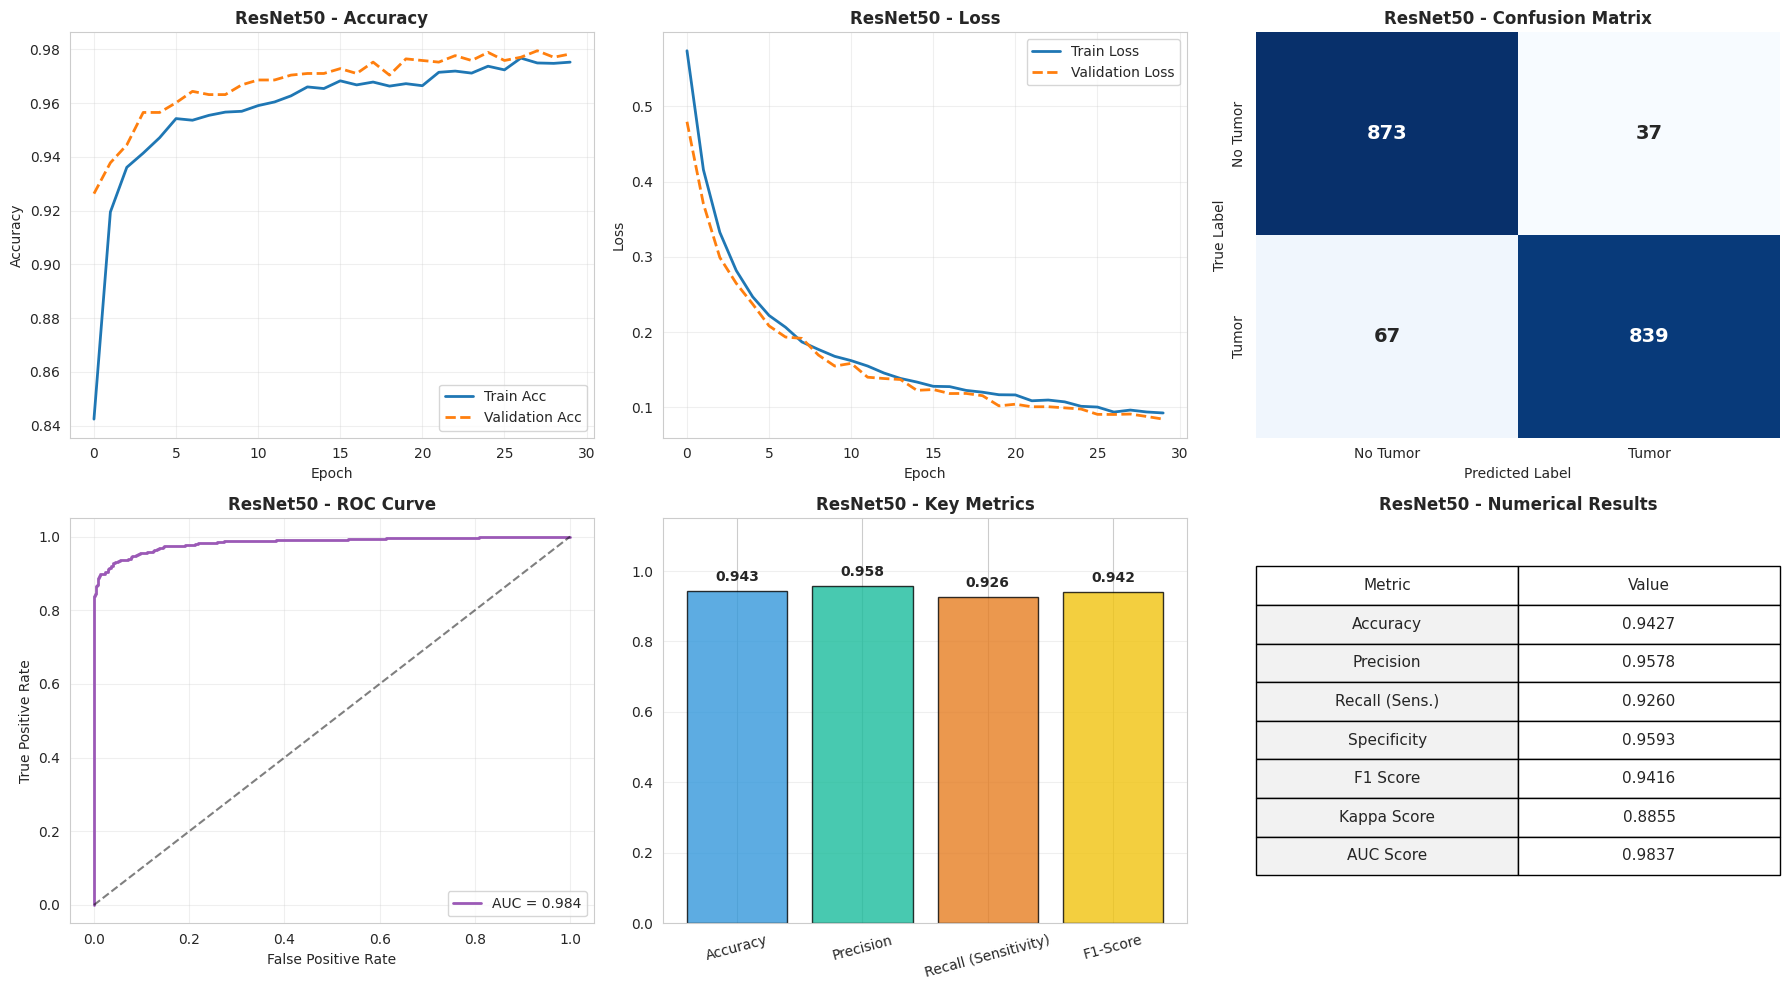

In [ ]:
# EVALUATION: RESNET50

import pickle
import pandas as pd
import os
import torch
import torch.nn as nn
from torchvision import models
from torch.utils.data import DataLoader
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import seaborn as sns

# SETTINGS
model_name = "ResNet50"
file_name = f"best_model_{model_name}.pt"
load_path = os.path.join(DRIVE_SAVE_PATH, file_name)

# Auto-fetch Avg Time
if 'avg_epoch_time_resnet' in globals():
    avg_time = avg_epoch_time_resnet
    print(f"Avg Epoch Time found: {avg_time:.2f}s")
else:
    avg_time = 0.0
    print("Avg Epoch Time not found. Setting to 0.0")

print(f"MODEL EVALUATION: {model_name}")
print("-" * 30)

# LOAD MODEL
if os.path.exists(load_path):
    try:
        # Try JIT
        model = torch.jit.load(load_path, map_location=device)
        print(f"Model loaded.")
    except:
        # Fallback to State Dict
        print(f"JIT failed, loading State Dict...")
        model = models.resnet50(weights=None)
        # Reconstruct Classifier Head (fc)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(nn.Linear(num_features, 1))

        model.load_state_dict(torch.load(load_path.replace(".pt", ".pth"), map_location=device))
        print(f"State Dict loaded.")
    model.to(device)
    model.eval()
else:
    raise FileNotFoundError(f"Model file not found: {load_path}")

# TEST DATA LOADER (Clean)
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# Re-create loader
test_dataset_eval = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_eval = DataLoader(test_dataset_eval, batch_size=32, shuffle=False, num_workers=2)

# RUN PREDICTIONS
y_true_list = []
y_prob_list = []

print("Running Inference on Test Set")
with torch.no_grad():
    for images, labels in test_loader_eval:
        images = images.to(device)

        logits = model(images).squeeze()
        probs = torch.sigmoid(logits)

        y_prob_list.extend(probs.cpu().tolist())
        y_true_list.extend(labels.tolist())

# CALCULATE METRICS
metrics_eval, cm_eval, roc_data_eval = calculate_metrics(y_true_list, y_prob_list, model_name)
metrics_eval["Avg. Epoch Time (s)"] = avg_time

print("\n" + "-"*30)
print(f"RESULTS: {model_name}")
print("-"*30)
print(f"Accuracy : {metrics_eval['Accuracy']:.4f}")
print(f"F1 Score : {metrics_eval['F1-Score']:.4f}")
print(f"AUC      : {metrics_eval['AUC']:.4f}")

# SAVE RESULTS (ROC & CSV)
# ROC
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f: saved_roc_curves = pickle.load(f)
else: saved_roc_curves = {}
saved_roc_curves[model_name] = roc_data_eval
with open(roc_pkl_path, 'wb') as f: pickle.dump(saved_roc_curves, f)

# CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_eval])
if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    existing_df = existing_df[existing_df['Model'] != model_name]
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
else:
    final_df = new_row_df
final_df.to_csv(csv_path, index=False)
print(f"Results saved to CSV and Drive")

# VISUALIZE RESULTS
if 'history_resnet' in globals():
    print("\nGenerating Plots (Loss, Acc, CM, ROC)")
    plot_model_results(history_resnet, metrics_eval, cm_eval, roc_data_eval, model_name, classes=["No Tumor", "Tumor"])
else:
    print("\nHistory not found. Plotting only CM and ROC.")
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # CM
    sns.heatmap(cm_eval, annot=True, fmt='d', cmap='Blues', ax=ax[0])
    ax[0].set_title(f"Confusion Matrix: {model_name}")

    # ROC
    fpr, tpr, roc_auc = roc_data_eval
    ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].legend()
    plt.show()



---


### **HYBRID MODEL MODULAR DESIGN**


---


In [ ]:
# Hybrid Model Modular Design
import torch
import torch.nn as nn
from torchvision import models
import timm

def load_backbone(name, pretrained=True):

    weights = 'DEFAULT' if pretrained else None
    name = name.lower()

    if name == "mobilenet_v2":
        model = models.mobilenet_v2(weights=weights)
        # Replace classifier with Identity to use as feature extractor
        model.classifier = nn.Identity()
        return model, 1280

    elif name == "resnet50":
        model = models.resnet50(weights=weights)
        model.fc = nn.Identity()
        return model, 2048

    elif name == "resnet18":
        model = models.resnet18(weights=weights)
        model.fc = nn.Identity()
        return model, 512

    elif name == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(weights=weights)
        model.classifier = nn.Identity()
        return model, 576

    elif name == "shufflenet_v2_x1_0":
        model = models.shufflenet_v2_x1_0(weights=weights)
        model.fc = nn.Identity()
        return model, 1024

    elif name == "efficientnet_b0":
        model = models.efficientnet_b0(weights=weights)
        model.classifier = nn.Identity()
        return model, 1280

    else:
        raise ValueError(f"Unsupported model name: {name}")

print("Modular backbone loader is ready.")

Modular backbone loader is ready.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class HybridModel(nn.Module):
    def __init__(self, backbone_names, dropout_rate=0.5):
        super(HybridModel, self).__init__()

        assert len(backbone_names) == 2

        # Load Backbone models
        self.backbone1, out1 = load_backbone(backbone_names[0])
        self.backbone2, out2 = load_backbone(backbone_names[1])

        # Freezing Models
        print(f"Models are frozen: {backbone_names[0]} & {backbone_names[1]}...")
        for param in self.backbone1.parameters():
            param.requires_grad = False
        for param in self.backbone2.parameters():
            param.requires_grad = False

        self.total_features = out1 + out2

        # Final classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(self.total_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def train(self, mode=True):
        super().train(mode)
        if mode:
            self.backbone1.eval()
            self.backbone2.eval()

    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)

        # Feature Extraction
        f1 = self.backbone1(x)
        f2 = self.backbone2(x)

        # Pooling
        if f1.dim() == 4:
            f1 = torch.nn.functional.adaptive_avg_pool2d(f1, 1).view(x.size(0), -1)
        if f2.dim() == 4:
            f2 = torch.nn.functional.adaptive_avg_pool2d(f2, 1).view(x.size(0), -1)

        # Combine features
        merged = torch.cat([f1, f2], dim=1)

        # Pass through classifier
        return self.classifier(merged)



---


### **MODEL 4: HYBRID - MobileNetV2_ResNet50**

---


In [ ]:
# MODEL 4: HYBRID - MobileNetV2_ResNet50 Training

import time

print("MODEL 4: HYBRID - MobileNetV2_ResNet50 Training")
print("-" * 40)

# Initialize Model
# Using MobileNetV2 and ResNet50 as backbones
model = HybridModel(["mobilenet_v2", "resnet50"]).to(device)

# Define Loss and Optimizer
# Use BCELoss.
criterion = torch.nn.BCELoss()

# Weight Decay adds L2 Regularization to suppress overfitting
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Setup Callbacks (Early Stopping, Checkpoint, Scheduler)
callbacks = get_callbacks("MobileNetV2_ResNet50", optimizer)

num_epochs = EPOCHS_PRETRAINED
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time = time.time()
print(f"Training Started - Total Epochs: {num_epochs}")

for epoch in range(num_epochs):

    # Training phase
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader_pretrained:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        # Forward pass
        outputs = model(images).squeeze()

        # Loss calculation
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Accuracy calculation
        preds = (outputs > 0.5).int()
        correct += (preds == labels.int()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # Validation phase
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_pretrained:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = (outputs > 0.5).int()
            val_correct += (preds == labels.int()).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Record history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    # Current Learning Rate
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch [{epoch+1}/{num_epochs}] - LR: {current_lr:.2e} - "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # Callback steps
    callbacks["checkpoint"].step(val_loss, model)
    callbacks["scheduler"].step(val_loss)

    if callbacks["early_stopping"].step(val_loss):
        print(f"\nEarly Stopping at epoch {epoch+1}.")
        break

end_time = time.time()
avg_epoch_time = (end_time - start_time) / (epoch + 1)
print(f"\nTRAINING COMPLETED — Avg Epoch Time: {avg_epoch_time:.2f} sec")

MODEL 4: HYBRID - MobileNetV2_ResNet50 Training
----------------------------------------
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 214MB/s]


Models are frozen: mobilenet_v2 & resnet50...
Training Started - Total Epochs: 30
Epoch [1/30] - LR: 1.00e-04 - Train Loss: 0.1910, Acc: 0.9242 | Val Loss: 0.0763, Acc: 0.9771
Validation Loss improved (inf to 0.0763). Saving Full Model
Epoch [2/30] - LR: 1.00e-04 - Train Loss: 0.1006, Acc: 0.9656 | Val Loss: 0.0540, Acc: 0.9843
Validation Loss improved (0.0763 to 0.0540). Saving Full Model
Epoch [3/30] - LR: 1.00e-04 - Train Loss: 0.0710, Acc: 0.9763 | Val Loss: 0.0483, Acc: 0.9849
Validation Loss improved (0.0540 to 0.0483). Saving Full Model
Epoch [4/30] - LR: 1.00e-04 - Train Loss: 0.0628, Acc: 0.9778 | Val Loss: 0.0416, Acc: 0.9855
Validation Loss improved (0.0483 to 0.0416). Saving Full Model
Epoch [5/30] - LR: 1.00e-04 - Train Loss: 0.0630, Acc: 0.9789 | Val Loss: 0.0397, Acc: 0.9867
Validation Loss improved (0.0416 to 0.0397). Saving Full Model
Epoch [6/30] - LR: 1.00e-04 - Train Loss: 0.0536, Acc: 0.9832 | Val Loss: 0.0384, Acc: 0.9873
Validation Loss improved (0.0397 to 0.0384

MODEL EVALUATION: MobileNetV2_ResNet50
----------------------------------------
Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_MobileNetV2_ResNet50.pt
Getting predictions on the test set
ROC data saved to Drive: MobileNetV2_ResNet50
Added to existing table. Total models: 12
Results added to CSV: MobileNetV2_ResNet50


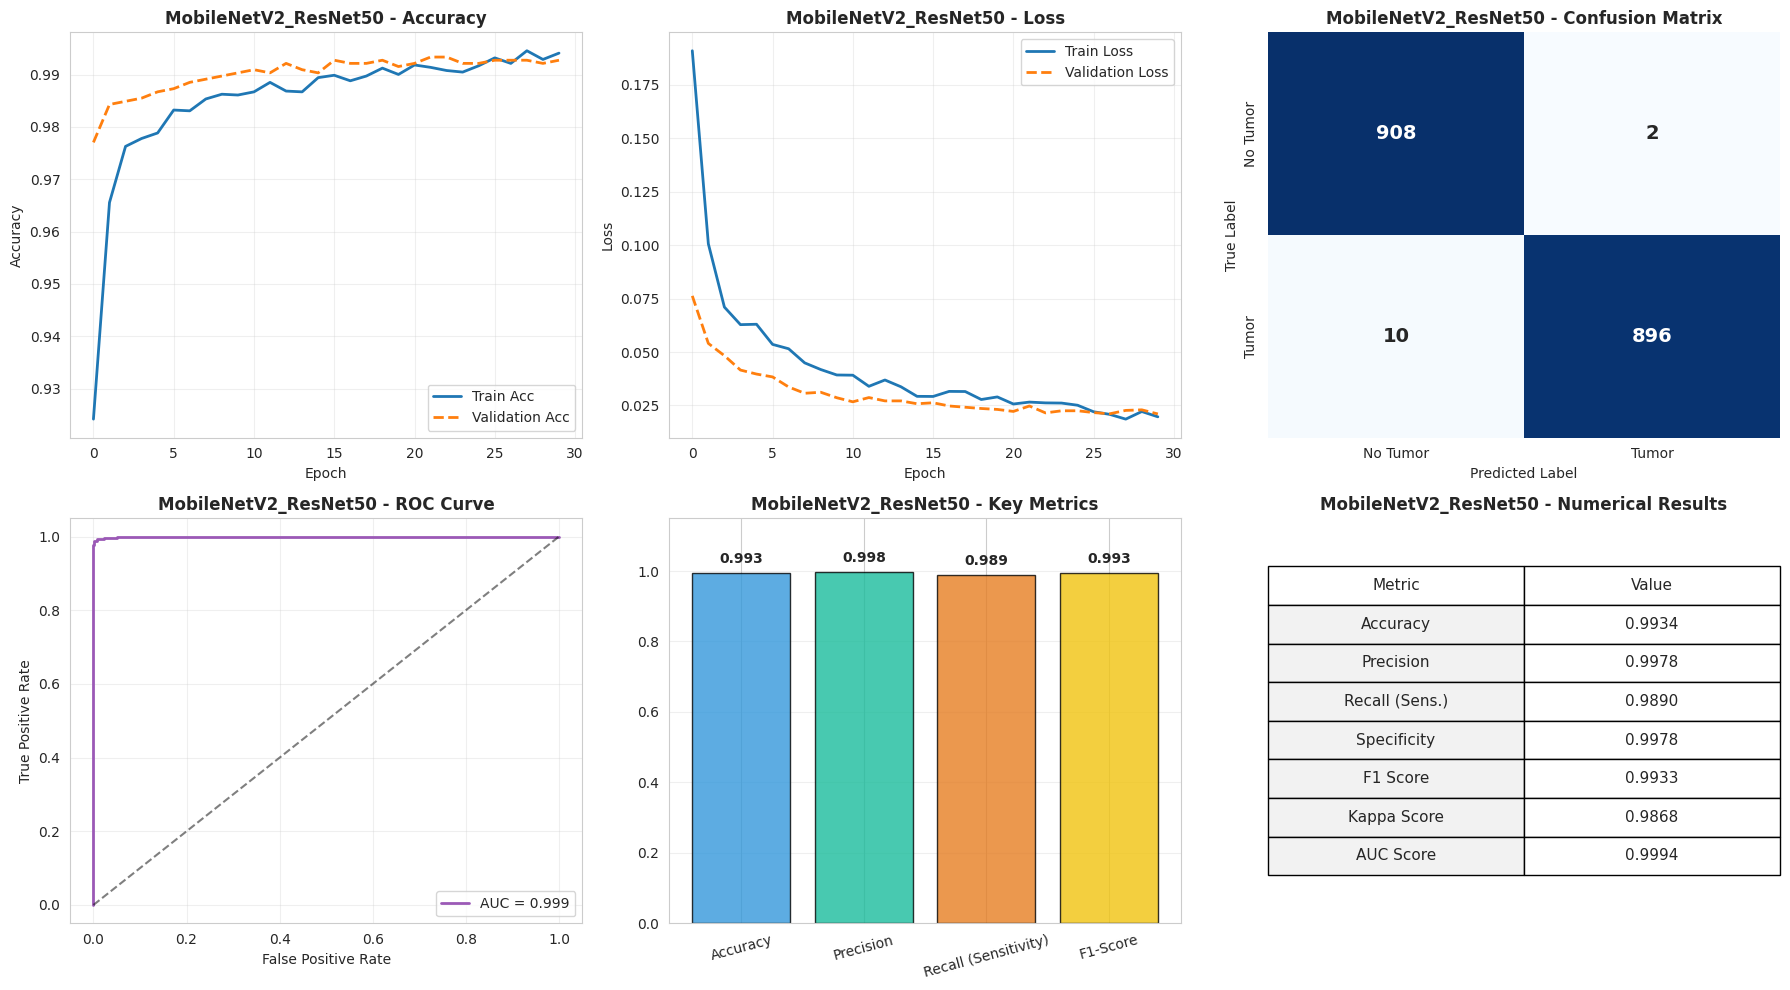

In [ ]:
# MODEL 4: EVALUATION

import pickle

# Model Name
model_name = "MobileNetV2_ResNet50"

print(f"MODEL EVALUATION: {model_name}")
print("-"*40)

# Load Model
model_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

if os.path.exists(model_path):
    model = torch.jit.load(model_path, map_location=device)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Test Set and DataLoader
# We use the test loader (224x224) for pretrained models

val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# Test set
test_dataset_eval = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_eval = DataLoader(test_dataset_eval, batch_size=32, shuffle=False, num_workers=2)

# Make a Guess
y_true_list = []
y_prob_list = []

print("Getting predictions on the test set")
with torch.no_grad():
    for images, labels in test_loader_eval:
        images = images.to(device)

        outputs = model(images).squeeze()

        y_prob_list.extend(outputs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# Calculate Metrics
metrics_eval, cm_eval, roc_data_eval = calculate_metrics(y_true_list, y_prob_list, model_name)

# Add training period information
if 'avg_epoch_time' in globals():
    metrics_eval["Avg. Epoch Time (s)"] = avg_epoch_time
else:
    metrics_eval["Avg. Epoch Time (s)"] = 0.0

# Save ROC data permanently to DRIVE
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")

# Read existing file (If exists)
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f:
        saved_roc_curves = pickle.load(f)
else:
    saved_roc_curves = {}

# Add/update data for this model
saved_roc_curves[model_name] = roc_data_eval

# Write back to file
with open(roc_pkl_path, 'wb') as f:
    pickle.dump(saved_roc_curves, f)

print(f"ROC data saved to Drive: {model_name}")

# Update CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")

new_row_df = pd.DataFrame([metrics_eval])

if os.path.exists(csv_path):
    # Read existing file first
    existing_df = pd.read_csv(csv_path)

    # Remove old record if exists to avoid duplicates
    existing_df = existing_df[existing_df['Model'] != model_name]

    # Merge old and new
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
    print(f"Added to existing table. Total models: {len(final_df)}")
else:
    # Create new if file doesn't exist
    final_df = new_row_df
    print("New CSV file created.")

# Save back to Drive
final_df.to_csv(csv_path, index=False)
print(f"Results added to CSV: {model_name}")

# Update memory
all_model_metrics = final_df.to_dict('records')

# Visualize Results
if 'history' in globals():
    plot_model_results(history, metrics_eval, cm_eval, roc_data_eval, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history was found for the graph, only numerical metrics were calculated.")



---


### **MODEL 5: HYBRID - ResNet18_MobileNetV3-Small**


---


In [ ]:
# MODEL 5: HYBRID - ResNet18_MobileNetV3-Small Train

import time

print("MODEL 5: HYBRID - ResNet18_MobileNetV3-Small Train")
print("-"*40)

# Install the Model
model_name = "ResNet18_MobileNetV3Small"
model = HybridModel(["resnet18", "mobilenet_v3_small"]).to(device)

# Optimizer ve Loss
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Callbacks
callbacks = get_callbacks(model_name, optimizer)

num_epochs = EPOCHS_PRETRAINED
history_2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time = time.time()
print(f"{model_name} training begins - Target Epoch: {num_epochs}")

for epoch in range(num_epochs):

    # TRAINING
    model.train()
    running_loss = 0; correct = 0; total = 0

    for images, labels in train_loader_pretrained:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (outputs > 0.5).int()
        correct += (preds == labels.int()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0; val_correct = 0; val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_pretrained:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = (outputs > 0.5).int()
            val_correct += (preds == labels.int()).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Save
    history_2["train_loss"].append(train_loss)
    history_2["val_loss"].append(val_loss)
    history_2["train_acc"].append(train_acc)
    history_2["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # CALLBACKS
    callbacks["checkpoint"].step(val_loss, model)
    callbacks["scheduler"].step(val_loss)

    if callbacks["early_stopping"].step(val_loss):
        print(f"\nEarly Stopping, Discontinued as of Epoch {epoch+1}")
        break

end_time = time.time()
avg_epoch_time_2 = (end_time - start_time) / (epoch + 1)
print(f"\nTRAINING DONE — Avg. Time: {avg_epoch_time_2:.2f} sec")

MODEL 5: HYBRID - ResNet18_MobileNetV3-Small Train
----------------------------------------
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 236MB/s]


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 208MB/s]


Models are frozen: resnet18 & mobilenet_v3_small...
ResNet18_MobileNetV3Small training begins - Target Epoch: 30
Epoch [1/30] - Train Loss: 0.2929, Acc: 0.8755 | Val Loss: 0.1327, Acc: 0.9595
Validation Loss improved (inf to 0.1327). Saving Full Model
Epoch [2/30] - Train Loss: 0.1725, Acc: 0.9399 | Val Loss: 0.0964, Acc: 0.9710
Validation Loss improved (0.1327 to 0.0964). Saving Full Model
Epoch [3/30] - Train Loss: 0.1500, Acc: 0.9455 | Val Loss: 0.0829, Acc: 0.9752
Validation Loss improved (0.0964 to 0.0829). Saving Full Model
Epoch [4/30] - Train Loss: 0.1317, Acc: 0.9488 | Val Loss: 0.0710, Acc: 0.9783
Validation Loss improved (0.0829 to 0.0710). Saving Full Model
Epoch [5/30] - Train Loss: 0.1241, Acc: 0.9544 | Val Loss: 0.0649, Acc: 0.9813
Validation Loss improved (0.0710 to 0.0649). Saving Full Model
Epoch [6/30] - Train Loss: 0.1190, Acc: 0.9559 | Val Loss: 0.0622, Acc: 0.9825
Validation Loss improved (0.0649 to 0.0622). Saving Full Model
Epoch [7/30] - Train Loss: 0.1141, Acc

MODEL EVALUATION: ResNet18_MobileNetV3Small
----------------------------------------
Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_ResNet18_MobileNetV3Small.pt
Getting predictions on the test set
Added to existing table. Total models: 12
Results added to CSV: ResNet18_MobileNetV3Small


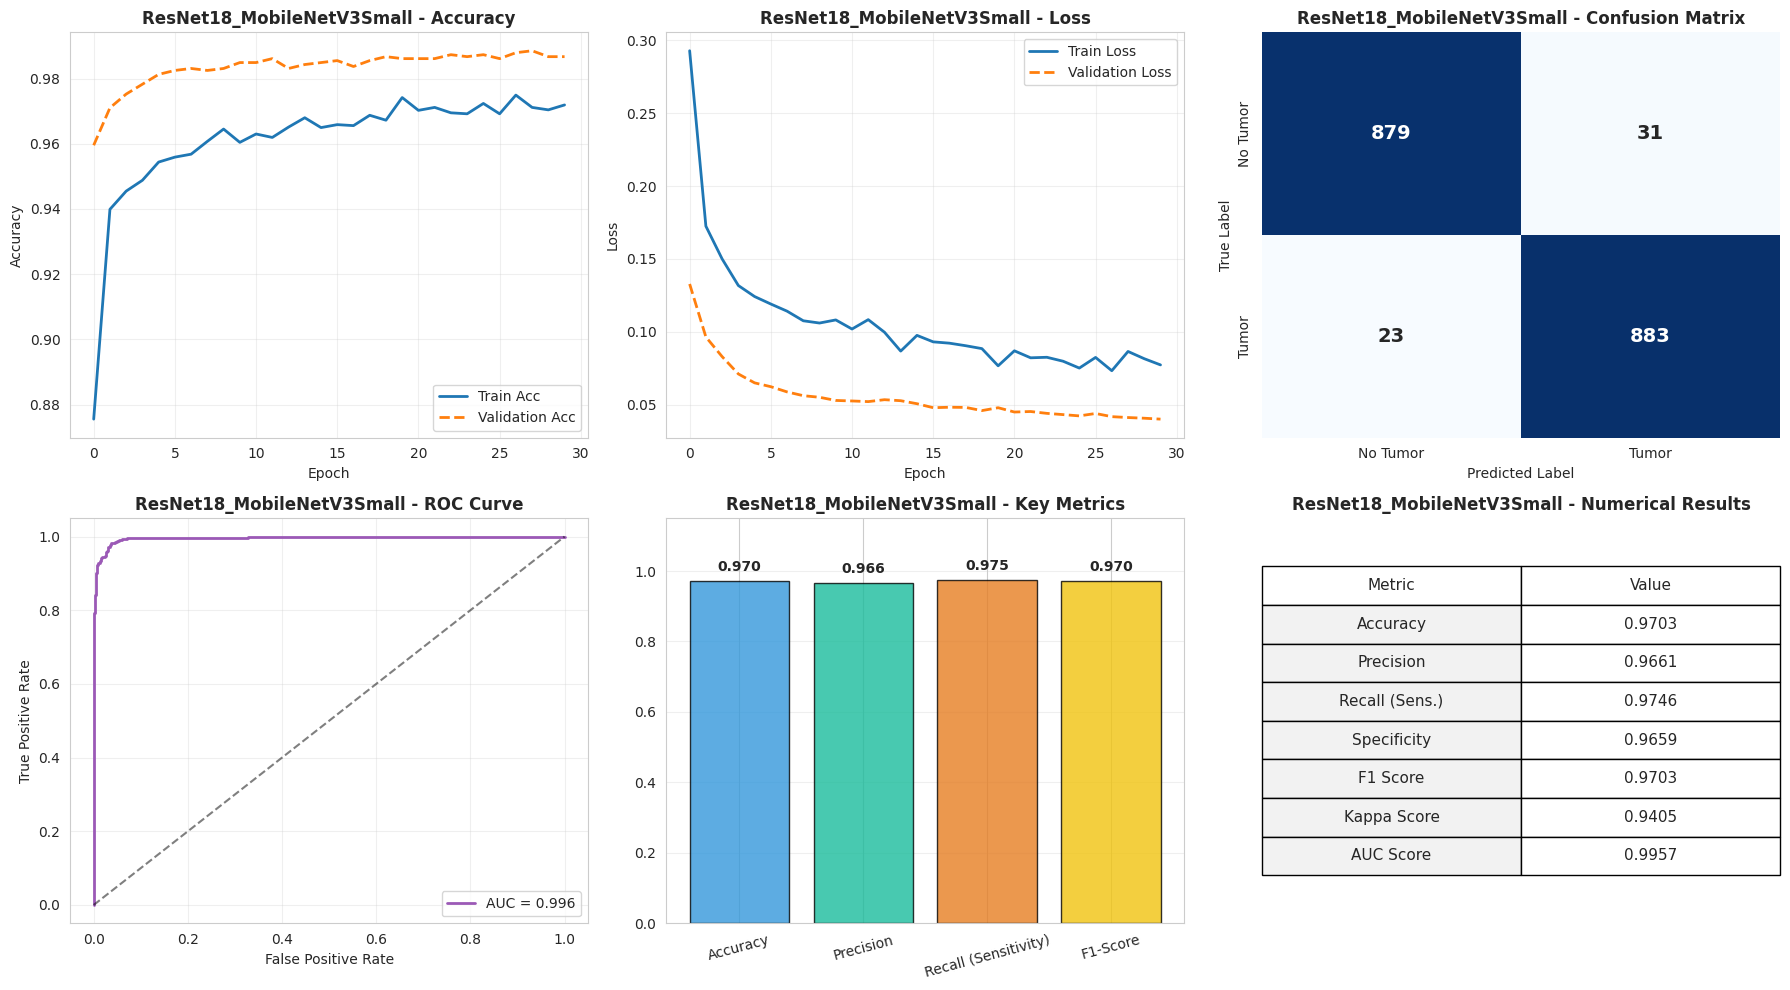

In [ ]:
# MODEL 5: EVALUATION

import pickle

# Model Name
model_name = "ResNet18_MobileNetV3Small"

print(f"MODEL EVALUATION: {model_name}")
print("-"*40)

# Load Model
model_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

if os.path.exists(model_path):
    model = torch.jit.load(model_path, map_location=device)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Test Set and DataLoader
# Clean (normalized only) dataset of 224x224 size for pretrained models
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

test_dataset_eval = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_eval = DataLoader(test_dataset_eval, batch_size=32, shuffle=False, num_workers=2)

# Make guess
y_true_list = []
y_prob_list = []

print("Getting predictions on the test set")
with torch.no_grad():
    for images, labels in test_loader_eval:
        images = images.to(device)

        outputs = model(images).squeeze()

        y_prob_list.extend(outputs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# Calculate Metrics
metrics_2, cm_2, roc_data_2 = calculate_metrics(y_true_list, y_prob_list, model_name)

# Add training period information
if 'avg_epoch_time_2' in globals():
    metrics_2["Avg. Epoch Time (s)"] = avg_epoch_time_2
else:
    metrics_2["Avg. Epoch Time (s)"] = 0.0

# Save ROC Curve Data
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")

# Read existing file (If exists)
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f:
        saved_roc_curves = pickle.load(f)
else:
    saved_roc_curves = {}

# Add/update data for this model
saved_roc_curves[model_name] = roc_data_2

# Update CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")

new_row_df = pd.DataFrame([metrics_2])

if os.path.exists(csv_path):
    # Read existing file first
    existing_df = pd.read_csv(csv_path)

    # Remove old record if exists to avoid duplicates
    existing_df = existing_df[existing_df['Model'] != model_name]

    # Merge old and new
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
    print(f"Added to existing table. Total models: {len(final_df)}")
else:
    # Create new if file doesn't exist
    final_df = new_row_df
    print("New CSV file created.")

# Save back to Drive
final_df.to_csv(csv_path, index=False)
print(f"Results added to CSV: {model_name}")

# Visualize Results
if 'history_2' in globals():
    plot_model_results(history_2, metrics_2, cm_2, roc_data_2, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history (history_2) found for the graph, only numerical metrics calculated.")



---


### **MODEL 6: HYBRİD - EfficientNet-B0_ShuffleNetV2**


---


In [ ]:
# MODEL 6: HYBRID - EfficientNet-B0_ShuffleNetV2 TRAIN

import time

print("MODEL 6: HYBRID - EfficientNet-B0_ShuffleNetV2 TRAIN")
print("-"*50)

# Build Model
model_name = "EfficientNetB0_ShuffleNetV2"
model = HybridModel(["efficientnet_b0", "shufflenet_v2_x1_0"]).to(device)

# Optimizer ve Loss
criterion = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

# Callbacks
callbacks = get_callbacks(model_name, optimizer)

num_epochs = EPOCHS_PRETRAINED
history_3 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

start_time = time.time()
print(f"{model_name} training begins - Target Epoch: {num_epochs}")

for epoch in range(num_epochs):

    # TRAINING
    model.train()
    running_loss = 0; correct = 0; total = 0

    for images, labels in train_loader_pretrained:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = (outputs > 0.5).int()
        correct += (preds == labels.int()).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0; val_correct = 0; val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_pretrained:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            preds = (outputs > 0.5).int()
            val_correct += (preds == labels.int()).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Save
    history_3["train_loss"].append(train_loss)
    history_3["val_loss"].append(val_loss)
    history_3["train_acc"].append(train_acc)
    history_3["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # CALLBACKS
    callbacks["checkpoint"].step(val_loss, model)
    callbacks["scheduler"].step(val_loss)

    if callbacks["early_stopping"].step(val_loss):
        print(f"\nEarly Stopping, Discontinued as of Epoch {epoch+1}")
        break

end_time = time.time()
avg_epoch_time_3 = (end_time - start_time) / (epoch + 1)
print(f"\nTRAINING DONE — Avg. Time: {avg_epoch_time_3:.2f} sec")

MODEL 6: HYBRID - EfficientNet-B0_ShuffleNetV2 TRAIN
--------------------------------------------------
Models are frozen: efficientnet_b0 & shufflenet_v2_x1_0...
EfficientNetB0_ShuffleNetV2 training begins - Target Epoch: 30
Epoch [1/30] - Train Loss: 0.2130, Acc: 0.9192 | Val Loss: 0.1051, Acc: 0.9668
Validation Loss improved (inf to 0.1051). Saving Full Model
Epoch [2/30] - Train Loss: 0.1240, Acc: 0.9591 | Val Loss: 0.0800, Acc: 0.9728
Validation Loss improved (0.1051 to 0.0800). Saving Full Model
Epoch [3/30] - Train Loss: 0.1048, Acc: 0.9648 | Val Loss: 0.0654, Acc: 0.9758
Validation Loss improved (0.0800 to 0.0654). Saving Full Model
Epoch [4/30] - Train Loss: 0.1013, Acc: 0.9653 | Val Loss: 0.0653, Acc: 0.9746
Validation Loss improved (0.0654 to 0.0653). Saving Full Model
Epoch [5/30] - Train Loss: 0.0834, Acc: 0.9712 | Val Loss: 0.0596, Acc: 0.9771
Validation Loss improved (0.0653 to 0.0596). Saving Full Model
Epoch [6/30] - Train Loss: 0.0854, Acc: 0.9713 | Val Loss: 0.0557, 

MODEL EVALUATION: EfficientNetB0_ShuffleNetV2
----------------------------------------
Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_EfficientNetB0_ShuffleNetV2.pt
Getting predictions on the test set
ROC data saved to Drive: EfficientNetB0_ShuffleNetV2
Added to existing table. Total models: 12
Results added to CSV: EfficientNetB0_ShuffleNetV2


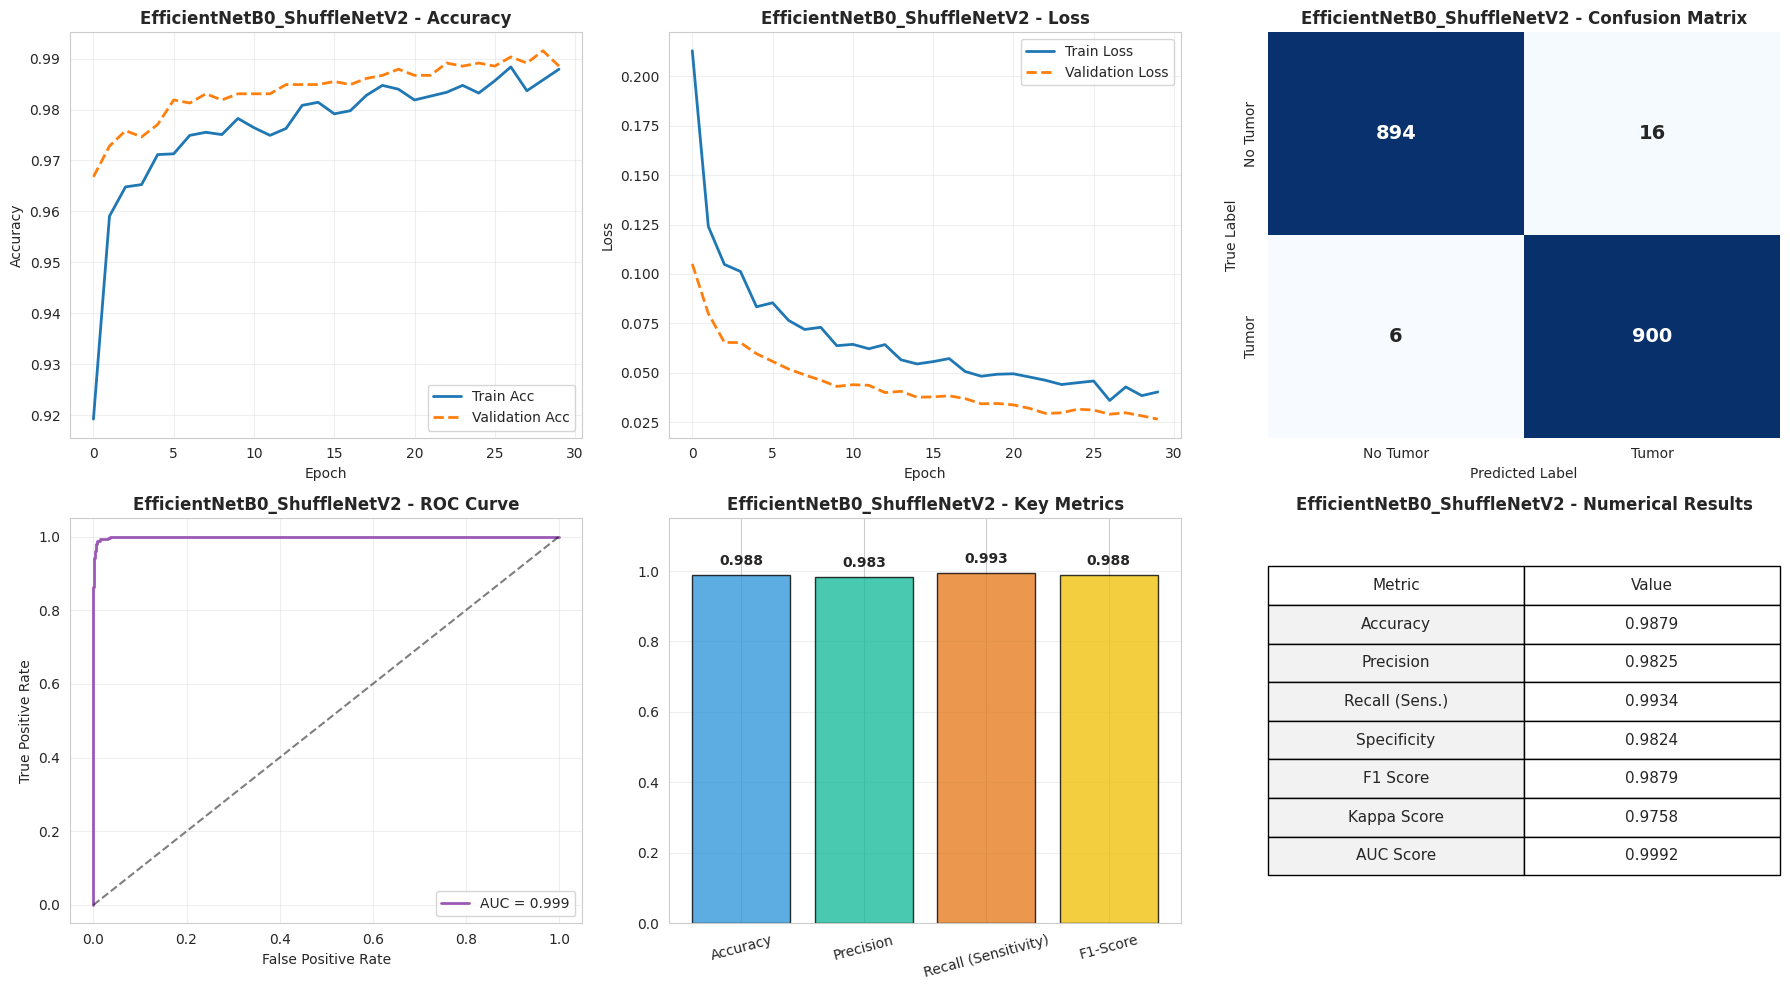

In [ ]:
# MODEL 6: EVALUATION

# Model Name
model_name = "EfficientNetB0_ShuffleNetV2"

print(f"MODEL EVALUATION: {model_name}")
print("-"*40)

# Load Model
model_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}.pt")

if os.path.exists(model_path):
    model = torch.jit.load(model_path, map_location=device)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Test Set and DataLoader
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

test_dataset_eval = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_eval = DataLoader(test_dataset_eval, batch_size=32, shuffle=False, num_workers=2)

# Make Guess
y_true_list = []
y_prob_list = []

print("Getting predictions on the test set")
with torch.no_grad():
    for images, labels in test_loader_eval:
        images = images.to(device)

        outputs = model(images).squeeze()

        y_prob_list.extend(outputs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# Calculate Metrics
metrics_3, cm_3, roc_data_3 = calculate_metrics(y_true_list, y_prob_list, model_name)

# Add training period information
if 'avg_epoch_time_3' in globals():
    metrics_3["Avg. Epoch Time (s)"] = avg_epoch_time_3
else:
    metrics_3["Avg. Epoch Time (s)"] = 0.0

# Save ROC Curve Data
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")

# Read existing file
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f:
        saved_roc_curves = pickle.load(f)
else:
    saved_roc_curves = {}

# Add/update data for this model
saved_roc_curves[model_name] = roc_data_3

# Write back to file
with open(roc_pkl_path, 'wb') as f:
    pickle.dump(saved_roc_curves, f)

print(f"ROC data saved to Drive: {model_name}")

# Update CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")

new_row_df = pd.DataFrame([metrics_3])

if os.path.exists(csv_path):
    # Read existing file first
    existing_df = pd.read_csv(csv_path)

    # Remove old record if exists to avoid duplicates
    existing_df = existing_df[existing_df['Model'] != model_name]

    # Merge old and new
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
    print(f"Added to existing table. Total models: {len(final_df)}")
else:
    # Create new if file doesn't exist
    final_df = new_row_df
    print("New CSV file created.")

# Save back to Drive
final_df.to_csv(csv_path, index=False)
print(f"Results added to CSV: {model_name}")

# Visualize Results
if 'history_3' in globals():
    plot_model_results(history_3, metrics_3, cm_3, roc_data_3, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history (history_3) found for the graph, only numerical metrics calculated.")



---


### **MODEL 7: CUSTOM - EytNet_V1**


---

In [ ]:
# Creating the EytNet_V1 Architecture

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from albumentations import Compose, Rotate, HorizontalFlip, ShiftScaleRotate, RandomGamma, GridDistortion, CoarseDropout, Normalize
from albumentations.pytorch import ToTensorV2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# AUXILIARY BLOCKS

class IdentityBlock(nn.Module):
    def __init__(self, in_channels, filters):
        super(IdentityBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(filters)
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(filters)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

class ConvBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=2):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(filters)
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(filters)

        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, padding=0),
            nn.BatchNorm2d(filters)
        )

    def forward(self, x):
        residual = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

# MAIN MODEL: EytNet_V1

class EytNetV1(nn.Module):
    def __init__(self):
        super(EytNetV1, self).__init__()

        # Login Block
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Feature Extractor Blocks
        self.block1 = nn.Sequential(ConvBlock(64, 64, stride=1), IdentityBlock(64, 64))
        self.block2 = nn.Sequential(ConvBlock(64, 128, stride=2), IdentityBlock(128, 128))
        self.block3 = nn.Sequential(ConvBlock(128, 256, stride=2), IdentityBlock(256, 256))

        # Classifier
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)

        x = self.initial(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

# PROGRESSIVE DATA LOADER
def get_progressive_loader(image_size, batch_size):
    print(f"\nPreparing Data Set: {image_size}x{image_size} pixel")

    transform_train = Compose([
        Rotate(limit=10, p=0.3),
        HorizontalFlip(p=0.3),
        ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
        RandomGamma(gamma_limit=(80,120), p=0.3),
        GridDistortion(num_steps=50, distort_limit=0.04, p=0.1),
        CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=1, min_height=8, min_width=8, p=0.3),
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    transform_val = Compose([
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    ds_train = MRIDataset(file_paths=train_paths, labels=train_labels, transform=transform_train, preprocess_size=(image_size, image_size))
    ds_val = MRIDataset(file_paths=val_paths, labels=val_labels, transform=transform_val, preprocess_size=(image_size, image_size))

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2)

    return dl_train, dl_val

print("EytNet_V1 Architecture is Ready")

EytNet_V1 Architecture is Ready


In [ ]:
# Training the EytNet_V1 Model

import time
import os

model_name = "EytNet_V1"
print(f"Model training begins: {model_name}")
print("-" * 40)

# Start Model
model = EytNetV1().to(device)

# Logits Loss
criterion = torch.nn.BCEWithLogitsLoss()

# Epoch Helper Functions
def train_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0; correct = 0; total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.float().to(device)
        optimizer.zero_grad()

        logits = model(images).squeeze()
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss/total, correct/total

def validate_epoch(model, loader):
    model.eval()
    val_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.float().to(device)
            logits = model(images).squeeze()
            loss = criterion(logits, labels)
            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return val_loss/total, correct/total


# STAGE 1: 64x64
print("\nSTAGE 1: 64x64")
train_loader_64, val_loader_64 = get_progressive_loader(64, 32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(10):
    tl, ta = train_epoch(model, train_loader_64, optimizer)
    vl, va = validate_epoch(model, val_loader_64)
    print(f"Epoch {epoch+1}/10 | Train Acc: {ta:.4f} | Val Acc: {va:.4f}")

# STAGE 2: 112x112
print("\n-STAGE 2: 112x112")
train_loader_112, val_loader_112 = get_progressive_loader(112, 32)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

for epoch in range(10):
    tl, ta = train_epoch(model, train_loader_112, optimizer)
    vl, va = validate_epoch(model, val_loader_112)
    print(f"Epoch {epoch+1}/10 | Train Acc: {ta:.4f} | Val Acc: {va:.4f}")

# STAGE 3: 224x224
print("\STAGE 3: 224x224")
train_loader_224, val_loader_224 = get_progressive_loader(224, 16)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

history_eytnet = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float('inf')
patience = 6
counter = 0

start_time = time.time()

for epoch in range(35):
    tl, ta = train_epoch(model, train_loader_224, optimizer)
    vl, va = validate_epoch(model, val_loader_224)

    history_eytnet["train_loss"].append(tl)
    history_eytnet["val_loss"].append(vl)
    history_eytnet["train_acc"].append(ta)
    history_eytnet["val_acc"].append(va)

    print(f"Epoch {epoch+1}/35 | T.Loss: {tl:.4f} T.Acc: {ta:.4f} | V.Loss: {vl:.4f} V.Acc: {va:.4f}")

    # TORCHSCRIPT SAVING MECHANISM
    if vl < best_val_loss:
        best_val_loss = vl
        counter = 0

        # We convert the model into a script and save it
        model_scripted = torch.jit.script(model)
        save_name = f"best_model_{model_name}_Final.pt"
        torch.jit.save(model_scripted, os.path.join(DRIVE_SAVE_PATH, save_name))

        print(f" Best Model Saved: {save_name}")
    else:
        counter += 1
        if counter >= patience:
            print("\nEarly Stopping, Training is being terminated.")
            break

# Time Calculation
end_time = time.time()
avg_epoch_time_eytnet = (end_time - start_time) / (len(history_eytnet['train_loss']))
print(f"\n{model_name} Training Completed Successfully.")

Model training begins: EytNet_V1
----------------------------------------

STAGE 1: 64x64

Preparing Data Set: 64x64 pixel
Epoch 1/10 | Train Acc: 0.9062 | Val Acc: 0.9704
Epoch 2/10 | Train Acc: 0.9476 | Val Acc: 0.8684
Epoch 3/10 | Train Acc: 0.9509 | Val Acc: 0.6371
Epoch 4/10 | Train Acc: 0.9562 | Val Acc: 0.9263
Epoch 5/10 | Train Acc: 0.9630 | Val Acc: 0.9795
Epoch 6/10 | Train Acc: 0.9689 | Val Acc: 0.9819
Epoch 7/10 | Train Acc: 0.9698 | Val Acc: 0.9849
Epoch 8/10 | Train Acc: 0.9725 | Val Acc: 0.9716
Epoch 9/10 | Train Acc: 0.9725 | Val Acc: 0.9746
Epoch 10/10 | Train Acc: 0.9766 | Val Acc: 0.9819

-STAGE 2: 112x112

Preparing Data Set: 112x112 pixel
Epoch 1/10 | Train Acc: 0.9722 | Val Acc: 0.9861
Epoch 2/10 | Train Acc: 0.9790 | Val Acc: 0.9885
Epoch 3/10 | Train Acc: 0.9807 | Val Acc: 0.9855
Epoch 4/10 | Train Acc: 0.9838 | Val Acc: 0.9861
Epoch 5/10 | Train Acc: 0.9840 | Val Acc: 0.9909
Epoch 6/10 | Train Acc: 0.9873 | Val Acc: 0.9855
Epoch 7/10 | Train Acc: 0.9885 | Val A

MODEL EVALUATION: EytNet_V1
----------------------------------------
Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_EytNet_V1_Final.pt
Test Set Size: 1816 images
Running inference on test set
ROC data saved: EytNet_V1
Results added to CSV: EytNet_V1


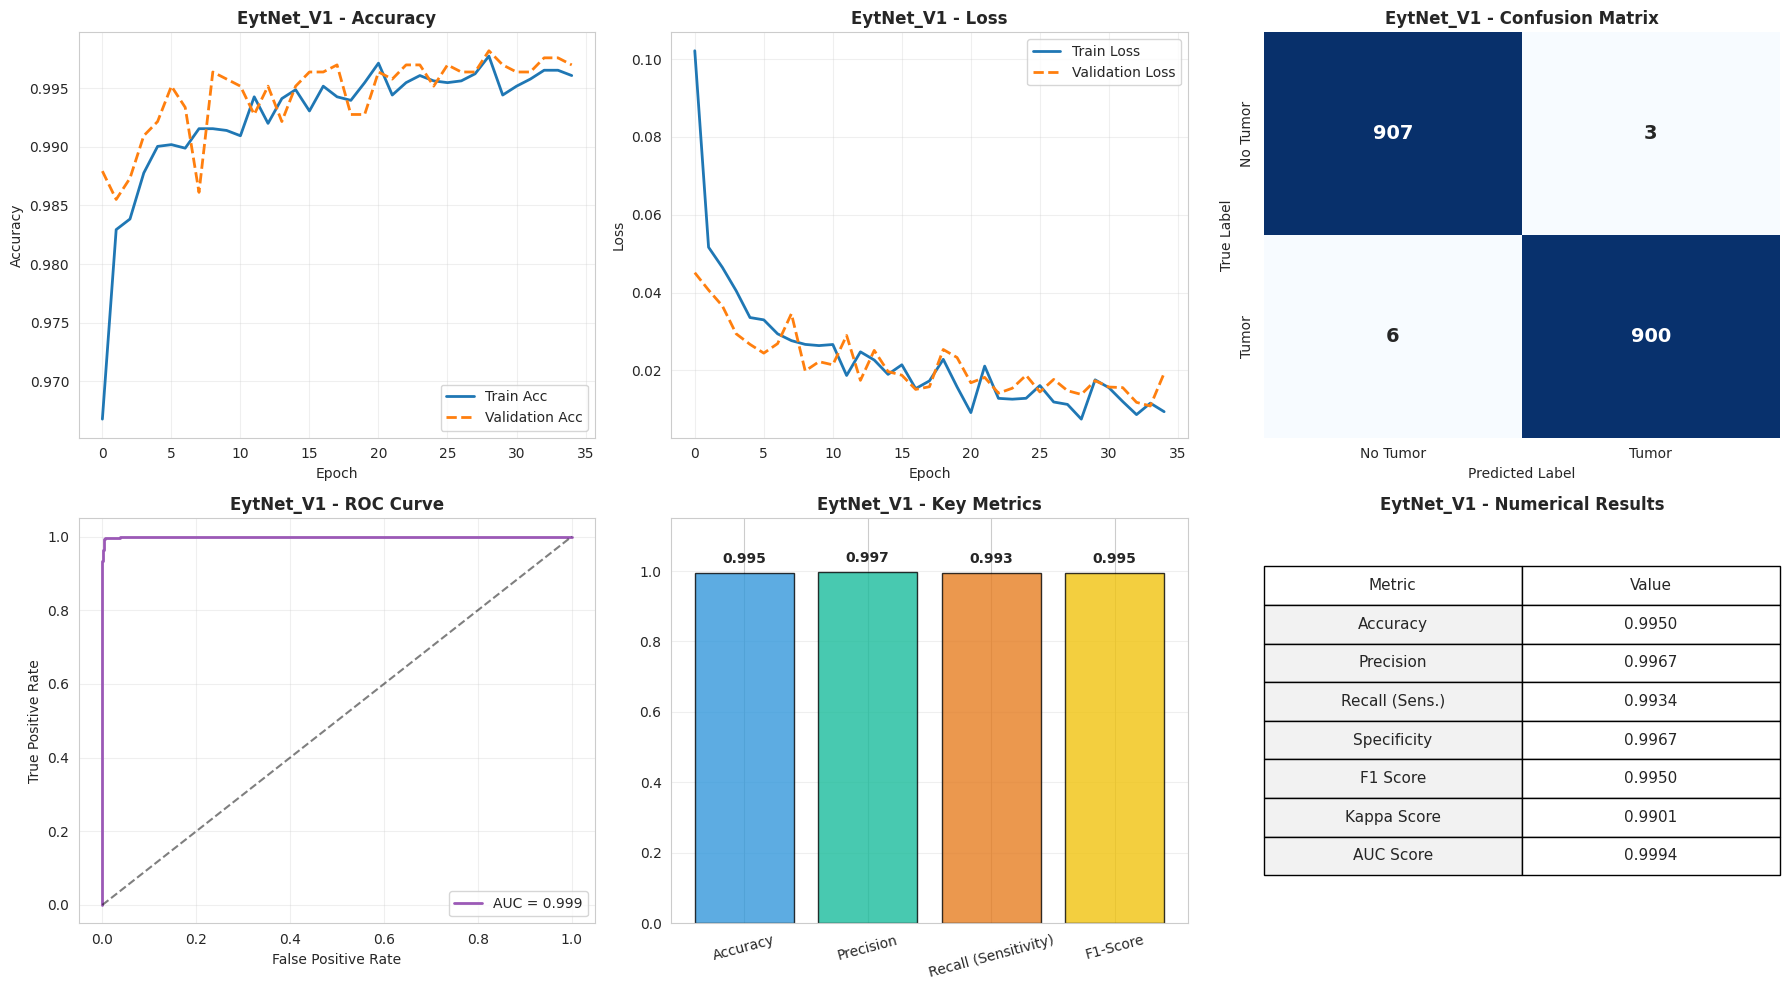

In [ ]:
# EVALUATION OF THE EYTNET_V1 MODEL

import pickle
import pandas as pd
import os
import torch
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# Model Name
model_name = "EytNet_V1"
file_name = f"best_model_{model_name}_Final.pt"

print(f"MODEL EVALUATION: {model_name}")
print("-" * 40)

# Load Model (JIT Format)
model_path = os.path.join(DRIVE_SAVE_PATH, file_name)

if os.path.exists(model_path):
    model = torch.jit.load(model_path, map_location=device)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Prepare Test Set
# No Augmentation, just Normalize (224x224)
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

test_dataset_eval = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_eval = DataLoader(test_dataset_eval, batch_size=16, shuffle=False, num_workers=2)

print(f"Test Set Size: {len(test_dataset_eval)} images")

# Run Inference
y_true_list = []
y_prob_list = []

print("Running inference on test set")
with torch.no_grad():
    for images, labels in test_loader_eval:
        images = images.to(device)

        # Forward pass (Returns Logits)
        logits = model(images).squeeze()

        # Convert Logits to Probabilities using Sigmoid
        probs = torch.sigmoid(logits)

        y_prob_list.extend(probs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# Calculate Metrics
metrics_eytnet, cm_eytnet, roc_data_eytnet = calculate_metrics(y_true_list, y_prob_list, model_name)

# Add training time info
if 'avg_epoch_time_eytnet' in globals():
    metrics_eytnet["Avg. Epoch Time (s)"] = avg_epoch_time_eytnet
else:
    metrics_eytnet["Avg. Epoch Time (s)"] = 0.0

# Save ROC Data
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")

if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f:
        saved_roc_curves = pickle.load(f)
else:
    saved_roc_curves = {}

saved_roc_curves[model_name] = roc_data_eytnet

with open(roc_pkl_path, 'wb') as f:
    pickle.dump(saved_roc_curves, f)

print(f"ROC data saved: {model_name}")

# Update Comparison CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_eytnet])

if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    # Remove duplicates
    existing_df = existing_df[existing_df['Model'] != model_name]
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
else:
    final_df = new_row_df

final_df.to_csv(csv_path, index=False)
print(f"Results added to CSV: {model_name}")

# Visualize Results
if 'history_eytnet' in globals():
    plot_model_results(history_eytnet, metrics_eytnet, cm_eytnet, roc_data_eytnet, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history (history_eytnet) found for visualization.")

---
### **MODEL 8: CUSTOM - EytNet_V1_Opt (OPTIMIZED)**
---

In [ ]:
# PROGRESSIVE DATA LOADER

import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from albumentations import Compose, Rotate, HorizontalFlip, ShiftScaleRotate, RandomGamma, GridDistortion, CoarseDropout, Normalize
from albumentations.pytorch import ToTensorV2

def get_progressive_loader(image_size, batch_size):
    print(f"\nDataset is being prepared: {image_size}x{image_size}")

    # DEFINE TRANSFORMS
    transform_train = Compose([
        Rotate(limit=10, p=0.3),
        HorizontalFlip(p=0.3),
        ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
        RandomGamma(gamma_limit=(80,120), p=0.3),
        GridDistortion(num_steps=50, distort_limit=0.04, p=0.1),
        CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=1, min_height=8, min_width=8, p=0.3),
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    # Clean Transform for Validation
    transform_val = Compose([
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    # LOAD FULL DATASETS
    full_train_dataset = MRIDataset(root_dir=train_dir, transform=transform_train, preprocess_size=(image_size, image_size))
    full_val_dataset   = MRIDataset(root_dir=train_dir, transform=transform_val, preprocess_size=(image_size, image_size))

    # SPLIT INDICES (80% Train, 20% Val)
    train_idx, val_idx = train_test_split(
        np.arange(len(full_train_dataset)),
        test_size=0.2,
        random_state=42,
        stratify=full_train_dataset.labels
    )

    # CREATE SUBSETS
    ds_train = Subset(full_train_dataset, train_idx)
    ds_val   = Subset(full_val_dataset, val_idx)

    # CREATE DATALOADERS
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2)

    return dl_train, dl_val

print("Progressive Loader function defined")

Progressive Loader function defined


In [ ]:
# Creating the EytNet_V1_Opt (OPTIMIZED) Architecture
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, stride=1, padding=1, bias=False):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel_size=kernel_size, stride=stride,
                            padding=padding, groups=in_ch, bias=bias)
        self.pw = nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=bias)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.SiLU()
    def forward(self, x):
        x = self.dw(x)
        x = self.pw(x)
        x = self.bn(x)
        x = self.act(x)
        return x

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=True),
            nn.Sigmoid()
        )
    def forward(self, x):
        b, c, _, _ = x.shape
        s = self.pool(x).view(b, c)
        s = self.fc(s).view(b, c, 1, 1)
        return x * s

class IdentityBlock(nn.Module):
    def __init__(self, in_channels, filters):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(in_channels, filters, kernel_size=3, padding=1, stride=1)
        self.conv2 = DepthwiseSeparableConv(filters, filters, kernel_size=3, padding=1, stride=1)
        self.se = SEBlock(filters)
    def forward(self, x):
        residual = x
        out = self.conv1(x)
        out = self.conv2(out)
        out = self.se(out)
        out = out + residual
        return out

class ConvBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=2):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(in_channels, filters, kernel_size=3, padding=1, stride=stride)
        self.conv2 = DepthwiseSeparableConv(filters, filters, kernel_size=3, padding=1, stride=1)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(filters)
        )
    def forward(self, x):
        residual = self.shortcut(x)
        out = self.conv1(x)
        out = self.conv2(out)
        out = out + residual
        return out

class EytNet_V1_Opt(nn.Module):
    def __init__(self):
        super().__init__()
        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.SiLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        # Blocks
        self.block1 = nn.Sequential(ConvBlock(64, 64, stride=1), IdentityBlock(64, 64))
        self.block2 = nn.Sequential(ConvBlock(64, 128, stride=2), IdentityBlock(128, 128))
        self.block3 = nn.Sequential(ConvBlock(128, 256, stride=2), IdentityBlock(256, 256))
        # Pool + classifier
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.SiLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )
        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        x = self.initial(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

print("EytNet_V1_Opt Architecture Ready")

EytNet_V1_Opt Architecture Ready


In [ ]:
# Training the EytNet_V1_Opt (OPTIMIZED)

import time, os, numpy as np
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim.swa_utils import AveragedModel, update_bn

model_name = "EytNet_V1_Opt"
print(f"MODEL TRAINING STARTED: {model_name}")

model = EytNet_V1_Opt().to(device)

criterion = torch.nn.BCEWithLogitsLoss(reduction='none')

# MixUp helper
def mixup_data(images, labels, alpha=0.4):
    if alpha <= 0:
        return images, labels
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(images.size(0))
    mixed = lam * images + (1 - lam) * images[idx]
    labels_a, labels_b = labels, labels[idx]
    return mixed, (labels_a, labels_b, lam)

def mixup_criterion(crit, preds, labels_tuple):
    labels_a, labels_b, lam = labels_tuple
    loss_a = crit(preds, labels_a)
    loss_b = crit(preds, labels_b)
    return (lam * loss_a + (1 - lam) * loss_b).mean()

# Optimizer + scheduler + EMA
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# SWA Model Setup
swa_model = AveragedModel(model)
use_swa = True

# Helper train/val functions
label_smoothing = 0.05

def smooth_labels(labels, eps=0.05):
    # for binary: move target toward 0.5 by eps
    return labels * (1.0 - eps) + 0.5 * eps

def train_epoch(model, loader, optimizer, mixup_alpha=0.4):
    model.train()
    running_loss = 0.0; correct = 0; total = 0
    for images, labels in loader:
        images = images.to(device)
        labels = labels.float().to(device)
        optimizer.zero_grad()

        # MixUp
        if mixup_alpha > 0:
            images, label_tuple = mixup_data(images, labels, alpha=mixup_alpha)
            logits = model(images).squeeze()
            loss = mixup_criterion(criterion, logits, label_tuple)
        else:
            logits = model(images).squeeze()
            # label smoothing
            targets = smooth_labels(labels, eps=label_smoothing)
            loss = criterion(logits, targets).mean()

        loss.backward()
        optimizer.step()

        # update running stats
        running_loss += loss.item() * images.size(0)

        # SWA update
        if use_swa:
            swa_model.update_parameters(model)

        # Accuracy check
        probs = torch.sigmoid(logits.detach())
        preds = (probs > 0.5).float()

        if mixup_alpha == 0:
            correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct/total if total>0 else 0.0
    return running_loss/total, acc

def validate_epoch(model, loader):
    model.eval()
    val_loss = 0.0; correct = 0; total = 0
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.float().to(device)
            logits = model(images).squeeze()
            loss = criterion(logits, labels).mean()
            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return val_loss/total, correct/total

# Progressive stages
stages = [
    (64, 32, 10, 1e-3, 0.4),
    (112, 32, 10, 5e-4, 0.2),
    (224, 16, 30, 1e-4, 0.0)
]

history_eytnet_opt = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# GLOBAL BEST LOSS
global_best_val_loss = float('inf')

start_time = time.time()
final_train_loader = None

for stage_idx, (size, batch_size, epochs_stage, lr_stage, mixup_alpha) in enumerate(stages):
    print(f"\nSTAGE {stage_idx+1}: {size}px | bs={batch_size} | epochs={epochs_stage} | lr={lr_stage} | mixup={mixup_alpha}")

    # Re-create loader for stage
    train_loader, val_loader = get_progressive_loader(size, batch_size)
    final_train_loader = train_loader

    # update optimizer lr
    for g in optimizer.param_groups:
        g['lr'] = lr_stage

    # scheduler per stage
    scheduler = CosineAnnealingLR(optimizer, T_max=max(1, epochs_stage))

    # STAGE SPECIFIC VARIABLES
    stage_best_loss = float('inf')
    patience = 5 # Reset patience for each stage
    counter = 0

    for epoch in range(epochs_stage):
        tl, ta = train_epoch(model, train_loader, optimizer, mixup_alpha=mixup_alpha)
        vl, va = validate_epoch(model, val_loader)

        history_eytnet_opt["train_loss"].append(tl)
        history_eytnet_opt["val_loss"].append(vl)
        history_eytnet_opt["train_acc"].append(ta)
        history_eytnet_opt["val_acc"].append(va)

        print(f"Epoch {epoch+1}/{epochs_stage} | T.Loss: {tl:.4f} T.Acc: {ta:.4f} | V.Loss: {vl:.4f} V.Acc: {va:.4f}")
        scheduler.step()

        # Checkpoint Logic

        # Early Stopping Check
        if vl < stage_best_loss:
            stage_best_loss = vl
            counter = 0
        else:
            counter += 1

        # Model Saving Check (Global Best)
        if vl < global_best_val_loss:
            global_best_val_loss = vl

            # Save Normal Best Model
            model_to_save = model
            try:
                model_scripted = torch.jit.script(model_to_save)
                save_name = f"best_model_{model_name}_Final.pt"
                torch.jit.save(model_scripted, os.path.join(DRIVE_SAVE_PATH, save_name))
                print(f" Best Model Saved: {global_best_val_loss:.4f}")
            except Exception as e:
                print(f" Save Error: {e}")

        # Early Stopping Trigger
        if counter >= patience:
            print(" Early Stopping")
            break

# SWA FINAL SAVE
if use_swa and final_train_loader:
    try:
        # Wrapper to move data to GPU for update_bn
        class DeviceDataLoader:
            def __init__(self, dl, device):
                self.dl = dl
                self.device = device
            def __iter__(self):
                for b in self.dl:
                    yield b[0].to(self.device)
            def __len__(self):
                return len(self.dl)

        swa_model.to(device)
        update_bn(DeviceDataLoader(final_train_loader, device), swa_model)

        # Save SWA Model
        final_model_to_save = swa_model.module
        model_scripted = torch.jit.script(final_model_to_save)

        torch.jit.save(model_scripted, os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}_Final.pt"))

        print("Model updated and Saved Successfully.")
    except Exception as e:
        print(f"SWA BN update or save failed: {e}")

end_time = time.time()
avg_epoch_time_eytnet_opt = (end_time - start_time) / max(1, len(history_eytnet_opt['train_loss']))
print(f"\n{model_name} Training Completed. Avg. epoch duration: {avg_epoch_time_eytnet_opt:.2f}sec")

MODEL TRAINING STARTED: EytNet_V1_Opt

STAGE 1: 64px | bs=32 | epochs=10 | lr=0.001 | mixup=0.4

Dataset is being prepared: 64x64
Epoch 1/10 | T.Loss: 0.3993 T.Acc: 0.0000 | V.Loss: 0.3043 V.Acc: 0.8877
 Best Model Saved: 0.3043
Epoch 2/10 | T.Loss: 0.3718 T.Acc: 0.0000 | V.Loss: 0.1430 V.Acc: 0.9728
 Best Model Saved: 0.1430
Epoch 3/10 | T.Loss: 0.3343 T.Acc: 0.0000 | V.Loss: 0.1878 V.Acc: 0.9583
Epoch 4/10 | T.Loss: 0.3334 T.Acc: 0.0000 | V.Loss: 0.1854 V.Acc: 0.9390
Epoch 5/10 | T.Loss: 0.3038 T.Acc: 0.0000 | V.Loss: 0.1014 V.Acc: 0.9771
 Best Model Saved: 0.1014
Epoch 6/10 | T.Loss: 0.2809 T.Acc: 0.0000 | V.Loss: 0.0946 V.Acc: 0.9819
 Best Model Saved: 0.0946
Epoch 7/10 | T.Loss: 0.2909 T.Acc: 0.0000 | V.Loss: 0.0940 V.Acc: 0.9795
 Best Model Saved: 0.0940
Epoch 8/10 | T.Loss: 0.2760 T.Acc: 0.0000 | V.Loss: 0.1430 V.Acc: 0.9517
Epoch 9/10 | T.Loss: 0.2781 T.Acc: 0.0000 | V.Loss: 0.0664 V.Acc: 0.9897
 Best Model Saved: 0.0664
Epoch 10/10 | T.Loss: 0.2752 T.Acc: 0.0000 | V.Loss: 0.06

MODEL EVALUATION: EytNet_V1_Opt
----------------------------------------
Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_EytNet_V1_Opt_Final.pt
Scanning Test Folder: /content/drive/MyDrive/mr_dataset_new/Testing
Test Images Found: Total 1816
Predictions are being taken
DEBUG (First 5 Predictions): [0.02415721 0.07975151 0.05585982 0.16439468 0.02053155]
DEBUG (First 5 Actual): [0. 0. 0. 0. 0.]

------------------------------
RESULTS
------------------------------
Accuracy : 0.9477
F1 Score : 0.0000
AUC      : 0.9857
ROC data saved to Drive: EytNet_V1_Opt
Results added to CSV. Total models: 12
Results successfully saved: EytNet_V1_Opt


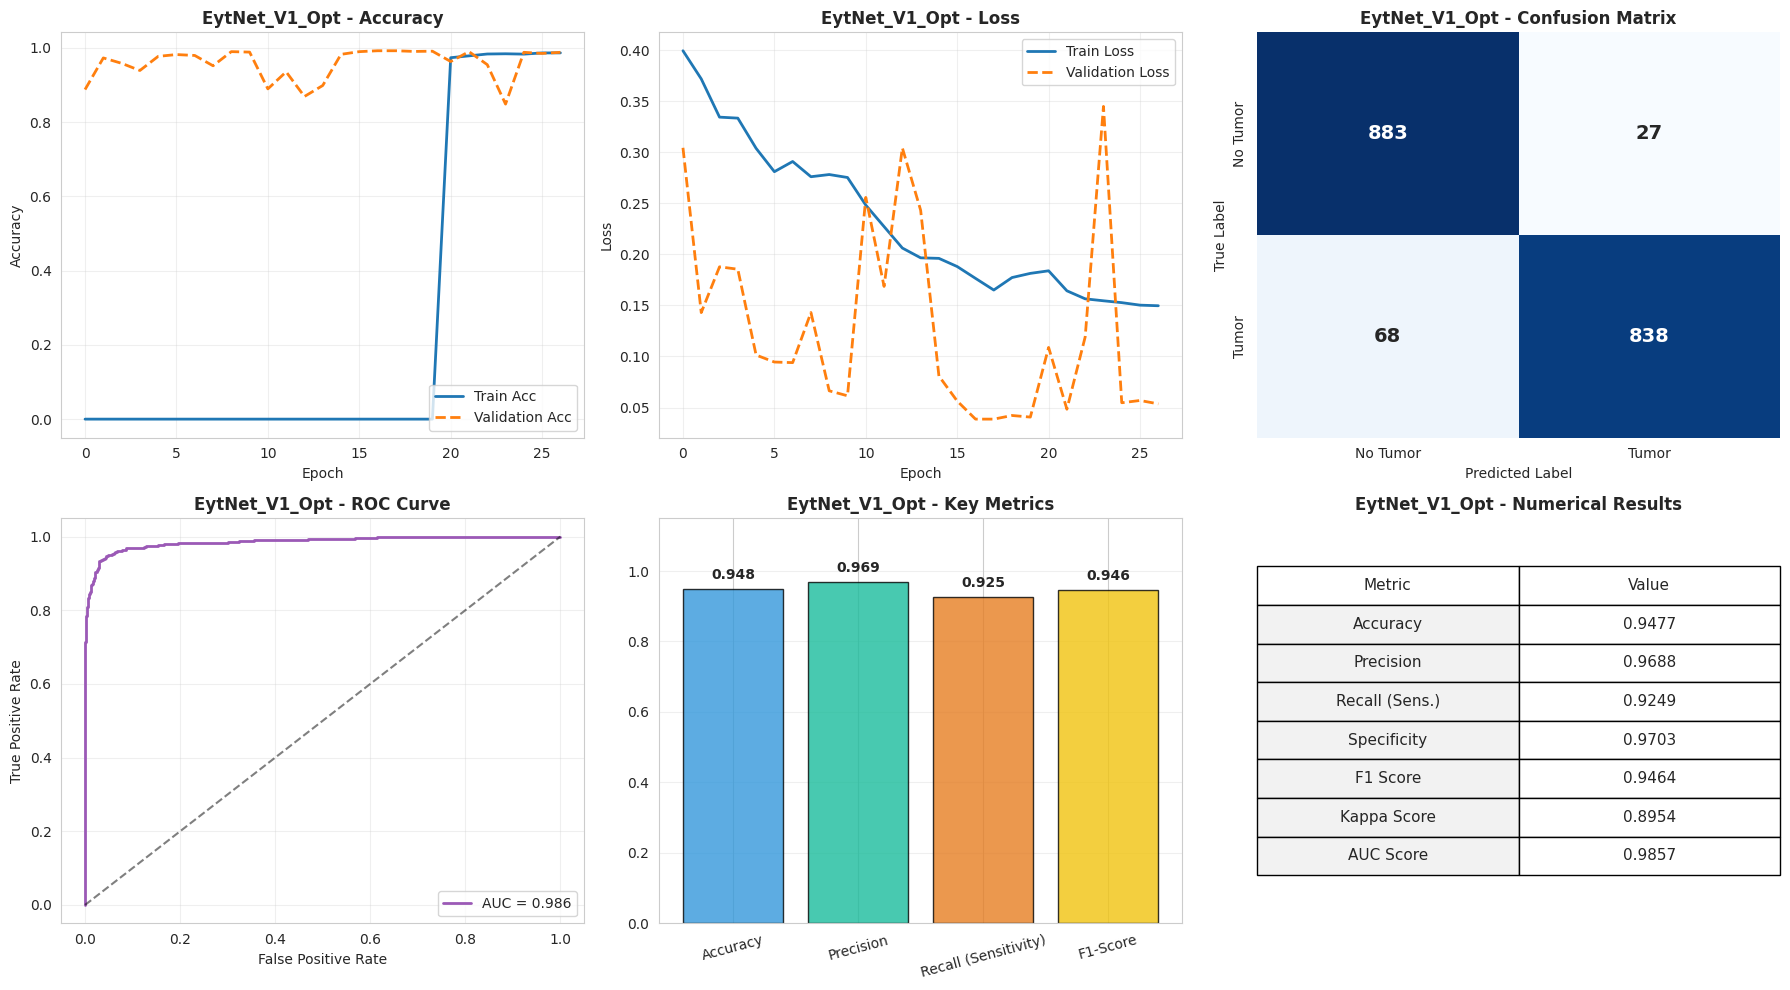

In [ ]:
# Evaluation of the EytNet_V1_Opt (OPTIMIZED)

import pickle
import pandas as pd
import os
import torch
import numpy as np
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# Model Name
model_name = "EytNet_V1_Opt"
file_name = f"best_model_{model_name}_Final.pt"

print(f"MODEL EVALUATION: {model_name}")
print("-" * 40)

# Load Model
model_path = os.path.join(DRIVE_SAVE_PATH, file_name)

if os.path.exists(model_path):
    # Using JIT load as per training save method
    model = torch.jit.load(model_path, map_location=device)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Test Set (224x224)
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# Dataset and Loader
print(f"Scanning Test Folder: {test_dir}")

test_dataset_eval = MRIDataset(
    root_dir=test_dir,
    transform=val_transform_clean,
    preprocess_size=(224, 224)
)

# Safety Check
if len(test_dataset_eval) == 0:
    raise ValueError(f"ERROR: No files found at '{test_dir}'")

print(f"Test Images Found: Total {len(test_dataset_eval)}")

test_loader_eval = DataLoader(test_dataset_eval, batch_size=16, shuffle=False, num_workers=2)

# Make guess
y_true_list = []
y_prob_list = []

print("Predictions are being taken")
with torch.no_grad():
    for i, (images, labels) in enumerate(test_loader_eval):
        images = images.to(device)

        # Black Image Check (Debug)
        if i == 0 and images.sum().item() == 0:
            print("WARNING: First batch consists entirely of BLACK pixels. Possible file reading error.")

        outputs = model(images).squeeze()
        probs = torch.sigmoid(outputs)

        y_prob_list.extend(probs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

        # Debug First Batch
        if i == 0:
            print(f"DEBUG (First 5 Predictions): {probs[:5].cpu().numpy()}")
            print(f"DEBUG (First 5 Actual): {labels[:5].cpu().numpy()}")

# Calculate Metrics
metrics_opt, cm_opt, roc_data_opt = calculate_metrics(y_true_list, y_prob_list, model_name)

# Print Results
print("\n" + "-"*30)
print("RESULTS")
print("-"*30)
print(f"Accuracy : {metrics_opt.get('Accuracy', 0):.4f}")
print(f"F1 Score : {metrics_opt.get('F1 Score', 0):.4f}")
print(f"AUC      : {metrics_opt.get('AUC', 0):.4f}")

# Add training period
if 'avg_epoch_time_eytnet_opt' in globals():
    metrics_opt["Avg. Epoch Time (s)"] = avg_epoch_time_eytnet_opt
else:
    metrics_opt["Avg. Epoch Time (s)"] = 0.0

# Save ROC Curve
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f:
        saved_roc_curves = pickle.load(f)
else:
    saved_roc_curves = {}

saved_roc_curves[model_name] = roc_data_opt
with open(roc_pkl_path, 'wb') as f:
    pickle.dump(saved_roc_curves, f)

print(f"ROC data saved to Drive: {model_name}")

# Update CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_opt])

if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    # Remove old record
    existing_df = existing_df[existing_df['Model'] != model_name]
    # Merge
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
    print(f"Results added to CSV. Total models: {len(final_df)}")
else:
    final_df = new_row_df
    print("New CSV file created.")

final_df.to_csv(csv_path, index=False)
print(f"Results successfully saved: {model_name}")

# Visualize
if 'history_eytnet_opt' in globals():
    plot_model_results(history_eytnet_opt, metrics_opt, cm_opt, roc_data_opt, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history (history_eytnet_opt) found for the graph, only numerical metrics calculated.")

---
### **MODEL 9: CUSTOM - EytNet_V1_High (HIGH PERFORMANCE)**
---

In [ ]:
# LOADER FUNCTION

import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from albumentations import Compose, Rotate, HorizontalFlip, ShiftScaleRotate, RandomGamma, GridDistortion, CoarseDropout, Normalize
from albumentations.pytorch import ToTensorV2

def get_progressive_loader(image_size, batch_size):
    print(f"\nDataset is being prepared: {image_size}x{image_size}")

    # DEFINE TRANSFORMS
    transform_train = Compose([
        Rotate(limit=10, p=0.3),
        HorizontalFlip(p=0.3),
        ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
        RandomGamma(gamma_limit=(80,120), p=0.3),
        GridDistortion(num_steps=50, distort_limit=0.04, p=0.1),
        CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=1, min_height=8, min_width=8, p=0.3),
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    # Clean Transform for Validation
    transform_val = Compose([
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    # LOAD FULL DATASETS
    full_train_dataset = MRIDataset(root_dir=train_dir, transform=transform_train, preprocess_size=(image_size, image_size))
    full_val_dataset   = MRIDataset(root_dir=train_dir, transform=transform_val, preprocess_size=(image_size, image_size))

    # SPLIT INDICES (80% Train, 20% Val)
    train_idx, val_idx = train_test_split(
        np.arange(len(full_train_dataset)),
        test_size=0.2,
        random_state=42,
        stratify=full_train_dataset.labels
    )

    # CREATE SUBSETS
    ds_train = Subset(full_train_dataset, train_idx)
    ds_val   = Subset(full_val_dataset, val_idx)

    # CREATE DATALOADERS
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2)

    return dl_train, dl_val

print("Progressive Loader function is ready")

Progressive Loader function is ready


In [ ]:
# Creating the EytNet_V1_High (High Performance)

import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# SE BLOCK (Attention)
class SEBlock(nn.Module):
    def __init__(self, channel, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# CONV BLOCK (ReLU + SEBlock)
class ConvBlockHigh(nn.Module):
    def __init__(self, in_channels, filters, stride=2):
        super(ConvBlockHigh, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(filters)
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filters)

        self.se = SEBlock(filters) # Attention

        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, padding=0, bias=False),
            nn.BatchNorm2d(filters)
        )

    def forward(self, x):
        residual = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.se(x) # Attention
        x += residual
        x = F.relu(x)
        return x

# IDENTITY BLOCK (ReLU + SEBlock)
class IdentityBlockHigh(nn.Module):
    def __init__(self, in_channels, filters):
        super(IdentityBlockHigh, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(filters)
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filters)

        self.se = SEBlock(filters) # Attention

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x = self.se(x) # Attention
        x += residual
        x = F.relu(x)
        return x

# MAIN MODEL
class EytNetV1_High(nn.Module):
    def __init__(self):
        super(EytNetV1_High, self).__init__()

        self.initial = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.block1 = nn.Sequential(ConvBlockHigh(64, 64, stride=1), IdentityBlockHigh(64, 64))
        self.block2 = nn.Sequential(ConvBlockHigh(64, 128, stride=2), IdentityBlockHigh(128, 128))
        self.block3 = nn.Sequential(ConvBlockHigh(128, 256, stride=2), IdentityBlockHigh(256, 256))

        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)
        )

        self._initialize_weights()

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        if x.shape[1] == 1: x = x.repeat(1, 3, 1, 1)
        x = self.initial(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

print("EytNet_V1_High Architecture Ready")

EytNet_V1_High Architecture Ready


In [ ]:
# Training the EytNet_V1_High (High Performance)

import time
import os
import torch
from torch.optim import Adam

model_name = "EytNet_V1_High"
print(f"Model Training Begins: {model_name}")
print("-" * 40)

model = EytNetV1_High().to(device)
criterion = torch.nn.BCEWithLogitsLoss()

# Epoch Functions
def train_epoch(model, loader, optimizer):
    model.train()
    running_loss = 0; correct = 0; total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.float().to(device)
        optimizer.zero_grad()
        logits = model(images).squeeze()
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss/total, correct/total

def validate_epoch(model, loader):
    model.eval()
    val_loss = 0; correct = 0; total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.float().to(device)
            logits = model(images).squeeze()
            loss = criterion(logits, labels)
            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return val_loss/total, correct/total

# STAGES
stages = [
    {"size": 112, "bs": 32, "epochs": 15, "lr": 1e-3},
    {"size": 224, "bs": 16, "epochs": 35, "lr": 1e-4}
]

history_eytnet_high = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
global_best_val_loss = float('inf')
start_time = time.time()

for i, stage in enumerate(stages):
    print(f"\nSTAGE {i+1}: {stage['size']}px | bs={stage['bs']} | lr={stage['lr']}")

    # Loader
    train_loader, val_loader = get_progressive_loader(stage['size'], stage['bs'])

    # Optimizer (Adam)
    optimizer = Adam(model.parameters(), lr=stage['lr'])

    stage_best_loss = float('inf')
    counter = 0
    patience = 6

    for epoch in range(stage['epochs']):
        tl, ta = train_epoch(model, train_loader, optimizer)
        vl, va = validate_epoch(model, val_loader)

        history_eytnet_high["train_loss"].append(tl)
        history_eytnet_high["val_loss"].append(vl)
        history_eytnet_high["train_acc"].append(ta)
        history_eytnet_high["val_acc"].append(va)

        print(f"Epoch {epoch+1}/{stage['epochs']} | T.Loss: {tl:.4f} T.Acc: {ta:.4f} | V.Loss: {vl:.4f} V.Acc: {va:.4f}")

        # Save Best
        if vl < global_best_val_loss:
            global_best_val_loss = vl
            try:
                model_scripted = torch.jit.script(model)
                save_name = f"best_model_{model_name}_Final.pt"
                torch.jit.save(model_scripted, os.path.join(DRIVE_SAVE_PATH, save_name))
                print(f" Best Model Saved: {global_best_val_loss:.4f}")
            except Exception as e:
                print(f" Save Error: {e}")

        # Early Stopping
        if vl < stage_best_loss:
            stage_best_loss = vl
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(" Early Stopping")
                break

end_time = time.time()
avg_epoch_time_eytnet_high = (end_time - start_time) / max(1, len(history_eytnet_high['train_loss']))
print(f"\n{model_name} Training Completed. Avg. epoch duration: {avg_epoch_time_eytnet_high:.2f}sec")

Model Training Begins: EytNet_V1_High
----------------------------------------

STAGE 1: 112px | bs=32 | lr=0.001

Dataset is being prepared: 112x112
Epoch 1/15 | T.Loss: 0.2308 T.Acc: 0.9183 | V.Loss: 0.6076 V.Acc: 0.7935
 Best Model Saved: 0.6076
Epoch 2/15 | T.Loss: 0.1553 T.Acc: 0.9444 | V.Loss: 0.0998 V.Acc: 0.9734
 Best Model Saved: 0.0998
Epoch 3/15 | T.Loss: 0.1330 T.Acc: 0.9535 | V.Loss: 0.0975 V.Acc: 0.9656
 Best Model Saved: 0.0975
Epoch 4/15 | T.Loss: 0.1092 T.Acc: 0.9633 | V.Loss: 0.1235 V.Acc: 0.9523
Epoch 5/15 | T.Loss: 0.0918 T.Acc: 0.9663 | V.Loss: 0.0861 V.Acc: 0.9716
 Best Model Saved: 0.0861
Epoch 6/15 | T.Loss: 0.0897 T.Acc: 0.9710 | V.Loss: 0.0938 V.Acc: 0.9620
Epoch 7/15 | T.Loss: 0.0798 T.Acc: 0.9739 | V.Loss: 0.0641 V.Acc: 0.9783
 Best Model Saved: 0.0641
Epoch 8/15 | T.Loss: 0.0708 T.Acc: 0.9767 | V.Loss: 0.0780 V.Acc: 0.9764
Epoch 9/15 | T.Loss: 0.0658 T.Acc: 0.9793 | V.Loss: 0.0520 V.Acc: 0.9837
 Best Model Saved: 0.0520
Epoch 10/15 | T.Loss: 0.0642 T.Acc: 0

MODEL EVALUATION: EytNet_V1_High
----------------------------------------
Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_EytNet_V1_High_Final.pt
Scanning Test Folder: /content/drive/MyDrive/mr_dataset_new/Testing
Test Images Found: Total 1816
Predictions are being taken

------------------------------
RESULTS
------------------------------
Accuracy : 0.9873
F1 Score : 0.0000
AUC      : 0.9987
ROC data saved: EytNet_V1_High
Results saved to CSV: EytNet_V1_High


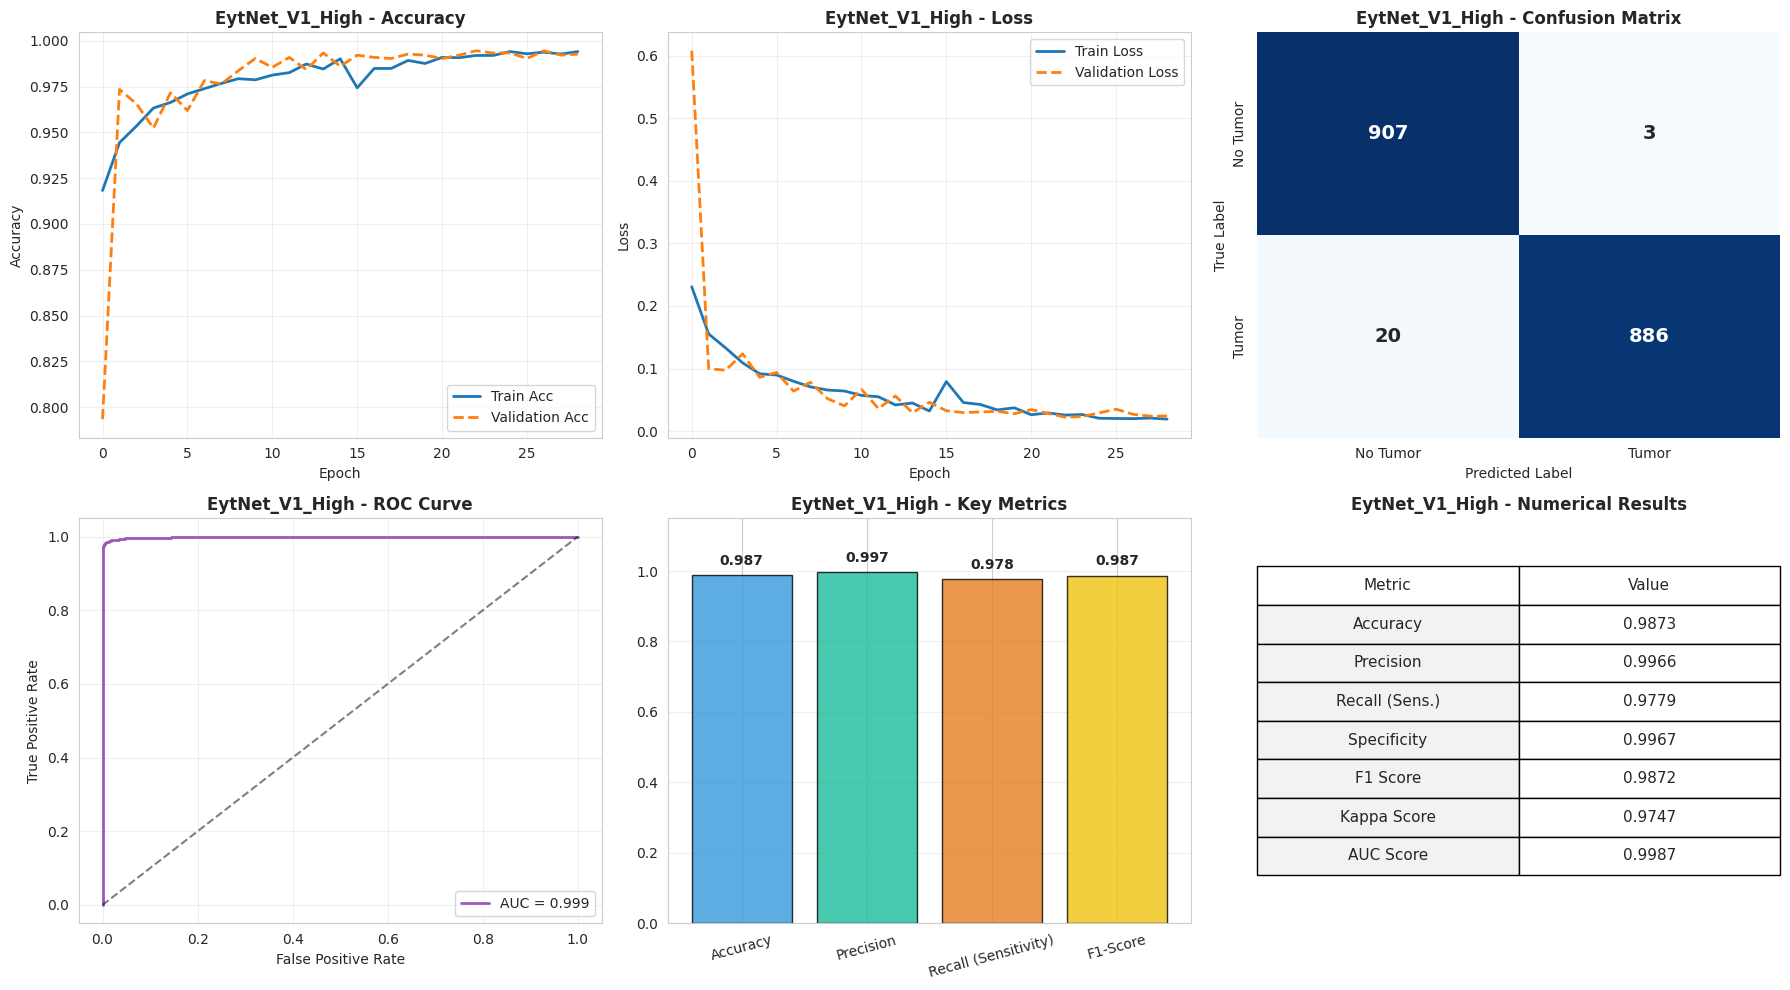

In [ ]:
# Evaluation of the EytNet_V1_High (High Performance)

import pickle
import pandas as pd
import os
import torch
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# Model Name
model_name = "EytNet_V1_High"
file_name = f"best_model_{model_name}_Final.pt"

print(f"MODEL EVALUATION: {model_name}")
print("-" * 40)

# Load Model
model_path = os.path.join(DRIVE_SAVE_PATH, file_name)

if os.path.exists(model_path):
    model = torch.jit.load(model_path, map_location=device)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Test Set (224x224)
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# Dataset and Loader
print(f"Scanning Test Folder: {test_dir}")
test_dataset_eval = MRIDataset(
    root_dir=test_dir,
    transform=val_transform_clean,
    preprocess_size=(224, 224)
)

if len(test_dataset_eval) == 0:
    raise ValueError(f"ERROR: No files found at '{test_dir}'!")

test_loader_eval = DataLoader(test_dataset_eval, batch_size=16, shuffle=False, num_workers=2)
print(f"Test Images Found: Total {len(test_dataset_eval)}")

# Make guess
y_true_list = []
y_prob_list = []

print("Predictions are being taken")
with torch.no_grad():
    for images, labels in test_loader_eval:
        images = images.to(device)

        outputs = model(images).squeeze()

        probs = torch.sigmoid(outputs)

        y_prob_list.extend(probs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# Calculate Metrics
metrics_high, cm_high, roc_data_high = calculate_metrics(y_true_list, y_prob_list, model_name)

# Print Results
print("\n" + "-"*30)
print("RESULTS")
print("-"*30)
print(f"Accuracy : {metrics_high.get('Accuracy', 0):.4f}")
print(f"F1 Score : {metrics_high.get('F1 Score', 0):.4f}")
print(f"AUC      : {metrics_high.get('AUC', 0):.4f}")

# Add training period information
if 'avg_epoch_time_eytnet_high' in globals():
    metrics_high["Avg. Epoch Time (s)"] = avg_epoch_time_eytnet_high
else:
    metrics_high["Avg. Epoch Time (s)"] = 0.0

# Save ROC Curve Data
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")
if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f: saved_roc_curves = pickle.load(f)
else: saved_roc_curves = {}

saved_roc_curves[model_name] = roc_data_high
with open(roc_pkl_path, 'wb') as f: pickle.dump(saved_roc_curves, f)
print(f"ROC data saved: {model_name}")

# Update CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_high])

if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    existing_df = existing_df[existing_df['Model'] != model_name]
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
else:
    final_df = new_row_df

final_df.to_csv(csv_path, index=False)
print(f"Results saved to CSV: {model_name}")

# Visualize
if 'history_eytnet_high' in globals():
    plot_model_results(history_eytnet_high, metrics_high, cm_high, roc_data_high, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history found.")

---
### **MODEL 10: CUSTOM - EytNet_V2**
---

In [ ]:
# ARCHITECTURE: EytNet_V2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from albumentations import Compose, Rotate, HorizontalFlip, ShiftScaleRotate, RandomGamma, GridDistortion, CoarseDropout, Normalize
from albumentations.pytorch import ToTensorV2

# Auxiliary Blocks (Residual)

class IdentityBlockV2(nn.Module):

    def __init__(self, in_channels, filters):
        super(IdentityBlockV2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(filters)
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(filters)

    def forward(self, x):
        residual = x
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

class ConvBlockV2(nn.Module):

    def __init__(self, in_channels, filters, stride=2):
        super(ConvBlockV2, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(filters)

        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(filters)

        # Shortcut to match dimensions (1x1 Conv)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, padding=0),
            nn.BatchNorm2d(filters)
        )

    def forward(self, x):
        residual = self.shortcut(x)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.bn2(self.conv2(x))
        x += residual
        x = F.relu(x)
        return x

# Main Model: EytNet_V2

class EytNetV2(nn.Module):
    def __init__(self):
        super(EytNetV2, self).__init__()

        # Stem (Initial Block) - Fixed for 3 Channels
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        # Feature Extractor Blocks
        self.block1 = nn.Sequential(
            ConvBlockV2(in_channels=32, filters=64, stride=2),
            IdentityBlockV2(in_channels=64, filters=64)
        )

        self.block2 = nn.Sequential(
            ConvBlockV2(in_channels=64, filters=128, stride=2),
            IdentityBlockV2(in_channels=128, filters=128)
        )

        self.block3 = nn.Sequential(
            ConvBlockV2(in_channels=128, filters=256, stride=2),
            IdentityBlockV2(in_channels=256, filters=256)
        )

        # Classifier Header
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 1)
            # No Sigmoid here (Using BCEWithLogitsLoss)
        )

    def forward(self, x):
        # Ensure 3-channel input
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)

        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

print("EytNet_V2 Architecture is Ready")

# Data Loader Function

def get_progressive_loader(image_size, batch_size):

    print(f"\nPreparing Dataset: {image_size}x{image_size}")

    # Augmentation for Training
    transform_train = Compose([
        Rotate(limit=10, p=0.3),
        HorizontalFlip(p=0.3),
        ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
        RandomGamma(gamma_limit=(80,120), p=0.3),
        GridDistortion(num_steps=50, distort_limit=0.04, p=0.1),
        CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=1, min_height=8, min_width=8, p=0.3),
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    # Clean Transform for Validation
    transform_val = Compose([
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    # Load Full Datasets
    full_train_dataset = MRIDataset(root_dir=train_dir, transform=transform_train, preprocess_size=(image_size, image_size))
    full_val_dataset   = MRIDataset(root_dir=train_dir, transform=transform_val, preprocess_size=(image_size, image_size))

    # Split Indices (Stratified)
    train_idx, val_idx = train_test_split(
        np.arange(len(full_train_dataset)),
        test_size=0.2,
        random_state=42,
        stratify=full_train_dataset.labels
    )

    # Create Subsets
    ds_train = Subset(full_train_dataset, train_idx)
    ds_val   = Subset(full_val_dataset, val_idx)

    # Create Loaders
    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2)

    return dl_train, dl_val

print("Progressive Loader function is integrated and ready")

EytNet_V2 Architecture is Ready
Progressive Loader function is integrated and ready


In [ ]:
# TRAINING THE EYTNET_V2

import time
import os
import torch
from torch.optim import Adam

model_name = "EytNet_V2"
print(f"MODEL TRAINING STARTED: {model_name}")
print("-" * 40)

# Initialize Model
model = EytNetV2().to(device)

# Loss Function
# BCEWithLogitsLoss is used because the model outputs Logits (No Sigmoid)
criterion = torch.nn.BCEWithLogitsLoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)

# Data Loaders (224px)
# Using the folder-based progressive loader defined previously
train_loader_v2, val_loader_v2 = get_progressive_loader(224, batch_size=32)

# Training Configuration
num_epochs = 45
history_v2 = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float('inf')
patience = 8
counter = 0

start_time = time.time()
print(f"{model_name} Training initialized for {num_epochs} epochs")

for epoch in range(num_epochs):

    # TRAINING PHASE
    model.train()
    running_loss = 0; correct = 0; total = 0

    for images, labels in train_loader_v2:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()

        # Forward pass (Logits)
        outputs = model(images).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Calculate Accuracy
        # Apply Sigmoid manually to convert Logits to Probabilities
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # VALIDATION PHASE
    model.eval()
    val_loss = 0; val_correct = 0; val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_v2:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Record History
    history_v2["train_loss"].append(train_loss)
    history_v2["val_loss"].append(val_loss)
    history_v2["train_acc"].append(train_acc)
    history_v2["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # CHECKPOINT & EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # Save Best Model (JIT Script)
        try:
            model_scripted = torch.jit.script(model)
            save_name = f"best_model_{model_name}_Final.pt" # Standardized naming
            torch.jit.save(model_scripted, os.path.join(DRIVE_SAVE_PATH, save_name))
            print(f" Best Model Saved: {best_val_loss:.4f}")
        except Exception as e:
            print(f" Save Error: {e}")

    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly Stopping triggered at epoch {epoch+1}")
            break

end_time = time.time()
avg_epoch_time_v2 = (end_time - start_time) / (epoch + 1)
print(f"\nTRAINING COMPLETED — Avg. Epoch Duration: {avg_epoch_time_v2:.2f} sec")

MODEL TRAINING STARTED: EytNet_V2
----------------------------------------

Preparing Dataset: 224x224
EytNet_V2 Training initialized for 45 epochs
Epoch [1/45] - Train Loss: 0.2011, Acc: 0.9302 | Val Loss: 0.0923, Acc: 0.9716
 Best Model Saved: 0.0923
Epoch [2/45] - Train Loss: 0.1048, Acc: 0.9665 | Val Loss: 0.0900, Acc: 0.9692
 Best Model Saved: 0.0900
Epoch [3/45] - Train Loss: 0.0833, Acc: 0.9731 | Val Loss: 0.4366, Acc: 0.7772
Epoch [4/45] - Train Loss: 0.0711, Acc: 0.9766 | Val Loss: 0.0607, Acc: 0.9807
 Best Model Saved: 0.0607
Epoch [5/45] - Train Loss: 0.0691, Acc: 0.9764 | Val Loss: 0.0417, Acc: 0.9885
 Best Model Saved: 0.0417
Epoch [6/45] - Train Loss: 0.0596, Acc: 0.9810 | Val Loss: 0.2721, Acc: 0.8841
Epoch [7/45] - Train Loss: 0.0621, Acc: 0.9796 | Val Loss: 0.0363, Acc: 0.9903
 Best Model Saved: 0.0363
Epoch [8/45] - Train Loss: 0.0423, Acc: 0.9864 | Val Loss: 0.0358, Acc: 0.9897
 Best Model Saved: 0.0358
Epoch [9/45] - Train Loss: 0.0447, Acc: 0.9850 | Val Loss: 0.034

MODEL EVALUATION: EytNet_V2
----------------------------------------
Model loaded successfully: /content/drive/MyDrive/saved_models_new/best_model_EytNet_V2.pt
Test Set Size: 1816 image
Predictions are being taken
ROC data saved to Drive: EytNet_V2
Added to existing table. Total models: 12
Results added to CSV: EytNet_V2


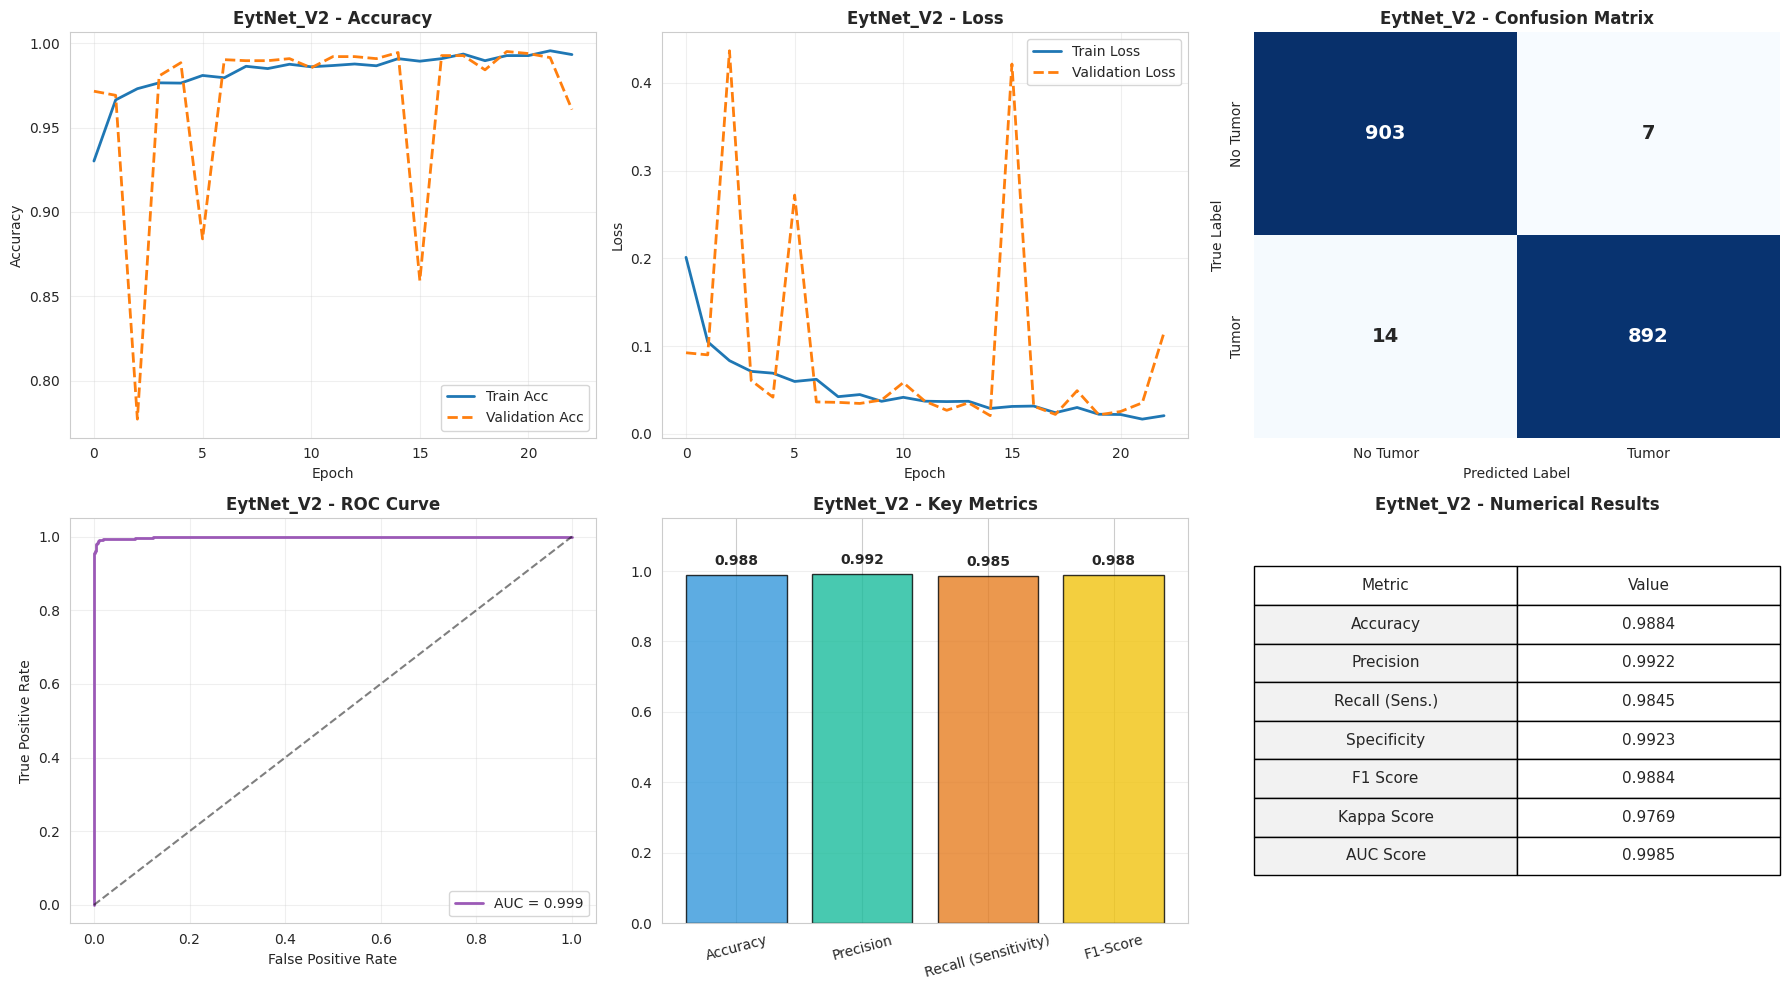

In [ ]:
# Evaluation of the EytNet_V2

import pickle
import pandas as pd
import os
import torch
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# Model Name
model_name = "EytNet_V2"
file_name = f"best_model_{model_name}.pt"

print(f"MODEL EVALUATION: {model_name}")
print("-" * 40)

# Load Model
model_path = os.path.join(DRIVE_SAVE_PATH, file_name)

if os.path.exists(model_path):
    model = torch.jit.load(model_path, map_location=device)
    model.eval()
    print(f"Model loaded successfully: {model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {model_path}")

# Test Set (224x224)
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# Universal Dataset kullanımı
test_dataset_v2 = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_v2 = DataLoader(test_dataset_v2, batch_size=32, shuffle=False, num_workers=2)

print(f"Test Set Size: {len(test_dataset_v2)} image")

# Make guess
y_true_list = []
y_prob_list = []

print("Predictions are being taken")
with torch.no_grad():
    for images, labels in test_loader_v2:
        images = images.to(device)

        # Logits output
        outputs = model(images).squeeze()

        # Sigmoid
        probs = torch.sigmoid(outputs)

        y_prob_list.extend(probs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# Calculate Metrics
metrics_v2, cm_v2, roc_data_v2 = calculate_metrics(y_true_list, y_prob_list, model_name)

# Add training period information
try:
    metrics_v2["Avg. Epoch Time (s)"] = avg_epoch_time_v2
except NameError:
    metrics_v2["Avg. Epoch Time (s)"] = 0.0

# Save ROC Curve Data
roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")

if os.path.exists(roc_pkl_path):
    with open(roc_pkl_path, 'rb') as f:
        saved_roc_curves = pickle.load(f)
else:
    saved_roc_curves = {}

saved_roc_curves[model_name] = roc_data_v2

with open(roc_pkl_path, 'wb') as f:
    pickle.dump(saved_roc_curves, f)

print(f"ROC data saved to Drive: {model_name}")

# Update CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_v2])

if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    existing_df = existing_df[existing_df['Model'] != model_name]
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
    print(f"Added to existing table. Total models: {len(final_df)}")
else:
    final_df = new_row_df
    print("New CSV file created.")

final_df.to_csv(csv_path, index=False)
print(f"Results added to CSV: {model_name}")

# Visualize Results
if 'history_v2' in globals():
    plot_model_results(history_v2, metrics_v2, cm_v2, roc_data_v2, model_name, classes=["No Tumor", "Tumor"])
else:
    print("No training history (history_v2) found for the graph, only numerical metrics calculated.")



---


### **MODEL 11: CUSTOM - EytNet_V2_Opt (OPTIMIZED)**


---

In [ ]:
# ARCHITECTURE: EytNet_V2_Opt (Optimized)

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from albumentations import Compose, Rotate, HorizontalFlip, ShiftScaleRotate, RandomGamma, GridDistortion, CoarseDropout, Normalize
from albumentations.pytorch import ToTensorV2

# MISH ACTIVATION
class Mish(nn.Module):
    def forward(self, x):
        return x * torch.tanh(F.softplus(x))

# SE BLOCK (Attention)
class SEBlock(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super(SEBlock, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)

# RESIDUAL BLOCKS (Advanced)
class AdvancedIdentityBlock(nn.Module):
    def __init__(self, in_channels, filters):
        super(AdvancedIdentityBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(filters)
        self.act1 = Mish()
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filters)
        self.se = SEBlock(filters)
        self.act2 = Mish()

    def forward(self, x):
        residual = x
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += residual
        out = self.act2(out)
        return out

class AdvancedConvBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=2):
        super(AdvancedConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, filters, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(filters)
        self.act1 = Mish()
        self.conv2 = nn.Conv2d(filters, filters, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(filters)
        self.se = SEBlock(filters)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False),
            nn.BatchNorm2d(filters)
        )
        self.act2 = Mish()

    def forward(self, x):
        residual = self.shortcut(x)
        out = self.act1(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out += residual
        out = self.act2(out)
        return out

# MAIN MODEL: EytNet_V2_Opt
class EytNetV2_Opt(nn.Module):
    def __init__(self):
        super(EytNetV2_Opt, self).__init__()

        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=7, stride=2, padding=3, bias=False), # 1 -> 3
            nn.BatchNorm2d(32),
            Mish(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.block1 = nn.Sequential(AdvancedConvBlock(32, 64, stride=2), AdvancedIdentityBlock(64, 64))
        self.block2 = nn.Sequential(AdvancedConvBlock(64, 128, stride=2), AdvancedIdentityBlock(128, 128))
        self.block3 = nn.Sequential(
            AdvancedConvBlock(128, 256, stride=2),
            AdvancedIdentityBlock(256, 256),
            AdvancedIdentityBlock(256, 256)
        )

        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            Mish(),
            nn.Dropout(0.4),
            nn.Linear(256, 1)
        )

        self._initialize_weights()

    def forward(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)

        x = self.stem(x)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        return self.classifier(x)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

print("EytNet_V2_Opt Architecture is Ready")

# DATA LOADER FUNCTION (Integrated)

def get_progressive_loader(image_size, batch_size):
    print(f"\nDataset is being prepared: {image_size}x{image_size}")

    transform_train = Compose([
        Rotate(limit=10, p=0.3),
        HorizontalFlip(p=0.3),
        ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=0, p=0.3),
        RandomGamma(gamma_limit=(80,120), p=0.3),
        GridDistortion(num_steps=50, distort_limit=0.04, p=0.1),
        CoarseDropout(max_holes=8, max_height=16, max_width=16, min_holes=1, min_height=8, min_width=8, p=0.3),
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    transform_val = Compose([
        Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
        ToTensorV2()
    ])

    # Universal Dataset Usage
    full_train_dataset = MRIDataset(root_dir=train_dir, transform=transform_train, preprocess_size=(image_size, image_size))

    # Stratified Split
    train_idx, val_idx = train_test_split(
        np.arange(len(full_train_dataset)),
        test_size=0.2,
        random_state=42,
        stratify=full_train_dataset.labels
    )

    ds_train = Subset(full_train_dataset, train_idx)
    ds_val   = Subset(full_train_dataset, val_idx)

    full_val_dataset = MRIDataset(root_dir=train_dir, transform=transform_val, preprocess_size=(image_size, image_size))
    ds_val = Subset(full_val_dataset, val_idx)

    dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2)
    dl_val = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2)

    return dl_train, dl_val

print("Progressive Loader function is integrated and ready")

EytNet_V2_Opt Architecture is Ready
Progressive Loader function is integrated and ready


In [ ]:
# TRAINING EytNet_V2_Opt (Opt)

import time
import os
import torch
from torch.optim import AdamW

# Name Updated
model_name = "EytNet_V2_Opt"
print(f"Training Start: {model_name}")
print("-" * 40)

# Data Loaders (224x224)
train_loader_v2, val_loader_v2 = get_progressive_loader(224, batch_size=32)

# Initialize Model
try:
    model = EytNetV2_Opt().to(device)
except NameError:
    raise NameError("EytNet_V2_Opt class doesn't excit.")

# Optimizer and Loss
criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-3)

# Manual Loop Variables
num_epochs = 45
history_v2_opt = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float('inf')
patience = 8
counter = 0

start_time = time.time()
print(f"{model_name} training start - Target Epoch: {num_epochs}")

for epoch in range(num_epochs):

    # TRAINING
    model.train()
    running_loss = 0; correct = 0; total = 0

    for images, labels in train_loader_v2:
        images = images.to(device)
        labels = labels.float().to(device)

        optimizer.zero_grad()
        outputs = model(images).squeeze()

        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Logits -> Sigmoid -> Preds
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # VALIDATION
    model.eval()
    val_loss = 0; val_correct = 0; val_total = 0

    with torch.no_grad():
        for images, labels in val_loader_v2:
            images = images.to(device)
            labels = labels.float().to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    # Record (history_v2_opt used)
    history_v2_opt["train_loss"].append(train_loss)
    history_v2_opt["val_loss"].append(val_loss)
    history_v2_opt["train_acc"].append(train_acc)
    history_v2_opt["val_acc"].append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] - "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    # JIT Saving and Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0

        # JIT Save
        try:
            model_scripted = torch.jit.script(model)
            save_name = f"best_model_{model_name}_Final.pt"
            torch.jit.save(model_scripted, os.path.join(DRIVE_SAVE_PATH, save_name))
            print(f" Best Model Saved (JIT): {best_val_loss:.4f}")
        except Exception as e:
            print(f" Save Error: {e}")

    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly Stopping - Epoch: {epoch+1}")
            break

end_time = time.time()
avg_epoch_time_v2_opt = (end_time - start_time) / (epoch + 1)
print(f"\n{model_name} TRAINING DONE — AVG. TIME: {avg_epoch_time_v2_opt:.2f} sec")

Training Start: EytNet_V2_Opt
----------------------------------------

Dataset is being prepared: 224x224
EytNet_V2_Opt training start - Target Epoch: 45
Epoch [1/45] - Train Loss: 0.2201, Acc: 0.9204 | Val Loss: 1.2522, Acc: 0.5272
 Best Model Saved (JIT): 1.2522
Epoch [2/45] - Train Loss: 0.1170, Acc: 0.9591 | Val Loss: 1.2002, Acc: 0.5580
 Best Model Saved (JIT): 1.2002
Epoch [3/45] - Train Loss: 0.1014, Acc: 0.9650 | Val Loss: 1.6290, Acc: 0.5193
Epoch [4/45] - Train Loss: 0.0719, Acc: 0.9749 | Val Loss: 0.3001, Acc: 0.9052
 Best Model Saved (JIT): 0.3001
Epoch [5/45] - Train Loss: 0.0729, Acc: 0.9751 | Val Loss: 0.0513, Acc: 0.9861
 Best Model Saved (JIT): 0.0513
Epoch [6/45] - Train Loss: 0.0665, Acc: 0.9773 | Val Loss: 0.0681, Acc: 0.9801
Epoch [7/45] - Train Loss: 0.0666, Acc: 0.9786 | Val Loss: 0.0470, Acc: 0.9855
 Best Model Saved (JIT): 0.0470
Epoch [8/45] - Train Loss: 0.0517, Acc: 0.9835 | Val Loss: 0.0366, Acc: 0.9909
 Best Model Saved (JIT): 0.0366
Epoch [9/45] - Train 

MODEL EVALUATION: EytNet_V2_Opt
-----------------------------------
Best model (JIT) loaded: /content/drive/MyDrive/saved_models_new/best_model_EytNet_V2_Opt_Final.pt
Getting predictions
Results saved to CSV: EytNet_V2_Opt


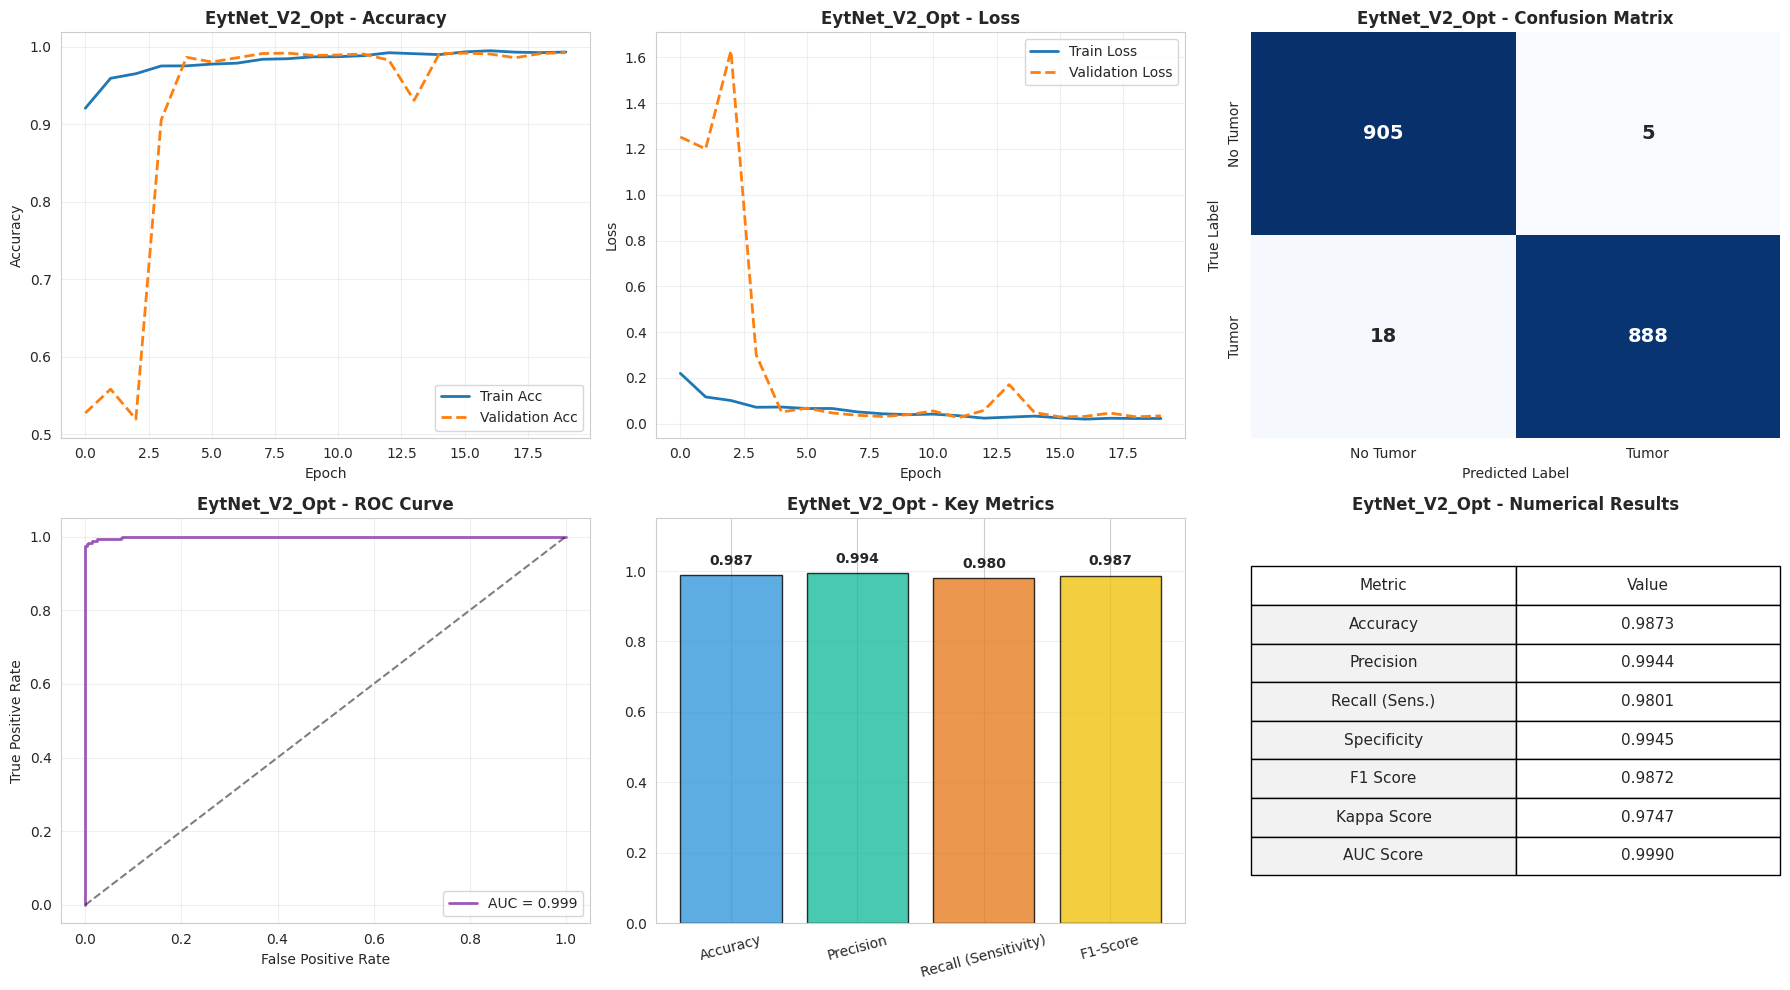

In [ ]:
# EytNet_V2_Opt (Opt) EVALUATION

import pickle
import pandas as pd
import os
import torch
from albumentations import Compose, Normalize
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

# Name Updated
model_name = "EytNet_V2_Opt"
print(f"MODEL EVALUATION: {model_name}")
print("-" * 35)

# Load Best Model
best_model_path = os.path.join(DRIVE_SAVE_PATH, f"best_model_{model_name}_Final.pt")

if os.path.exists(best_model_path):
    model = torch.jit.load(best_model_path, map_location=device)
    model.eval()
    print(f"Best model (JIT) loaded: {best_model_path}")
else:
    raise FileNotFoundError(f"Model file not found: {best_model_path}")

# Test Set (224x224)
val_transform_clean = Compose([
    Normalize(mean=(0.0,), std=(1.0,), max_pixel_value=255.0),
    ToTensorV2()
])

# Universal Dataset
test_dataset_v2_opt = MRIDataset(root_dir=test_dir, transform=val_transform_clean, preprocess_size=(224, 224))
test_loader_v2_opt = DataLoader(test_dataset_v2_opt, batch_size=32, shuffle=False, num_workers=2)

# Make Predictions
y_true_list = []
y_prob_list = []

print("Getting predictions")
with torch.no_grad():
    for images, labels in test_loader_v2_opt:
        images = images.to(device)

        # Logits
        outputs = model(images).squeeze()

        # Sigmoid added (Logits -> Probability)
        probs = torch.sigmoid(outputs)

        y_prob_list.extend(probs.cpu().numpy().tolist())
        y_true_list.extend(labels.numpy().tolist())

# Calculate Metrics
metrics_v2_opt, cm_v2_opt, roc_data_v2_opt = calculate_metrics(y_true_list, y_prob_list, model_name)

try:
    if 'avg_epoch_time_v2_opt' in globals():
        metrics_v2_opt["Avg. Epoch Time (s)"] = avg_epoch_time_v2_opt
    else:
        metrics_v2_opt["Avg. Epoch Time (s)"] = 0.0
except NameError:
    metrics_v2_opt["Avg. Epoch Time (s)"] = 0.0

# Update CSV
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")
new_row_df = pd.DataFrame([metrics_v2_opt])

if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path)
    existing_df = existing_df[existing_df['Model'] != model_name]
    final_df = pd.concat([existing_df, new_row_df], ignore_index=True)
else:
    final_df = new_row_df

final_df.to_csv(csv_path, index=False)
print(f"Results saved to CSV: {model_name}")

# Visualize
if 'history_v2_opt' in globals():
    plot_model_results(history_v2_opt, metrics_v2_opt, cm_v2_opt, roc_data_v2_opt, model_name, classes=["No Tumor", "Tumor"])
else:
    print("Training history (history_v2_opt) not found, only metrics calculated.")



---


### **TÜM MODELLERİN SONUÇLARINI KARŞILAŞTIRMA**


---



PERFORMANCE COMPARISON OF ALL MODELS
----------------------------------------
Data loaded: /content/drive/MyDrive/saved_models_new/model_comparison_results_new.csv

MODEL RANKING (F1-Score Based)


,Accuracy,Precision,Recall,Specificity,F1-Score,Kappa,AUC,Avg. Epoch Time (s)
Model,,,,,,,,
EytNet_V1,0.9950,0.9967,0.9934,0.996703,0.9950,0.990088,0.9994,64.110000
MobileNetV2_ResNet50,0.9934,0.9978,0.9890,0.997802,0.9933,0.986784,0.9994,87.290000
VGG16_NoAug,0.9912,0.9912,0.9912,0.991209,0.9912,0.982379,0.9985,nan
VGG16_WithAug,0.9906,0.9944,0.9868,0.994505,0.9906,0.981277,0.9985,72.740000
EytNet_V2,0.9884,0.9922,0.9845,0.992308,0.9884,0.976872,0.9985,64.580000
EfficientNetB0_ShuffleNetV2,0.9879,0.9825,0.9934,0.982418,0.9879,0.975771,0.9992,73.050000
EytNet_V2_Opt,0.9873,0.9944,0.9801,0.994505,0.9872,0.974669,0.9990,64.920000
EytNet_V1_High,0.9873,0.9966,0.9779,0.996703,0.9872,0.974668,0.9987,63.700000
ResNet18_MobileNetV3Small,0.9703,0.9661,0.9746,0.965934,0.9703,0.940529,0.9957,68.440000



Bar Chart - All Models


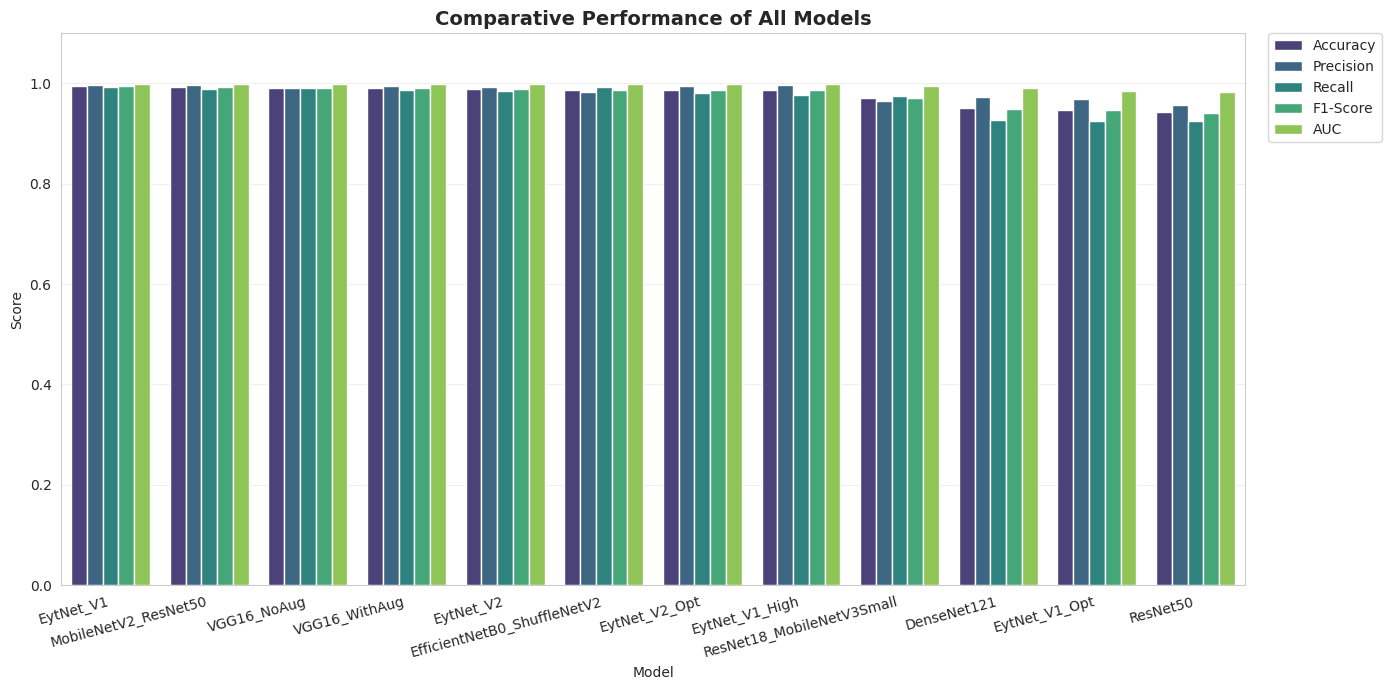


ROC Analysis - All Models


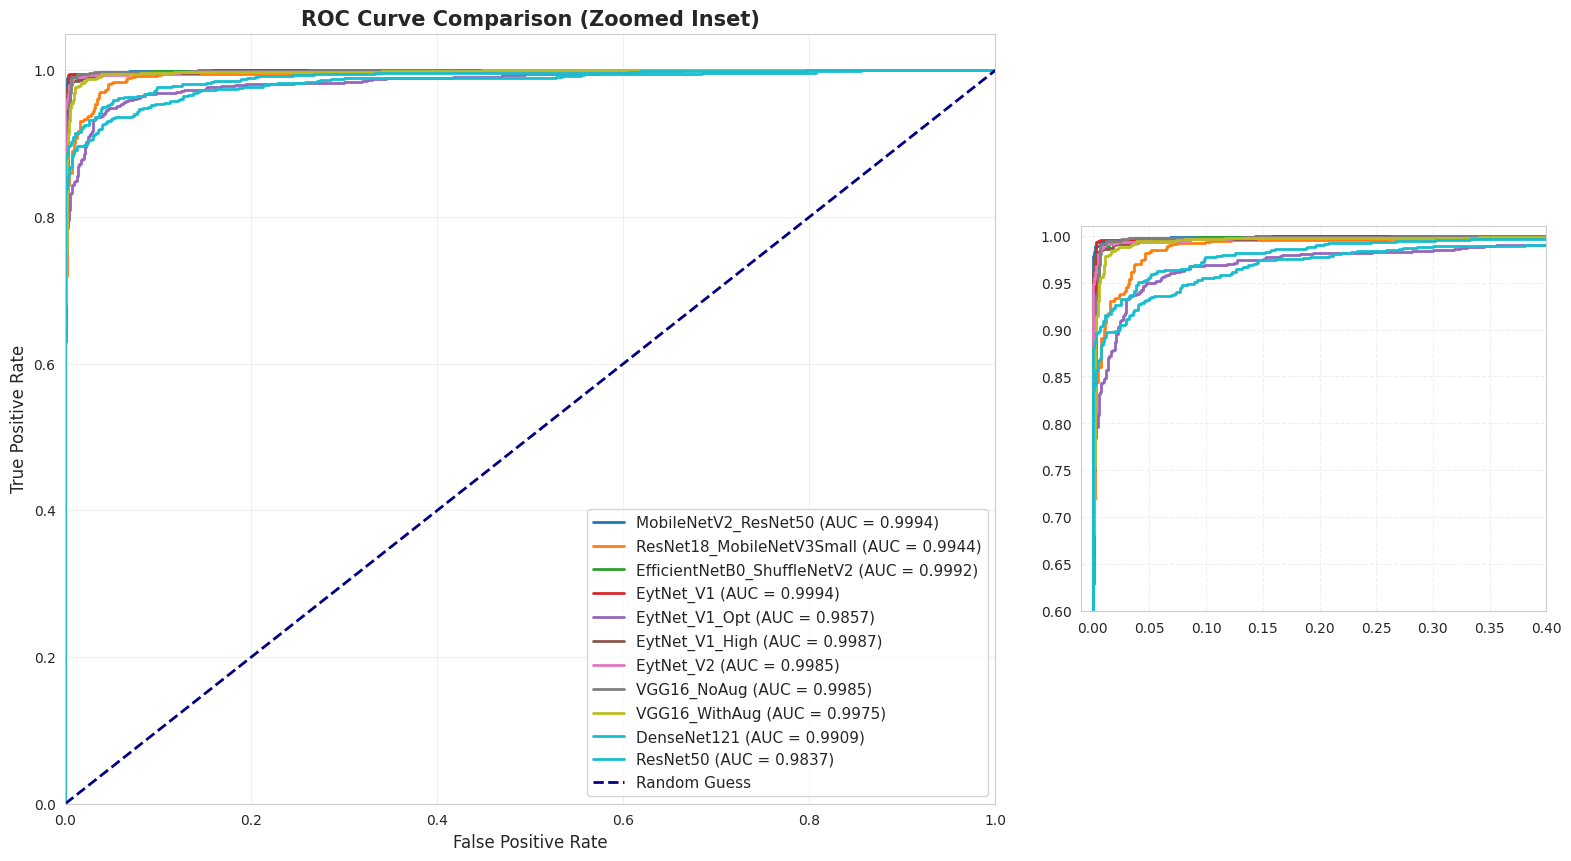

Zoomed ROC chart recorded: /content/drive/MyDrive/saved_models_new/final_all_models_roc_zoomed.png


In [ ]:
# COMPARE AND VISUALIZE THE RESULTS OF ALL MODELS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

print("PERFORMANCE COMPARISON OF ALL MODELS")
print("-" * 40)

# UPLOAD DATA
csv_path = os.path.join(DRIVE_SAVE_PATH, "model_comparison_results_new.csv")

if os.path.exists(csv_path):
    results_df = pd.read_csv(csv_path)
    print(f"Data loaded: {csv_path}")
else:
    # If file does not exist, use the one in memory
    results_df = pd.DataFrame(all_model_metrics)
    print("CSV not found, using in-memory data.")

# DATA CLEANING AND FORMATTING
if not results_df.empty:

    # Set model name as index
    if "Model" in results_df.columns:
        results_df.set_index("Model", inplace=True)

    if "Recall (Sensitivity)" in results_df.columns:
        results_df.rename(columns={"Recall (Sensitivity)": "Recall"}, inplace=True)

    metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]

    for col in metric_cols:
        if col in results_df.columns:
            results_df[col] = results_df[col].astype(float)

    if "Avg. Epoch Time (s)" in results_df.columns:
        results_df["Avg. Epoch Time (s)"] = results_df["Avg. Epoch Time (s)"].astype(float).round(2)

    # ARRANGEMENT
    # Sorted in descending order according to F1-Score A.
    if "F1-Score" in results_df.columns:
        results_df.sort_values(by="F1-Score", ascending=False, inplace=True)

    # TABLE VISUALIZATION
    print("\nMODEL RANKING (F1-Score Based)")

    def highlight_max(s):
        is_max = s == s.max()
        return ['background-color: #d4edda; color: #155724; font-weight: bold' if v else '' for v in is_max]

    styled_table = results_df.style.apply(highlight_max, subset=metric_cols) \
                                   .format("{:.4f}", subset=metric_cols)

    display(styled_table)

    # GRAPHICAL COMPARISON (Bar Chart)
    print("\nBar Chart - All Models")
    plot_df = results_df.reset_index().melt(id_vars="Model", value_vars=metric_cols, var_name="Metric", value_name="Score")

    plt.figure(figsize=(14, 7))
    sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric", palette="viridis")

    plt.title("Comparative Performance of All Models", fontsize=14, fontweight='bold')
    plt.ylim(0, 1.1)
    plt.xticks(rotation=15, ha="right")
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.grid(axis='y', alpha=0.3)

    # Printing values ​​on the chart
    plt.tight_layout()
    plt.savefig(os.path.join(DRIVE_SAVE_PATH, "final_model_comparison_chart.png"), dpi=300)
    plt.show()

    # COLLECTIVE ROC CURVE
    print("\nROC Analysis - All Models")
    roc_pkl_path = os.path.join(DRIVE_SAVE_PATH, "all_roc_curves.pkl")

    if os.path.exists(roc_pkl_path):

        # Upload the file
        with open(roc_pkl_path, 'rb') as f:
            loaded_roc_curves = pickle.load(f)

        if len(loaded_roc_curves) > 0:
            fig, ax = plt.subplots(figsize=(12, 10))

            colors = plt.cm.get_cmap('tab10', len(loaded_roc_curves))

            # MAİN GRAPHIC DRAWING
            for i, (name, roc_data) in enumerate(loaded_roc_curves.items()):
                fpr, tpr, roc_auc = roc_data
                ax.plot(fpr, tpr, lw=2, color=colors(i),
                        label=f'{name} (AUC = {roc_auc:.4f})')

            ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.05])
            ax.set_xlabel('False Positive Rate', fontsize=12)
            ax.set_ylabel('True Positive Rate', fontsize=12)
            ax.set_title('ROC Curve Comparison (Zoomed Inset)', fontsize=15, fontweight='bold')
            ax.legend(loc="lower right", fontsize=11)
            ax.grid(alpha=0.3)

            axins = inset_axes(ax, width="50%", height="50%", loc='center right',
                              bbox_to_anchor=(0.6, 0, 1, 1), bbox_transform=ax.transAxes)

            for i, (name, roc_data) in enumerate(loaded_roc_curves.items()):
                fpr, tpr, roc_auc = roc_data
                axins.plot(fpr, tpr, lw=2, color=colors(i))

            axins.set_xlim(-0.01, 0.4)
            axins.set_ylim(0.6, 1.01)

            axins.grid(alpha=0.3, linestyle='--')

            save_path = os.path.join(DRIVE_SAVE_PATH, "final_all_models_roc_zoomed.png")
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
            plt.show()
            print(f"Zoomed ROC chart recorded: {save_path}")

        else:
            print("ROC file is empty.")
    else:
        print(f"No recorded ROC data found yet: {roc_pkl_path}")

else:
    print("No data found to display. Please train the models first.")